# **Walmart**
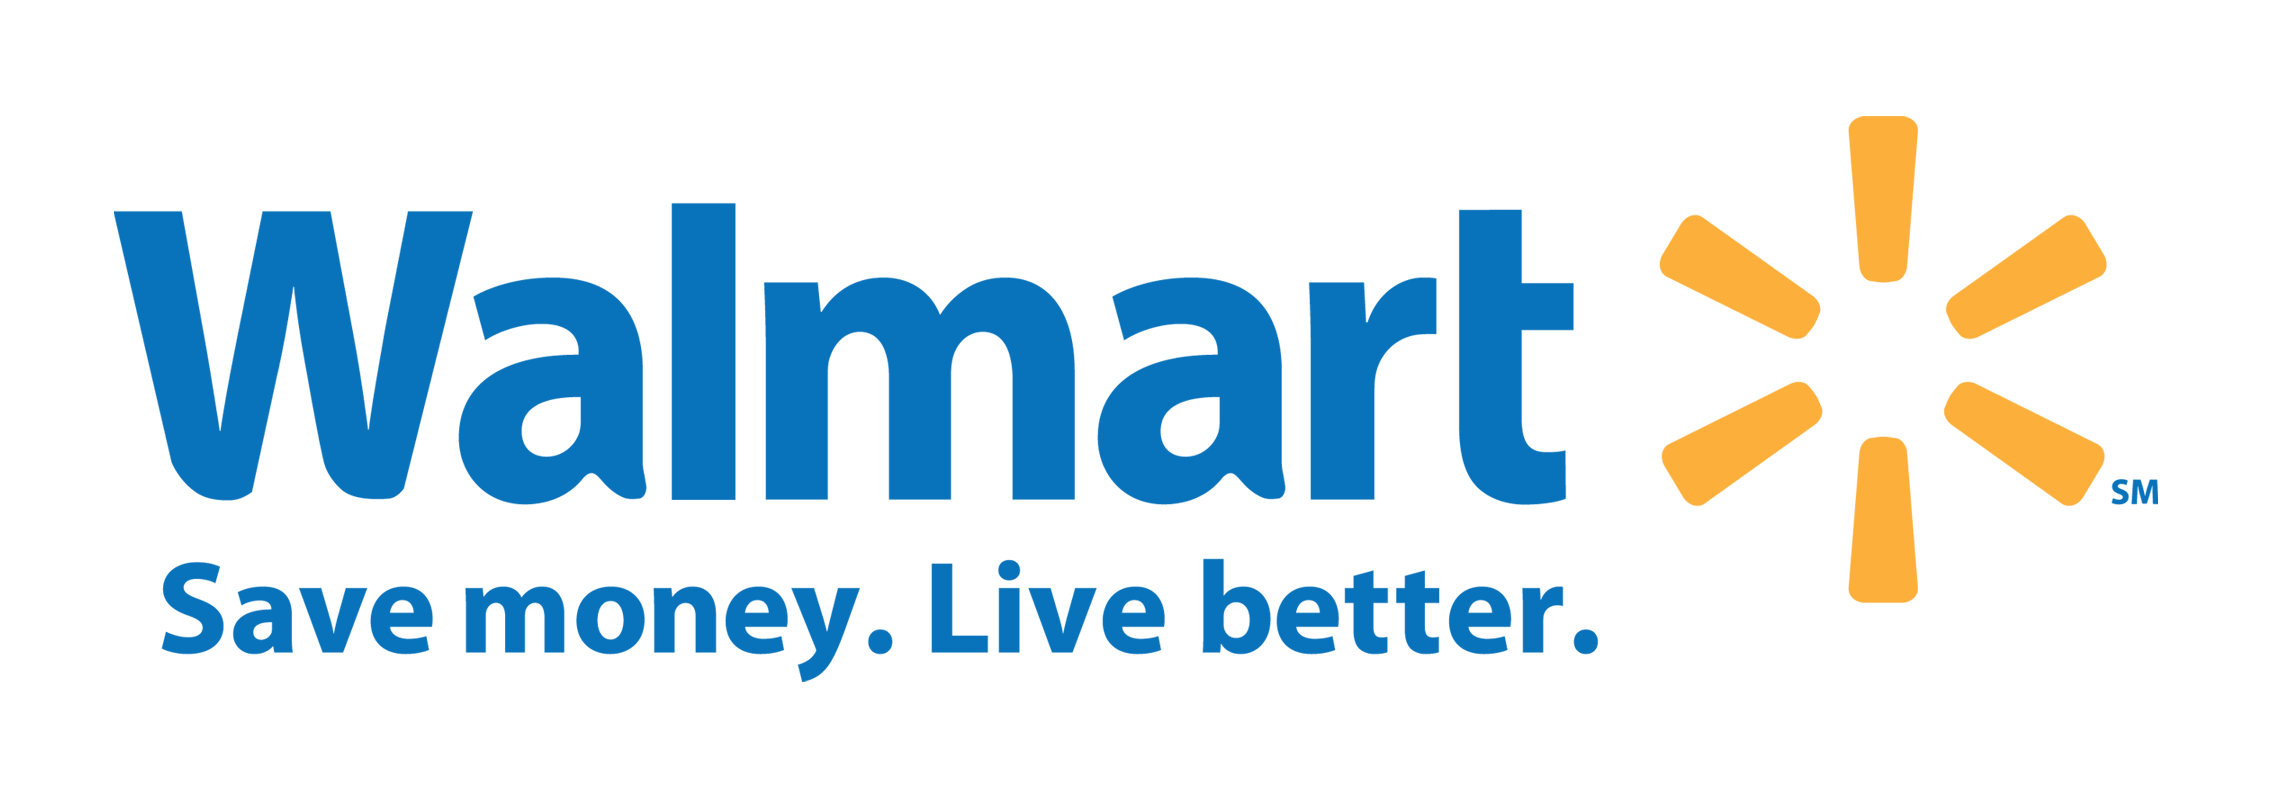

*Walmart is an American multinational retail corporation that operates a chain of
supercenters, discount departmental stores, and grocery stores in the United States. Walmart has more than 100 million customers worldwide.*

In [1]:
#Importing libraries -
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# **Problem Statement & Analyzing Basic Metrics:**

*The Management team at Walmart Inc. wants to analyze the customer purchase
behavior (precisely, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions. They want to understand if the spending habits differ between male and female customers: Do women spend more on
Black Friday than men?*

**Basic Analysis Of The Data - EDA**

# **1. Import the dataset and do usual data analysis steps like checking the structure & characteristics of the dataset.**

**a. The data type of all columns in the “customers” table.**

**Hint: We want you to display the data type of each column present in the
dataset.**

**b. You can find the number of rows and columns given in the dataset.**

**Hint: You can find the shape of the dataset.**

**c. Check for the missing values and find the number of missing values in each
column.**

**Importing the dataset**

In [2]:
import gdown
!gdown 1AwVi5QXwazInLcw_FzxkZ6CXnsFczTrT

Downloading...
From: https://drive.google.com/uc?id=1AwVi5QXwazInLcw_FzxkZ6CXnsFczTrT
To: /content/walmart_data.csv
100% 23.0M/23.0M [00:00<00:00, 86.2MB/s]


In [3]:
data= pd.read_csv('walmart_data.csv')
pd.options.display.max_columns=999
pd.options.display.max_rows=999
data.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


**Getting Basic Info About The Dataset**

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


*>**Insight:** The dataset consists of 5 columns containing object datatype, while 5 column contains integer datatype*

In [5]:
data['City_Category']=data['City_Category'].astype('category')
data['Gender']=data['Gender'].astype('category')
data['Marital_Status']=data['Marital_Status'].astype('category')
data['Age']=data['Age'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   User_ID                     550068 non-null  int64   
 1   Product_ID                  550068 non-null  object  
 2   Gender                      550068 non-null  category
 3   Age                         550068 non-null  category
 4   Occupation                  550068 non-null  int64   
 5   City_Category               550068 non-null  category
 6   Stay_In_Current_City_Years  550068 non-null  object  
 7   Marital_Status              550068 non-null  category
 8   Product_Category            550068 non-null  int64   
 9   Purchase                    550068 non-null  int64   
dtypes: category(4), int64(4), object(2)
memory usage: 27.3+ MB


*>**Insight:** Converted City_Category, Marital_Status, Gender, Age into category datatype*

**Shape Of Dataset**

In [6]:
data.shape

(550068, 10)

*>**Insight:** There are 550068 rows and 10 columns in the dataset*

**Duplicate Values**

In [7]:
data.duplicated().any()

False

In [8]:
data.duplicated().sum()

0

*>**Insight:** There are no duplicate rows in dataset.*

**Statistical Summary**

In [9]:
data.describe()

,User_ID,Occupation,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,5.404270,9263.968713
std,1.727592e+03,6.522660,3.936211,5023.065394
min,1.000001e+06,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,20.000000,23961.000000


*>**Insight:** This function calculates summary statistics, including count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum, for numerical columns within the DataFrame. These statistics aid in comprehending the central tendency, spread, and distribution of the data.*

In [10]:
data.describe(include= 'object').T

,count,unique,top,freq
Product_ID,550068,3631,P00265242,1880
Stay_In_Current_City_Years,550068,5,1,193821


*>**Insight:** This command retrieves information about categorical data within the DataFrame, including the count of observations, the number of unique categories, the most frequent category, and its frequency for each categorical column.*

**2. Non-Graphical Analysis: Value counts and unique attributes ​**

**Unique Values**

In [11]:
data.nunique()

,0
User_ID,5891
Product_ID,3631
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category,20
Purchase,18105


**Value Counts Of Categorical Data**

**Univariate**

**Gender**

In [12]:
data['Gender'].value_counts()

,count
Gender,
M,414259
F,135809


In [13]:
data['Gender'].value_counts(normalize= True)

,proportion
Gender,
M,0.753105
F,0.246895


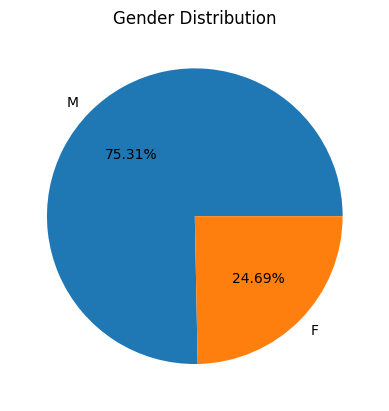

In [14]:
value= data['Gender'].value_counts()
type_data= data['Gender'].value_counts().index
plt.pie(value, labels= type_data, autopct= '%2.2f%%')
plt.title('Gender Distribution')
plt.show()

*>**Insight:** Dataset has 75.31% of Male and 24.69% of Female people*

**Marital Status**

In [15]:
data['Marital_Status']= data['Marital_Status'].replace([0, 1], ['Unmarried', 'Married'])

<ipython-input-15-4a490eb8b2d7>:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data['Marital_Status']= data['Marital_Status'].replace([0, 1], ['Unmarried', 'Married'])


In [16]:
data['Marital_Status'].value_counts()

,count
Marital_Status,
Unmarried,324731
Married,225337


In [17]:
data['Marital_Status'].value_counts(normalize= True)

,proportion
Marital_Status,
Unmarried,0.590347
Married,0.409653


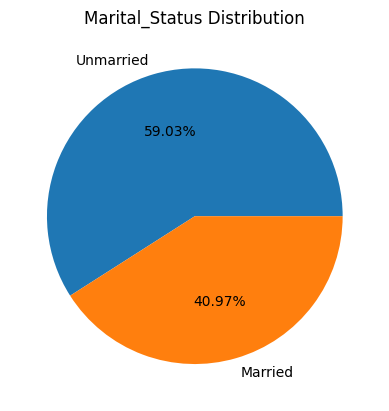

In [18]:
value= data['Marital_Status'].value_counts()
type_data= data['Marital_Status'].value_counts().index
plt.pie(value, labels= type_data, autopct= '%2.2f%%')
plt.title('Marital_Status Distribution')
plt.show()

*>**Insight:** Dataset has 59.03% of Unmarried and 40.97% of Married people*

**Age Category**


In [19]:
data['Age'].value_counts()

,count
Age,
26-35,219587
36-45,110013
18-25,99660
46-50,45701
51-55,38501
55+,21504
0-17,15102


In [20]:
data['Age'].value_counts(normalize= True)

,proportion
Age,
26-35,0.399200
36-45,0.199999
18-25,0.181178
46-50,0.083082
51-55,0.069993
55+,0.039093
0-17,0.027455


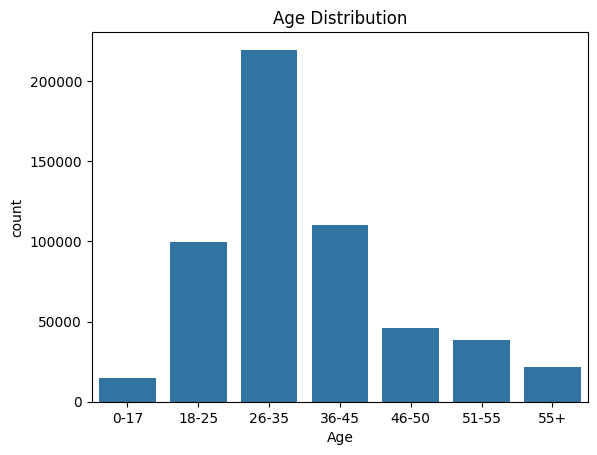

In [21]:
sns.countplot(data, x= 'Age')
plt.title('Age Distribution')
plt.show()

**City_Category**

In [22]:
data['City_Category'].value_counts()

,count
City_Category,
B,231173
C,171175
A,147720


In [23]:
data['City_Category'].value_counts(normalize= True)

,proportion
City_Category,
B,0.420263
C,0.311189
A,0.268549


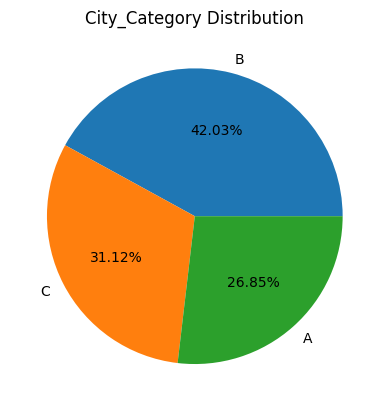

In [24]:
value= data['City_Category'].value_counts()
type_data= data['City_Category'].value_counts().index
plt.pie(value, labels= type_data, autopct= '%2.2f%%')
plt.title('City_Category Distribution')
plt.show()

*>**Insight:** In City Category, 26.85% belongs to 'A', 42.03% belongs to 'B' and 31.12% belongs to 'C'*

**Product_Category**

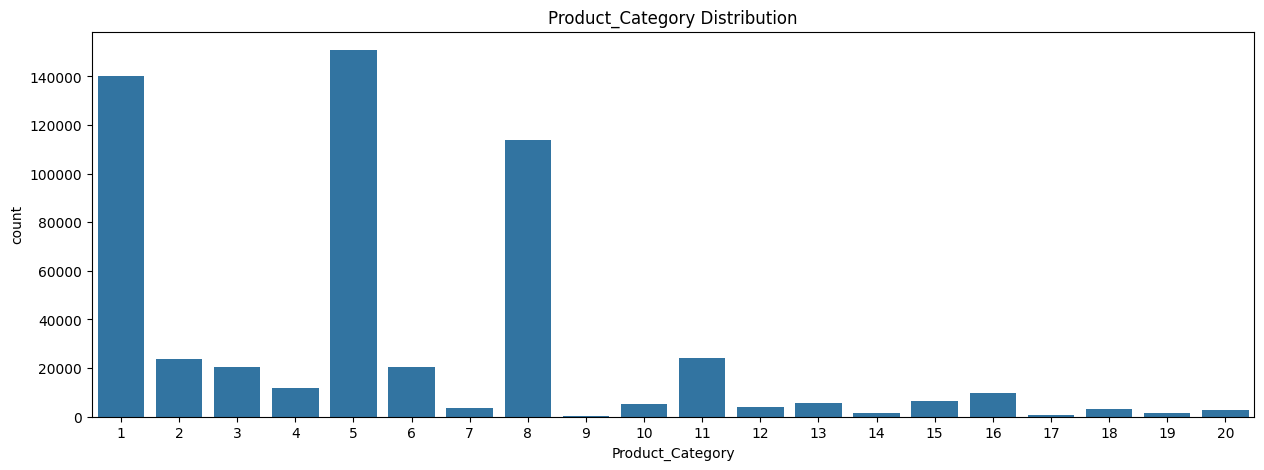

In [25]:
plt.figure(figsize=(15,5))
sns.countplot(data, x= 'Product_Category')
plt.title('Product_Category Distribution')
plt.show()

*>**Insight:** Product Category 1, 5 and 8 are more famous as thier count is high. Category 5 is the most famous one.*

**Purchase**

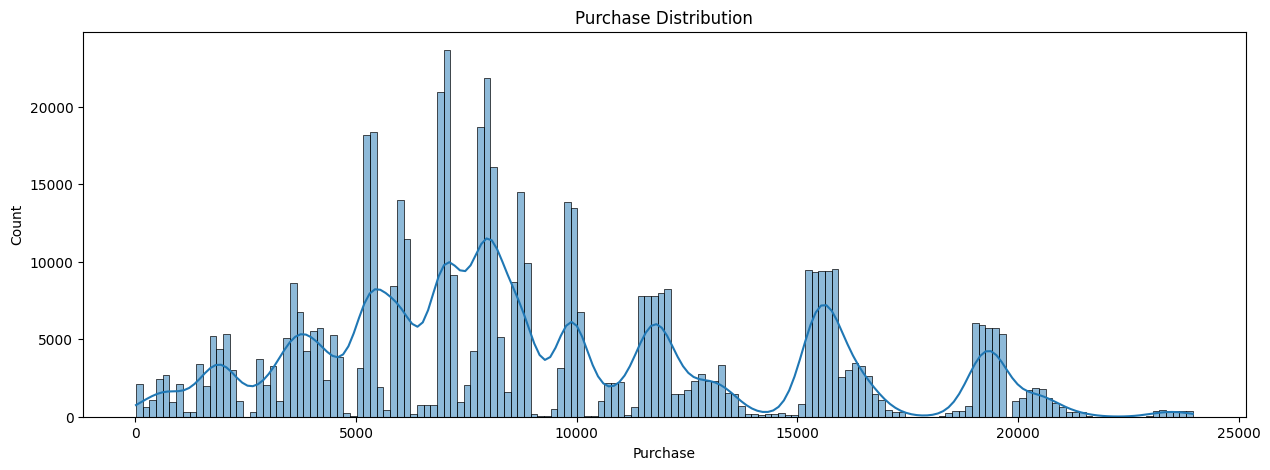

In [26]:
plt.figure(figsize=(15,5))
sns.histplot(data, x= 'Purchase', kde= True)
plt.title('Purchase Distribution')
plt.show()

# **2. Data Exploration**

**a. What products are different age groups buying?**

**Hint: You can use histplot to find the relationship between products and age
groups**

**b. Is there a relationship between age, marital status, and the amount spent?**

**Hint: You can do multivariate analysis to find the relationship between age,
marital status, and the amount spent**

**c. Are there preferred product categories for different genders?**

**Hint: You can apply different hist plots for different genders**

**Bivariate**

**Purchase Vs All**

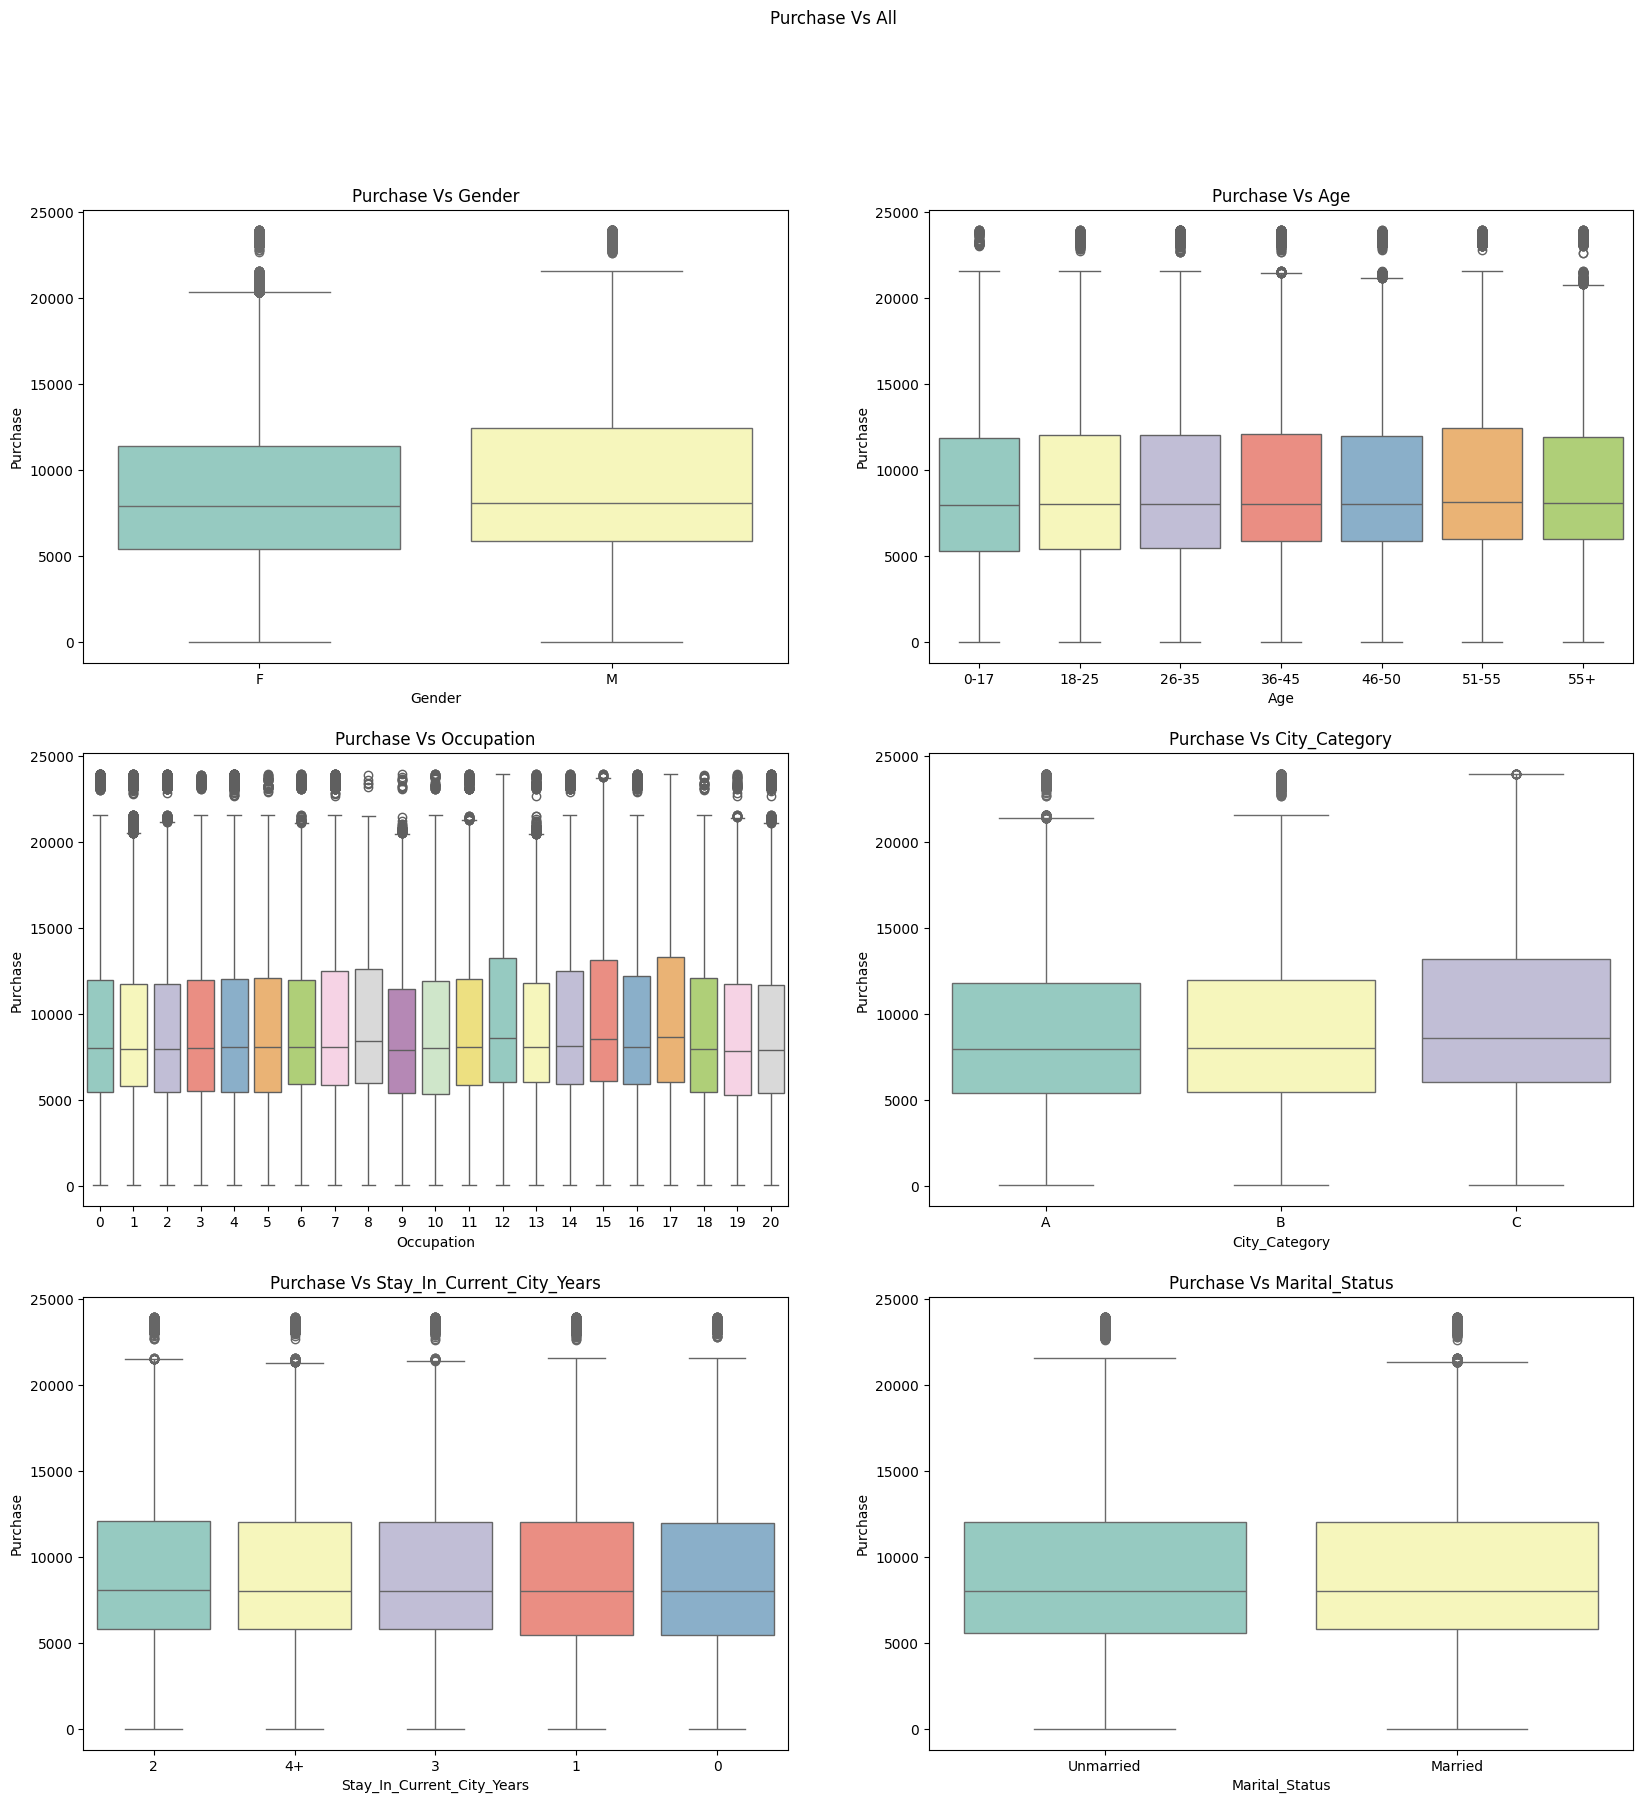

In [27]:
plt.figure(figsize= (20, 20))
plt.suptitle('Purchase Vs All')

plt.subplot(3, 2, 1)
sns.boxplot(data, y= 'Purchase', x= 'Gender', hue= 'Gender', palette='Set3', legend=False)
plt.title('Purchase Vs Gender')

plt.subplot(3, 2, 2)
sns.boxplot(data, y= 'Purchase', x= 'Age', hue= 'Age', palette='Set3', legend=False)
plt.title('Purchase Vs Age')

plt.subplot(3, 2, 3)
sns.boxplot(data, y= 'Purchase', x= 'Occupation', hue= 'Occupation', palette='Set3', legend=False)
plt.title('Purchase Vs Occupation')

plt.subplot(3, 2, 4)
sns.boxplot(data, y= 'Purchase', x= 'City_Category', hue= 'City_Category', palette='Set3', legend=False)
plt.title('Purchase Vs City_Category')

plt.subplot(3, 2, 5)
sns.boxplot(data, y= 'Purchase', x= 'Stay_In_Current_City_Years', hue= 'Stay_In_Current_City_Years', palette='Set3', legend=False)
plt.title('Purchase Vs Stay_In_Current_City_Years')

plt.subplot(3, 2, 6)
sns.boxplot(data, y= 'Purchase', x= 'Marital_Status', hue= 'Marital_Status', palette='Set3', legend=False)
plt.title('Purchase Vs Marital_Status')

plt.show()

**Age VS Product**

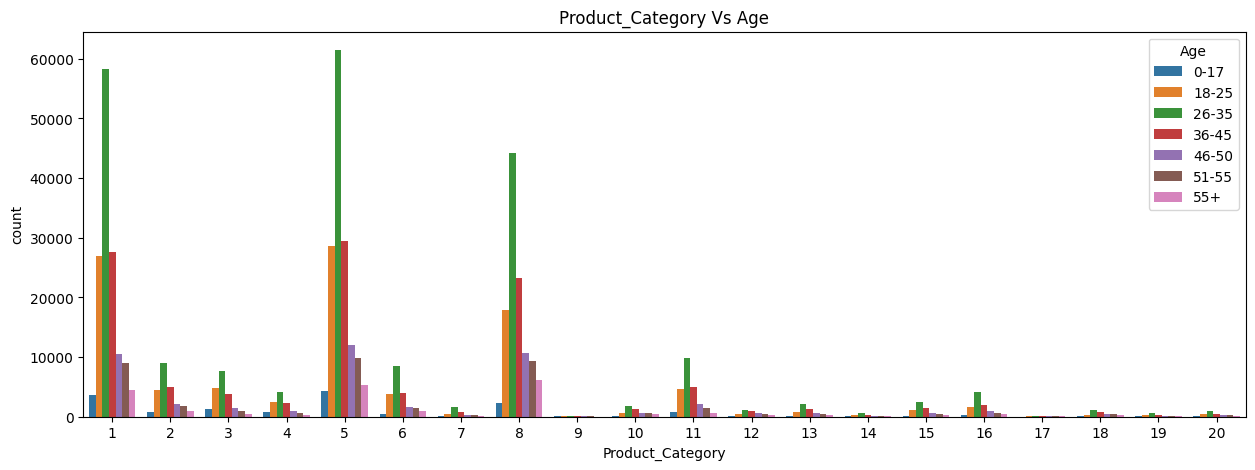

In [28]:
plt.figure(figsize=(15,5))
plt.title('Product_Category Vs Age')
sns.countplot(data, x= 'Product_Category', hue= 'Age')
plt.show()

**Gender VS Product**

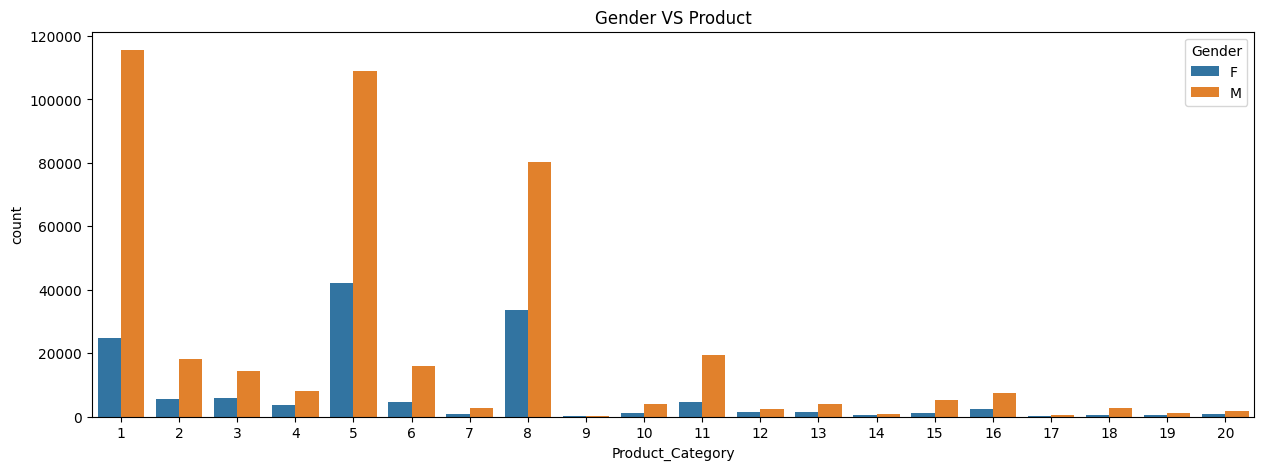

In [29]:
plt.figure(figsize=(15,5))
plt.title('Gender VS Product')
sns.countplot(data, x= 'Product_Category', hue= 'Gender')
plt.show()

**Correlation**

In [30]:
#Converting categorical data to numerical datas for better analysis on correlation
data_copy= data[['Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase']].copy()

data_copy['Gender']= data_copy['Gender'].replace(['M', 'F'], [0, 1])

data_copy['Age']= data_copy['Age'].replace(['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+'], [0, 1, 2, 3, 4, 5, 6])

data_copy['City_Category']= data_copy['City_Category'].replace(['A', 'C', 'B'], [0, 1, 2])

data_copy['Stay_In_Current_City_Years']= data_copy['Stay_In_Current_City_Years'].replace(['0', '1', '2', '3', '4+'], [0, 1, 2, 3, 4])

data_copy['Marital_Status']= data_copy['Marital_Status'].replace(['Unmarried', 'Married'], [0, 1])

<ipython-input-30-cfb28d409a3b>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_copy['Gender']= data_copy['Gender'].replace(['M', 'F'], [0, 1])
<ipython-input-30-cfb28d409a3b>:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data_copy['Gender']= data_copy['Gender'].replace(['M', 'F'], [0, 1])
<ipython-input-30-cfb28d409a3b>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, 

In [31]:
data_copy.corr()

,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
Gender,1.000000,0.004262,-0.117291,0.007688,-0.014660,0.011603,0.045594,-0.060346
Age,0.004262,1.000000,0.091463,0.041047,-0.004712,0.311738,0.061197,0.015839
Occupation,-0.117291,0.091463,1.000000,0.005470,0.030005,0.024280,-0.007618,0.020833
City_Category,0.007688,0.041047,0.005470,1.000000,0.019280,0.016846,-0.012204,0.011513
Stay_In_Current_City_Years,-0.014660,-0.004712,0.030005,0.019280,1.000000,-0.012819,-0.004213,0.005422
Marital_Status,0.011603,0.311738,0.024280,0.016846,-0.012819,1.000000,0.019888,-0.000463
Product_Category,0.045594,0.061197,-0.007618,-0.012204,-0.004213,0.019888,1.000000,-0.343703
Purchase,-0.060346,0.015839,0.020833,0.011513,0.005422,-0.000463,-0.343703,1.000000


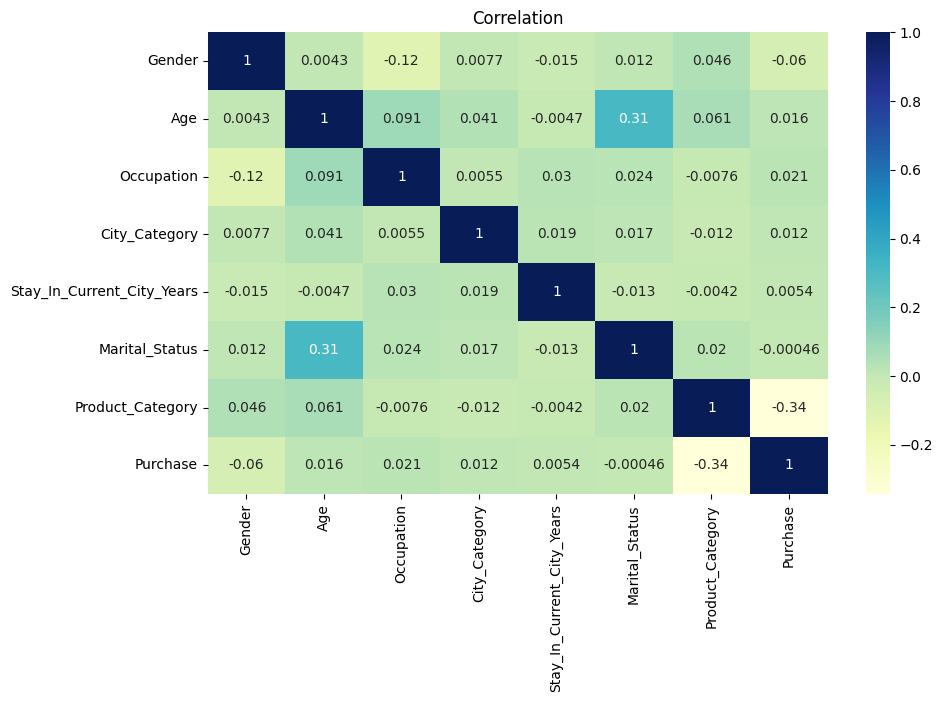

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(data_copy.corr(), cmap="YlGnBu", annot=True)
plt.title('Correlation')
plt.show()

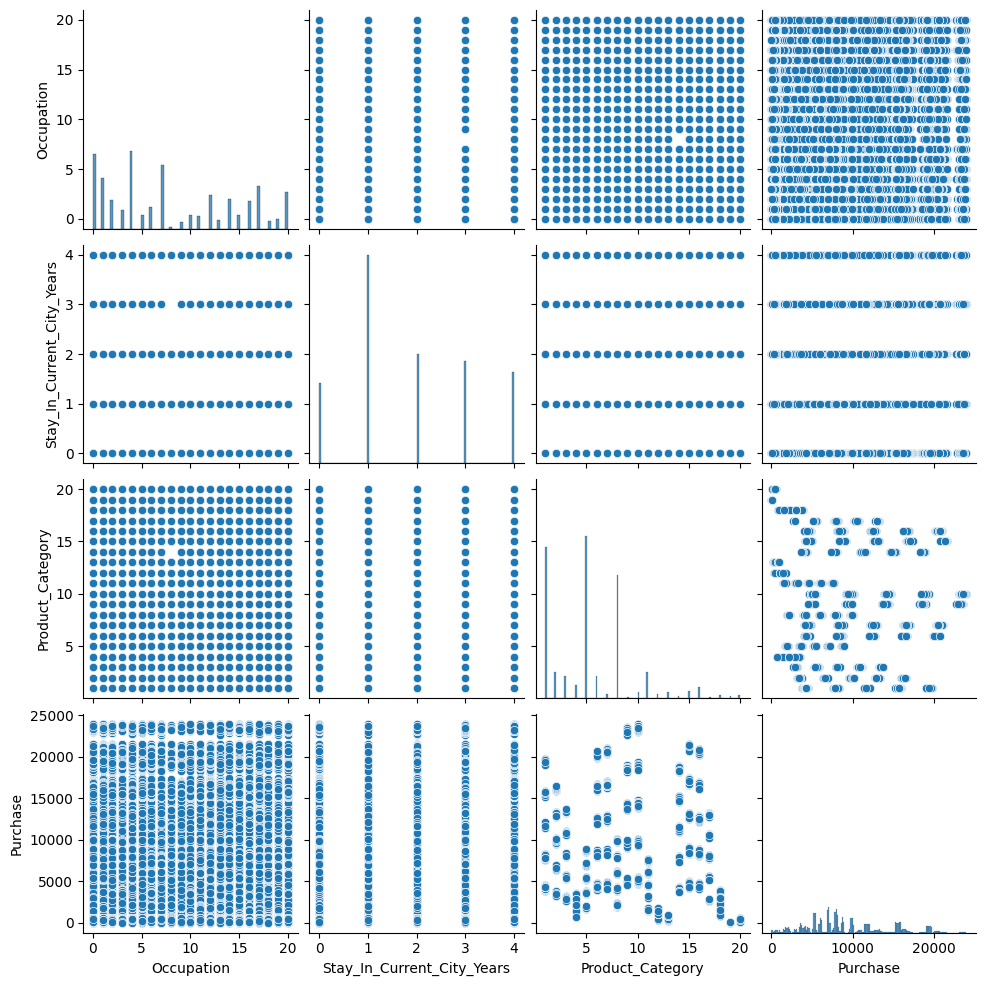

In [33]:
sns.pairplot(data= data_copy)
plt.show()

# **3. Missing Value & Outlier Detection**

**a. Find the outliers for every continuous variable in the dataset**

**Hint: Use boxplots to find the outliers in the given dataset**

**b. Remove/clip the data between the 5 percentile and 95 percentile**

**Hint: You can use np.clip() for clipping the data**

**1. Missing Values**

In [34]:
data.isna().any()

,0
User_ID,False
Product_ID,False
Gender,False
Age,False
Occupation,False
City_Category,False
Stay_In_Current_City_Years,False
Marital_Status,False
Product_Category,False
Purchase,False


In [35]:
data.isna().sum().sum()

0

*>**Insight:** There are no missing values in dataset.*

**2. Outlier Detection**

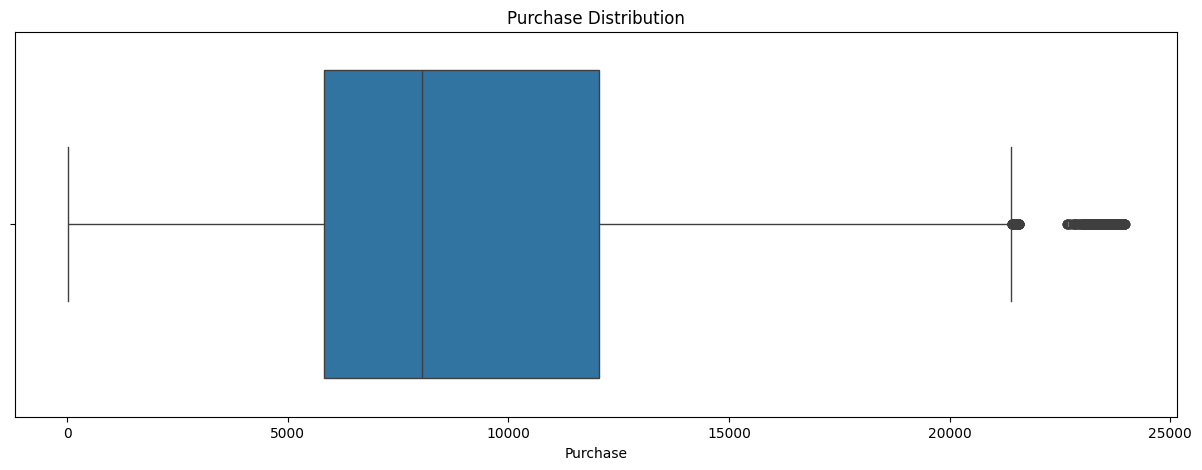

In [36]:
plt.figure(figsize=(15,5))
sns.boxplot(data, x= 'Purchase')
plt.title('Purchase Distribution')
plt.show()

In [37]:
q1=data.Purchase.quantile(0.25)
q3=data.Purchase.quantile(0.75)
print(q1,q3)
IQR=q3-q1
outliers = data[((data.Purchase<(q1-1.5*IQR)) | (data.Purchase>(q3+1.5*IQR)))]
print("num outliers : ",len(outliers))
print("percent outliers : ",len(outliers)/len(data))

5823.0 12054.0
num outliers :  2677
percent outliers :  0.004866671029763593


**Treatement Of Outliers**

**We Can Clip The Data Between 5 Percentile and 95 Percentile Or Drop The Outliers**

In [38]:
#Option 1: Code to clip data
# p5= np.percentile(data['Purchase'], 5)
# p95= np.percentile(data['Purchase'], 95)
# data['Purchase']= np.clip(data['Purchase'], p5, p95)

#Option 2: Drop the Outliers
data=data.drop(data[(data.Purchase > (q3+1.5*IQR)) | (data.Purchase < (q1-1.5*IQR))].index)

**After Treatement Of Outliers**

**After Dropping The Outliers**

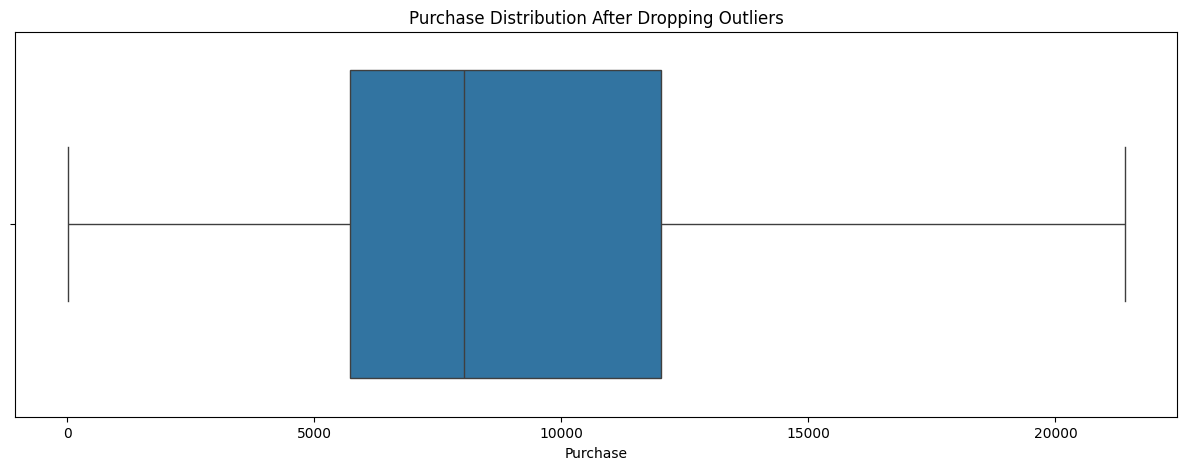

In [39]:
plt.figure(figsize=(15,5))
sns.boxplot(data, x= 'Purchase')
plt.title('Purchase Distribution After Dropping Outliers')
plt.show()

# **4. How does gender affect the amount spent?**
**Hint: Use the central limit theorem or bootstrapping to compute the 95% confidence intervals for the average amount spent per gender. First, compute the confidence interval for whatever data is available, and then repeat the same with smaller sample sizes - 300, 3000, and 30000.**

In [40]:
data.groupby('Gender')['Purchase'].describe()

<ipython-input-40-8f3cb5ae094b>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Gender')['Purchase'].describe()


,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,135220.0,8671.049039,4679.058483,12.0,5429.0,7906.0,11064.0,21398.0
M,412171.0,9367.724355,5009.234088,12.0,5852.0,8089.0,12247.0,21399.0


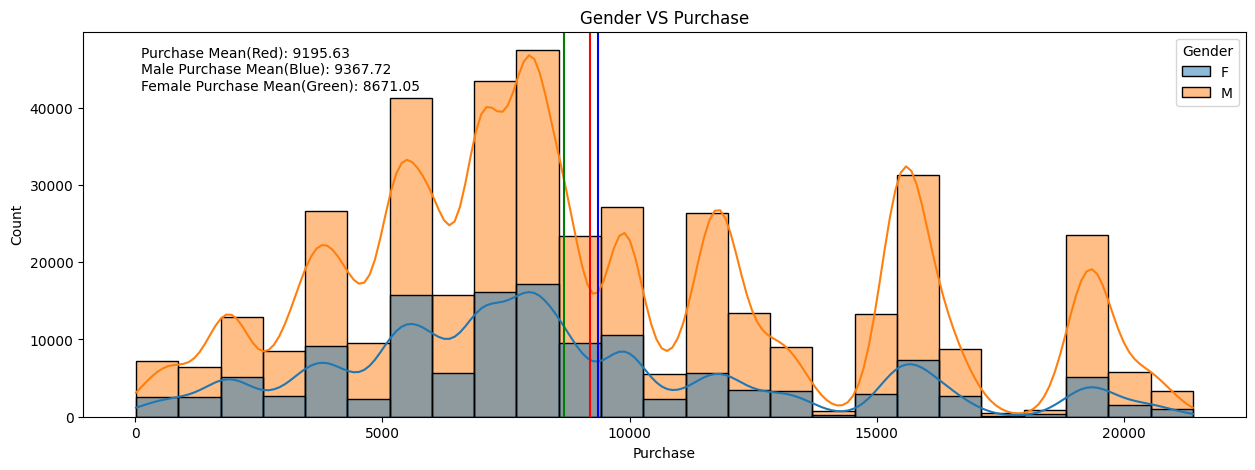

In [41]:
plt.figure(figsize=(15,5))
sns.histplot(data, bins=25, x= 'Purchase', hue= 'Gender', fill= True, kde= True)
plt.title('Gender VS Purchase')

plt.axvline(x= data['Purchase'].mean(), color='r')
mean= data['Purchase'].mean()
plt.axvline(x= data[data['Gender']=='M']['Purchase'].mean(), color='b')
m_mean= data[data['Gender']=='M']['Purchase'].mean()
plt.axvline(x= data[data['Gender']=='F']['Purchase'].mean(), color='g')
f_mean= data[data['Gender']=='F']['Purchase'].mean()
plt.annotate(f'Purchase Mean(Red): {np.round(mean, 2)} \nMale Purchase Mean(Blue): {np.round(m_mean, 2)} \nFemale Purchase Mean(Green): {np.round(f_mean, 2)}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=10)

plt.show()

In [42]:
print('Male Purchase Amount Mean:', data.loc[data['Gender']== 'M', 'Purchase'].mean())
print('Male Purchase Amount Std Dev:', data.loc[data['Gender']== 'M', 'Purchase'].std())
print()
print('Female Purchase Amount Mean:', data.loc[data['Gender']== 'F', 'Purchase'].mean())
print('Female Purchase Amount Std Dev:', data.loc[data['Gender']== 'F', 'Purchase'].std())

Male Purchase Amount Mean: 9367.724354697444
Male Purchase Amount Std Dev: 5009.234087946683

Female Purchase Amount Mean: 8671.049038603756
Female Purchase Amount Std Dev: 4679.058483084425


**95% Confidence Interval For The Average Amount Spent By Male.**

**Sample Size: 300**

In [43]:
sample_size= 300
Gender= 'M'
male_sample_mean_300= [np.mean(data.loc[data['Gender']== Gender, 'Purchase'].sample(sample_size, replace= True)) for i in range(1000)]
mean= np.mean(male_sample_mean_300)
se= data.loc[data['Gender']== Gender, 'Purchase'].std()/np.sqrt(sample_size)

In [44]:
print('Male Purchase Amount- Mean Of Sample Means:', mean)
print('Male Purchase Amount- Std Error Of Sample Means:', se)

Male Purchase Amount- Mean Of Sample Means: 9374.685413333335
Male Purchase Amount- Std Error Of Sample Means: 289.20826491098666


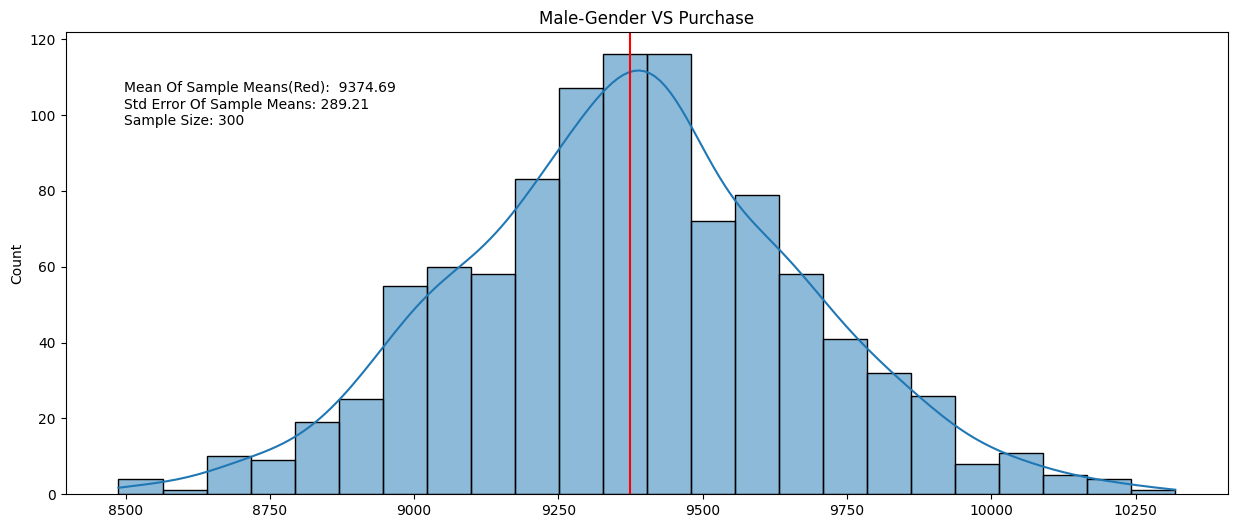

In [45]:
plt.figure(figsize=(15,6))
plt.title('Male-Gender VS Purchase')
sns.histplot(male_sample_mean_300, kde= True, fill= True)
plt.axvline(x= np.mean(male_sample_mean_300), color='r')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(male_sample_mean_300) : .2f} \nStd Error Of Sample Means: {np.round(se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
plt.show()

In [46]:
male_lower_bound= mean + (norm.ppf(0.025) * se)
male_upper_bound= mean + (norm.ppf(0.975) * se)
print('95% Confidence Interval For The Average Amount Spent By Male For Sample Size 300:', (male_lower_bound, male_upper_bound))

95% Confidence Interval For The Average Amount Spent By Male For Sample Size 300: (8807.847630076481, 9941.523196590188)


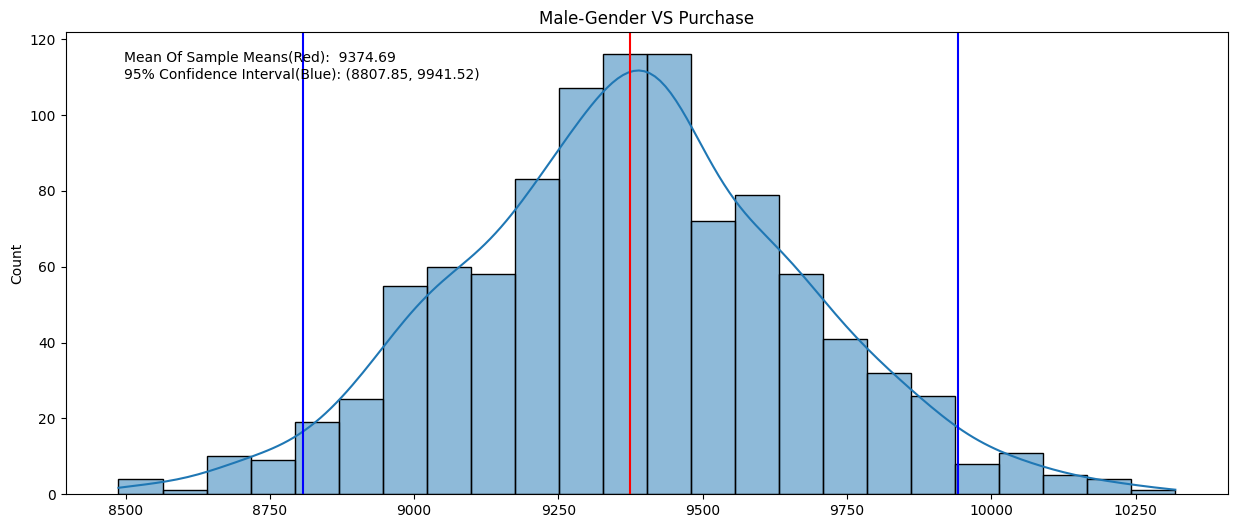

In [47]:
plt.figure(figsize=(15,6))
plt.title('Male-Gender VS Purchase')
sns.histplot(male_sample_mean_300, kde= True, fill= True)
plt.axvline(x= np.mean(male_sample_mean_300), color='r')
plt.axvline(x= male_lower_bound, color='b')
plt.axvline(x= male_upper_bound, color='b')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(male_sample_mean_300) : .2f} \n95% Confidence Interval(Blue): {(np.round(male_lower_bound, 2), np.round(male_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
plt.show()

**95% Confidence Interval For The Average Amount Spent By Female.**

**Sample Size: 300**

In [48]:
sample_size= 300
Gender= 'F'
female_sample_mean_300= [np.mean(data.loc[data['Gender']== Gender, 'Purchase'].sample(sample_size, replace= True)) for i in range(1000)]
mean= np.mean(female_sample_mean_300)
se= data.loc[data['Gender']== Gender, 'Purchase'].std()/np.sqrt(sample_size)

In [49]:
print('Female Purchase Amount- Mean Of Sample Means:', mean)
print('Female Purchase Amount- Std Error Of Sample Means:', se)

Female Purchase Amount- Mean Of Sample Means: 8675.704806666665
Female Purchase Amount- Std Error Of Sample Means: 270.14556747627944


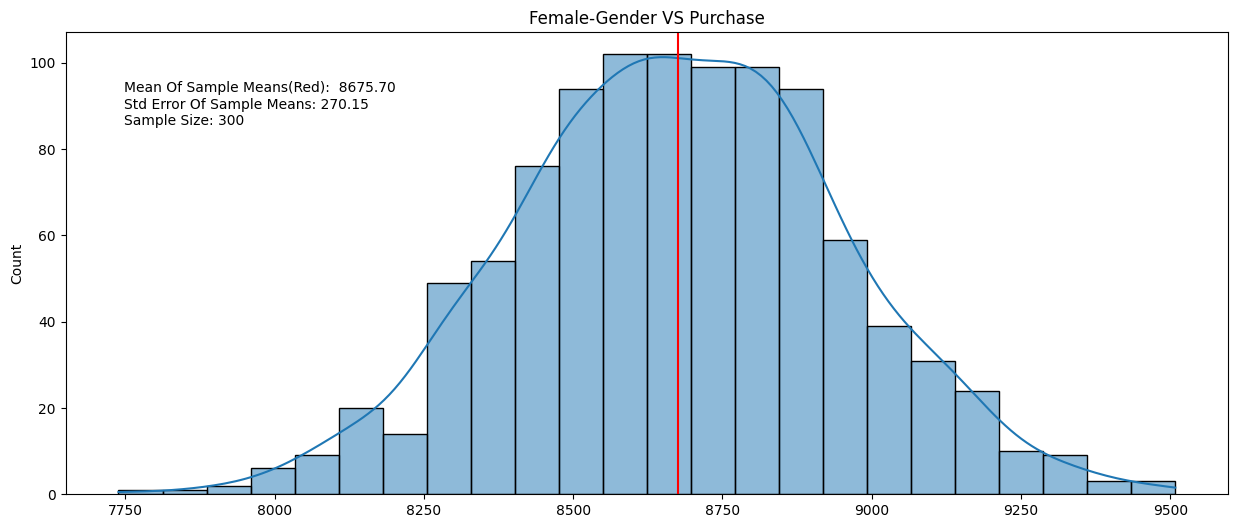

In [50]:
plt.figure(figsize=(15,6))
plt.title('Female-Gender VS Purchase')
sns.histplot(female_sample_mean_300, kde= True, fill= True)
plt.axvline(x= np.mean(female_sample_mean_300), color='r')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(female_sample_mean_300) : .2f} \nStd Error Of Sample Means: {np.round(se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
plt.show()

In [51]:
female_lower_bound= mean + (norm.ppf(0.025) * se)
female_upper_bound= mean + (norm.ppf(0.975) * se)
print('95% Confidence Interval For The Average Amount Spent By Female For Sample Size 300:', (female_lower_bound, female_upper_bound))

95% Confidence Interval For The Average Amount Spent By Female For Sample Size 300: (8146.2292238300215, 9205.180389503308)


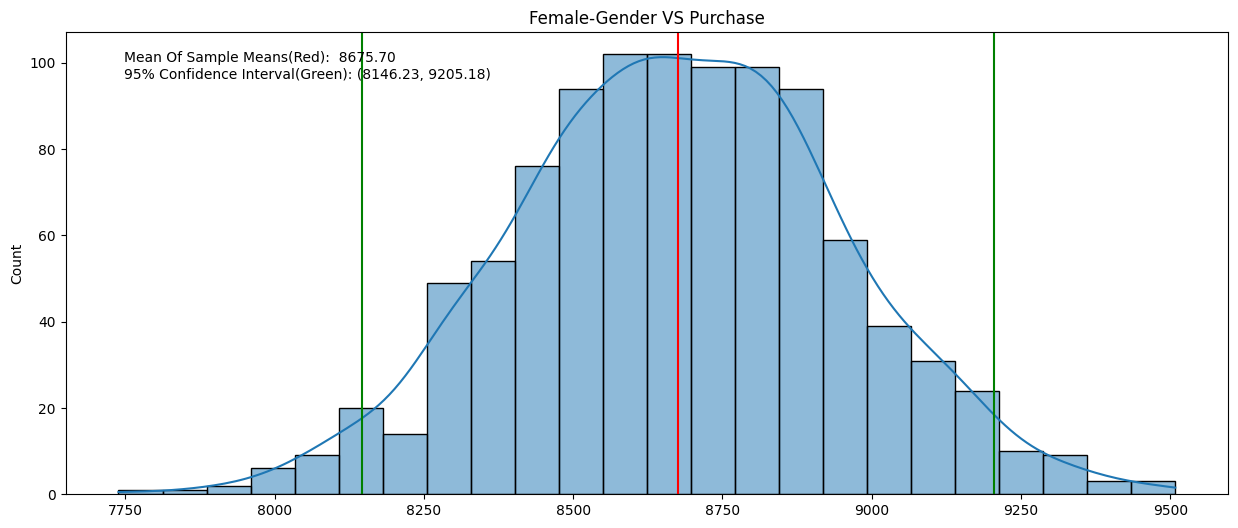

In [52]:
plt.figure(figsize=(15,6))
plt.title('Female-Gender VS Purchase')
sns.histplot(female_sample_mean_300, kde= True, fill= True)
plt.axvline(x= np.mean(female_sample_mean_300), color='r')
plt.axvline(x= female_lower_bound, color='g')
plt.axvline(x= female_upper_bound, color='g')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(female_sample_mean_300) : .2f} \n95% Confidence Interval(Green): {(np.round(female_lower_bound, 2), np.round(female_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
plt.show()

**Overlapping ?**

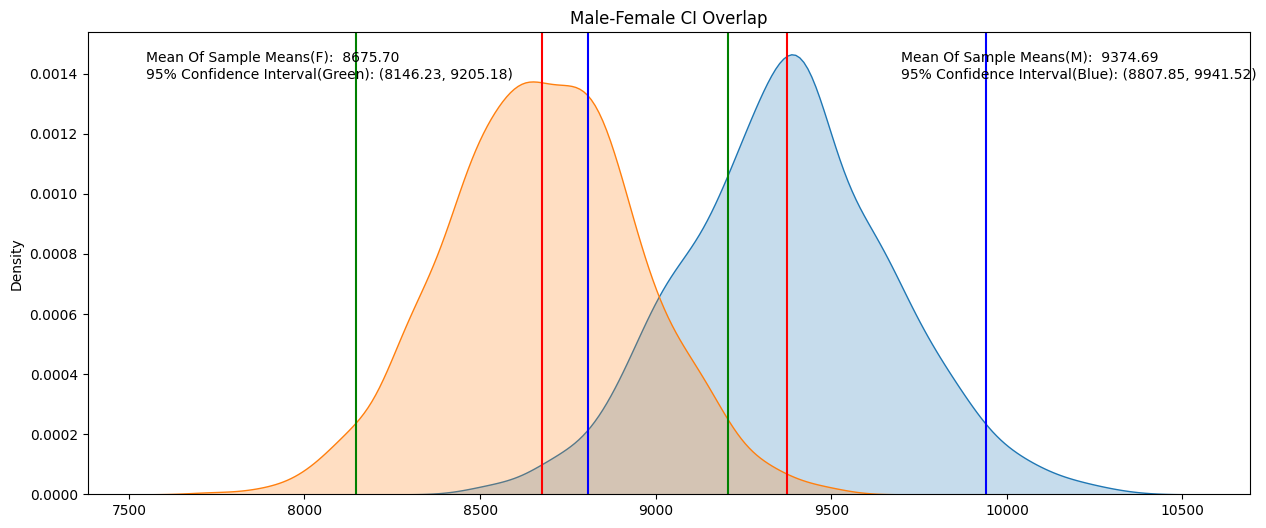

In [53]:
plt.figure(figsize=(15,6))
plt.title('Male-Female CI Overlap')
sns.kdeplot(male_sample_mean_300, fill= True)
sns.kdeplot(female_sample_mean_300, fill= True)
plt.axvline(x= np.mean(male_sample_mean_300), color='r')
plt.axvline(x= male_lower_bound, color='b')
plt.axvline(x= male_upper_bound, color='b')
plt.axvline(x= np.mean(female_sample_mean_300), color='r')
plt.axvline(x= female_lower_bound, color='g')
plt.axvline(x= female_upper_bound, color='g')
plt.annotate(f'Mean Of Sample Means(M): {np.mean(male_sample_mean_300) : .2f} \n95% Confidence Interval(Blue): {(np.round(male_lower_bound, 2), np.round(male_upper_bound,2))}', xy=(0.70, 0.90), xycoords='axes fraction', fontsize=10)
plt.annotate(f'Mean Of Sample Means(F): {np.mean(female_sample_mean_300) : .2f} \n95% Confidence Interval(Green): {(np.round(female_lower_bound, 2), np.round(female_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)

plt.show()

**95% Confidence Interval For The Average Amount Spent By Male.**

**Sample Size: 3000**

In [54]:
sample_size= 3000
Gender= 'M'
male_sample_mean_3000= [np.mean(data.loc[data['Gender']== Gender, 'Purchase'].sample(sample_size, replace= True)) for i in range(1000)]
mean= np.mean(male_sample_mean_3000)
se= data.loc[data['Gender']== Gender, 'Purchase'].std()/np.sqrt(sample_size)

In [55]:
print('Male Purchase Amount- Mean Of Sample Means:', mean)
print('Male Purchase Amount- Std Error Of Sample Means:', se)

Male Purchase Amount- Mean Of Sample Means: 9374.881909333333
Male Purchase Amount- Std Error Of Sample Means: 91.45568352640717


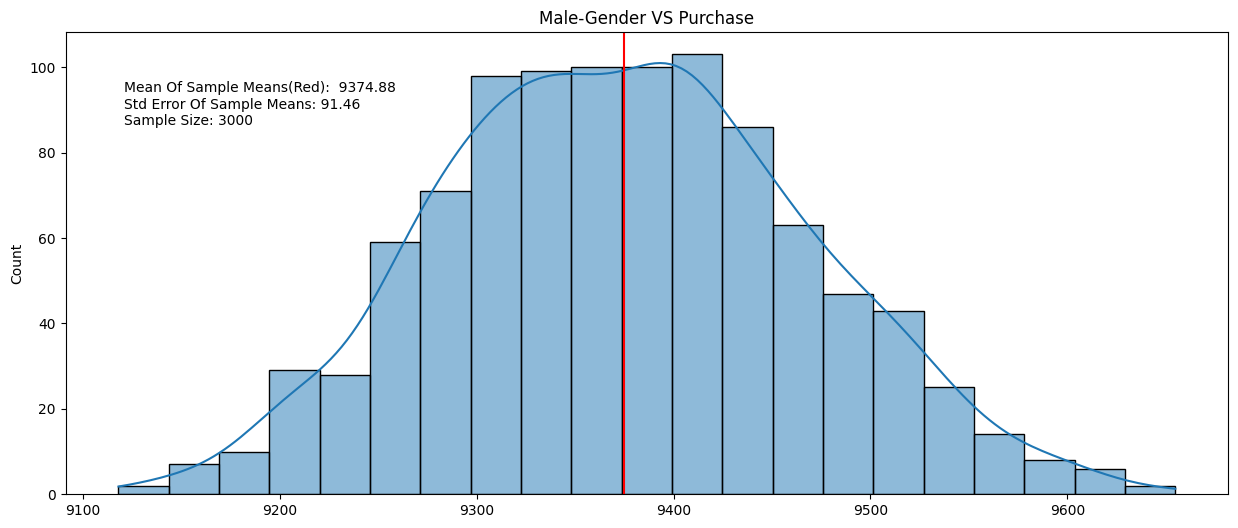

In [56]:
plt.figure(figsize=(15,6))
plt.title('Male-Gender VS Purchase')
sns.histplot(male_sample_mean_3000, kde= True, fill= True)
plt.axvline(x= np.mean(male_sample_mean_3000), color='r')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(male_sample_mean_3000) : .2f} \nStd Error Of Sample Means: {np.round(se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
plt.show()

In [57]:
male_lower_bound= mean + (norm.ppf(0.025) * se)
male_upper_bound= mean + (norm.ppf(0.975) * se)
print('95% Confidence Interval For The Average Amount Spent By Male For Sample Size 3000:', (male_lower_bound, male_upper_bound))

95% Confidence Interval For The Average Amount Spent By Male For Sample Size 3000: (9195.632063440082, 9554.131755226585)


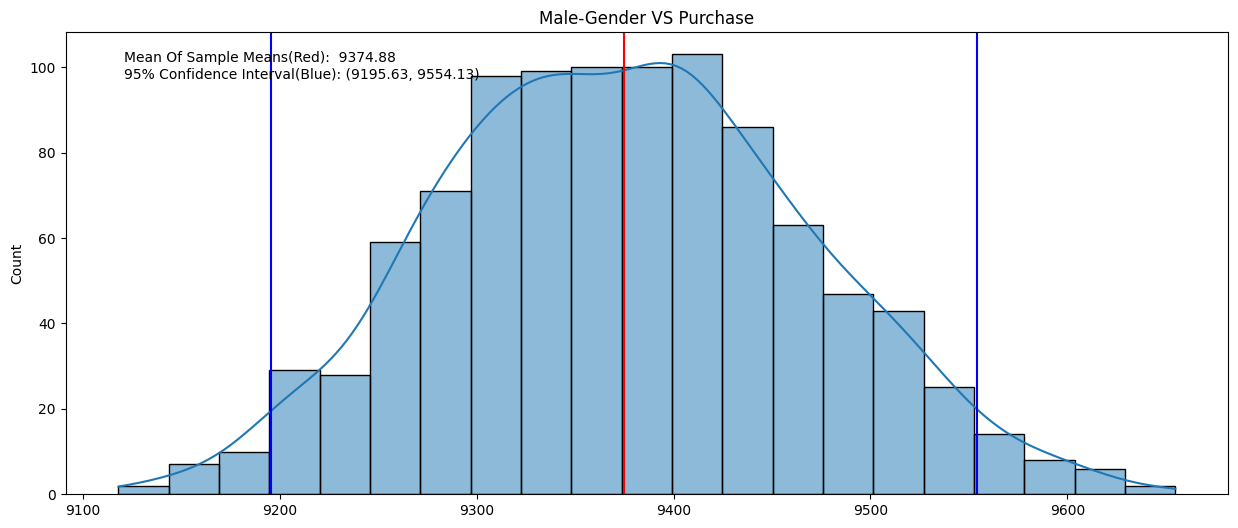

In [58]:
plt.figure(figsize=(15,6))
plt.title('Male-Gender VS Purchase')
sns.histplot(male_sample_mean_3000, kde= True, fill= True)
plt.axvline(x= np.mean(male_sample_mean_3000), color='r')
plt.axvline(x= male_lower_bound, color='b')
plt.axvline(x= male_upper_bound, color='b')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(male_sample_mean_3000) : .2f} \n95% Confidence Interval(Blue): {(np.round(male_lower_bound, 2), np.round(male_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
plt.show()

**95% Confidence Interval For The Average Amount Spent By Female.**

**Sample Size: 3000**

In [59]:
sample_size= 3000
Gender= 'F'
female_sample_mean_3000= [np.mean(data.loc[data['Gender']== Gender, 'Purchase'].sample(sample_size, replace= True)) for i in range(1000)]
mean= np.mean(female_sample_mean_3000)
se= data.loc[data['Gender']== Gender, 'Purchase'].std()/np.sqrt(sample_size)

In [60]:
print('Female Purchase Amount- Mean Of Sample Means:', mean)
print('Female Purchase Amount- Std Error Of Sample Means:', se)

Female Purchase Amount- Mean Of Sample Means: 8670.338688333335
Female Purchase Amount- Std Error Of Sample Means: 85.4275293023748


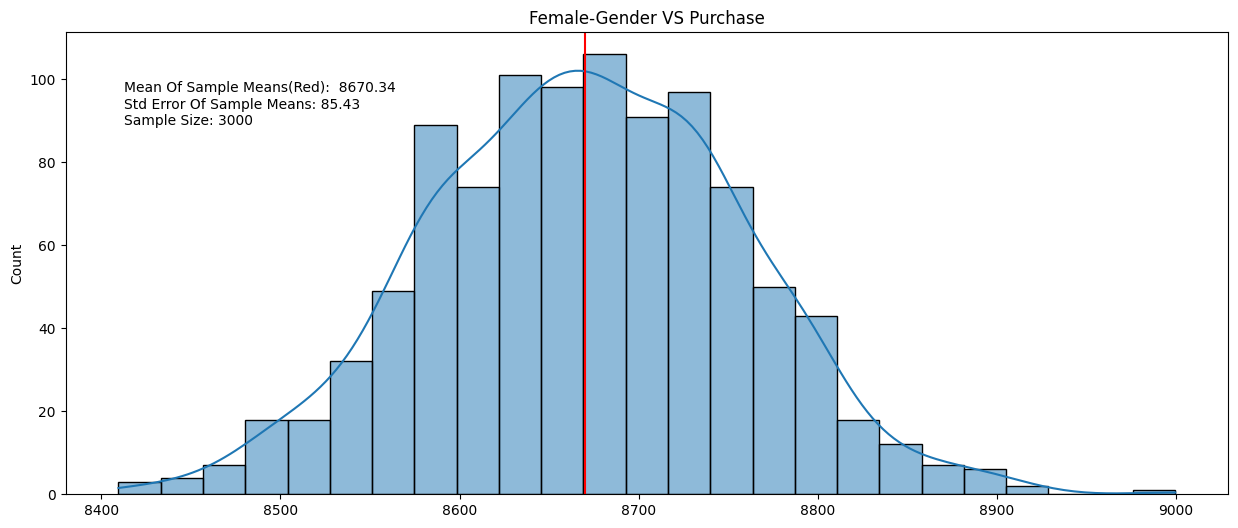

In [61]:
plt.figure(figsize=(15,6))
plt.title('Female-Gender VS Purchase')
sns.histplot(female_sample_mean_3000, kde= True, fill= True)
plt.axvline(x= np.mean(female_sample_mean_3000), color='r')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(female_sample_mean_3000) : .2f} \nStd Error Of Sample Means: {np.round(se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
plt.show()

In [62]:
female_lower_bound= mean + (norm.ppf(0.025) * se)
female_upper_bound= mean + (norm.ppf(0.975) * se)
print('95% Confidence Interval For The Average Amount Spent By Female For Sample Size 3000:', (female_lower_bound, female_upper_bound))

95% Confidence Interval For The Average Amount Spent By Female For Sample Size 3000: (8502.90380761244, 8837.77356905423)


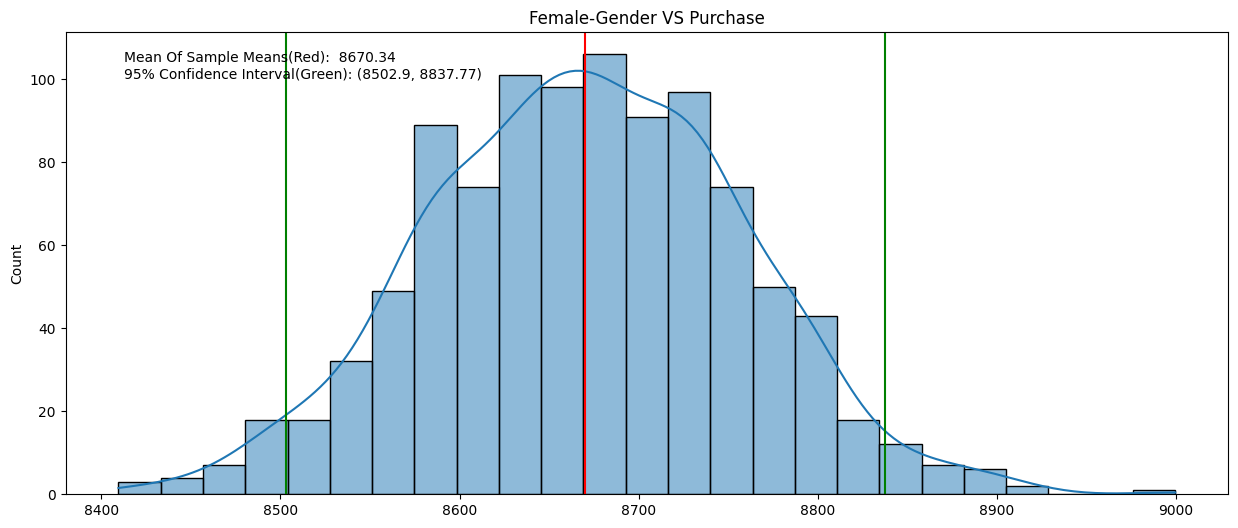

In [63]:
plt.figure(figsize=(15,6))
plt.title('Female-Gender VS Purchase')
sns.histplot(female_sample_mean_3000, kde= True, fill= True)
plt.axvline(x= np.mean(female_sample_mean_3000), color='r')
plt.axvline(x= female_lower_bound, color='g')
plt.axvline(x= female_upper_bound, color='g')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(female_sample_mean_3000) : .2f} \n95% Confidence Interval(Green): {(np.round(female_lower_bound, 2), np.round(female_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
plt.show()

**Overlapping ?**

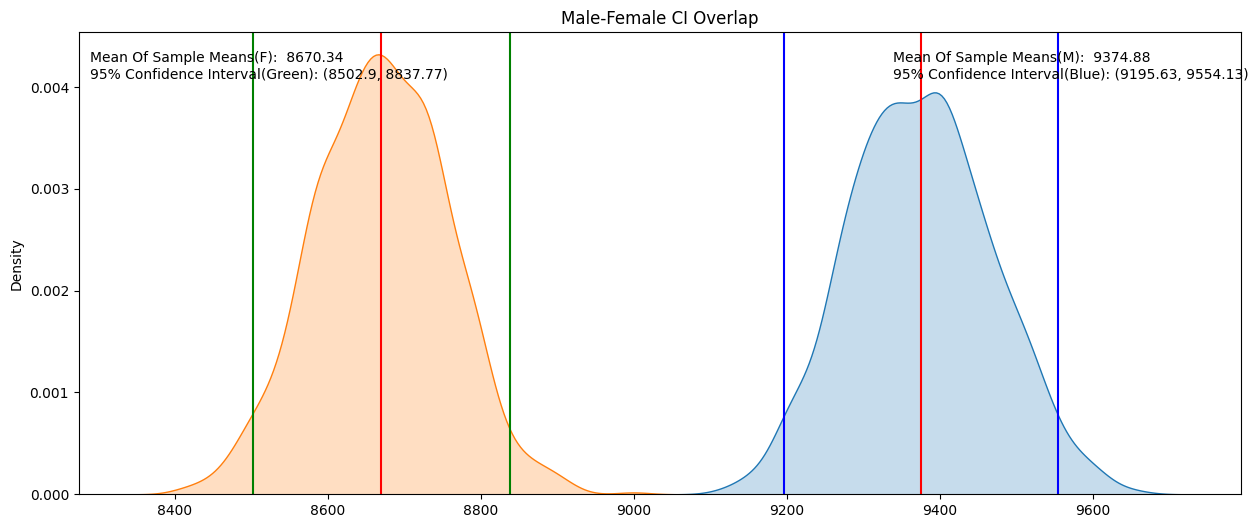

In [64]:
plt.figure(figsize=(15,6))
plt.title('Male-Female CI Overlap')
sns.kdeplot(male_sample_mean_3000, fill= True)
sns.kdeplot(female_sample_mean_3000, fill= True)
plt.axvline(x= np.mean(male_sample_mean_3000), color='r')
plt.axvline(x= male_lower_bound, color='b')
plt.axvline(x= male_upper_bound, color='b')
plt.axvline(x= np.mean(female_sample_mean_3000), color='r')
plt.axvline(x= female_lower_bound, color='g')
plt.axvline(x= female_upper_bound, color='g')
plt.annotate(f'Mean Of Sample Means(M): {np.mean(male_sample_mean_3000) : .2f} \n95% Confidence Interval(Blue): {(np.round(male_lower_bound, 2), np.round(male_upper_bound,2))}', xy=(0.70, 0.90), xycoords='axes fraction', fontsize=10)
plt.annotate(f'Mean Of Sample Means(F): {np.mean(female_sample_mean_3000) : .2f} \n95% Confidence Interval(Green): {(np.round(female_lower_bound, 2), np.round(female_upper_bound,2))}', xy=(0.01, 0.90), xycoords='axes fraction', fontsize=10)

plt.show()

**95% Confidence Interval For The Average Amount Spent By Male.**

**Sample Size: 30000**

In [65]:
sample_size= 30000
Gender= 'M'
male_sample_mean_30000= [np.mean(data.loc[data['Gender']== Gender, 'Purchase'].sample(sample_size, replace= True)) for i in range(1000)]
mean= np.mean(male_sample_mean_30000)
se= data.loc[data['Gender']== Gender, 'Purchase'].std()/np.sqrt(sample_size)

In [66]:
print('Male Purchase Amount- Mean Of Sample Means:', mean)
print('Male Purchase Amount- Std Error Of Sample Means:', se)

Male Purchase Amount- Mean Of Sample Means: 9367.707964500003
Male Purchase Amount- Std Error Of Sample Means: 28.92082649109867


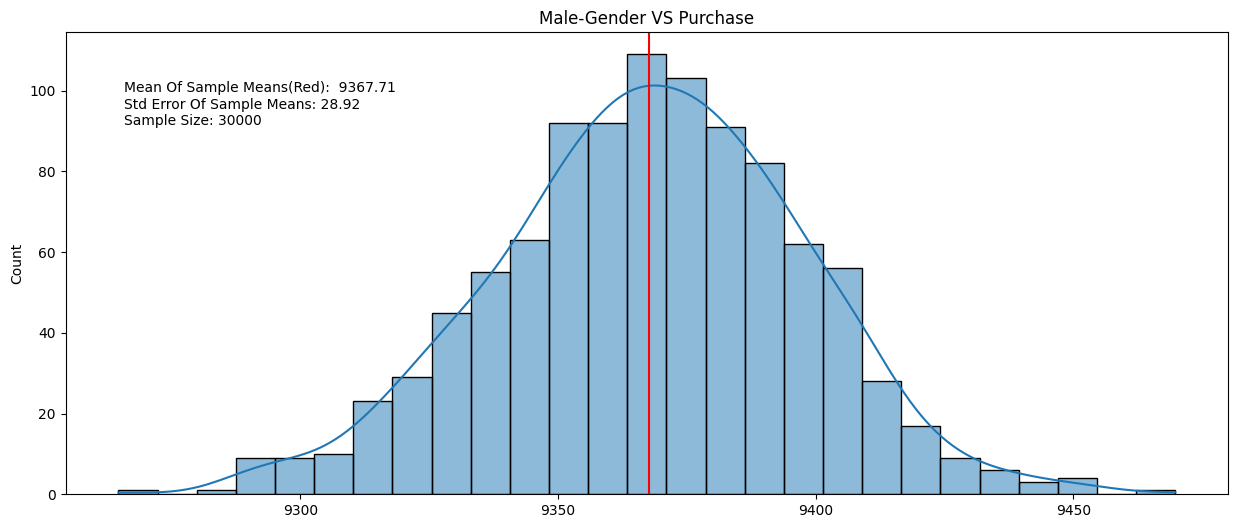

In [67]:
plt.figure(figsize=(15,6))
plt.title('Male-Gender VS Purchase')
sns.histplot(male_sample_mean_30000, kde= True, fill= True)
plt.axvline(x= np.mean(male_sample_mean_30000), color='r')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(male_sample_mean_30000) : .2f} \nStd Error Of Sample Means: {np.round(se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
plt.show()

In [68]:
male_lower_bound= mean + (norm.ppf(0.025) * se)
male_upper_bound= mean + (norm.ppf(0.975) * se)
print('95% Confidence Interval For The Average Amount Spent By Male For Sample Size 30000:', (male_lower_bound, male_upper_bound))

95% Confidence Interval For The Average Amount Spent By Male For Sample Size 30000: (9311.024186174318, 9424.391742825688)


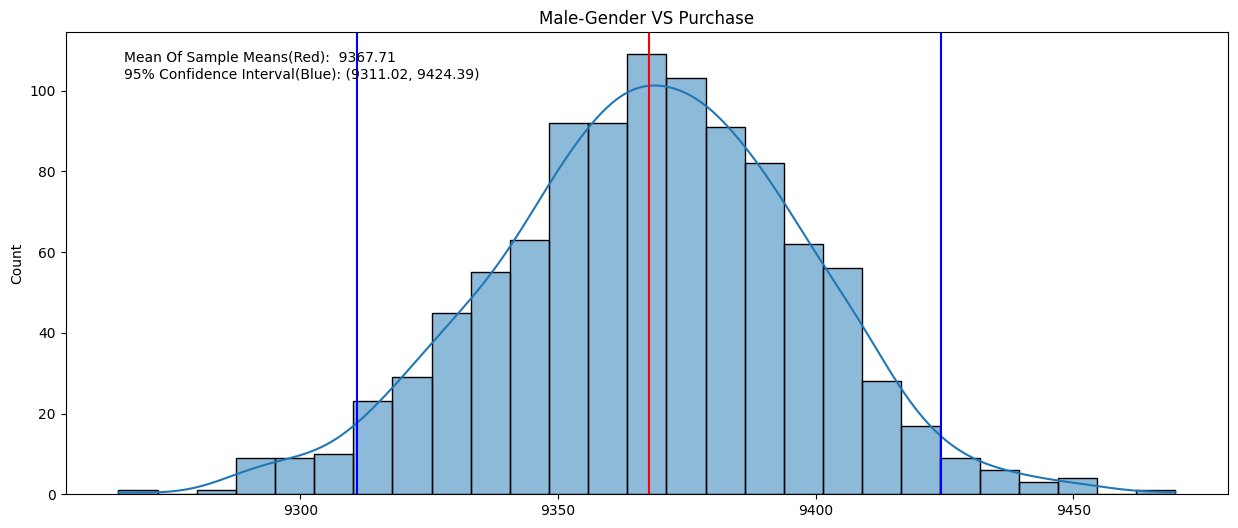

In [69]:
plt.figure(figsize=(15,6))
plt.title('Male-Gender VS Purchase')
sns.histplot(male_sample_mean_30000, kde= True, fill= True)
plt.axvline(x= np.mean(male_sample_mean_30000), color='r')
plt.axvline(x= male_lower_bound, color='b')
plt.axvline(x= male_upper_bound, color='b')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(male_sample_mean_30000) : .2f} \n95% Confidence Interval(Blue): {(np.round(male_lower_bound, 2), np.round(male_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
plt.show()

**95% Confidence Interval For The Average Amount Spent By Female.**

**Sample Size: 30000**

In [70]:
sample_size= 30000
Gender= 'F'
female_sample_mean_30000= [np.mean(data.loc[data['Gender']== Gender, 'Purchase'].sample(sample_size, replace= True)) for i in range(1000)]
mean= np.mean(female_sample_mean_30000)
se= data.loc[data['Gender']== Gender, 'Purchase'].std()/np.sqrt(sample_size)

In [71]:
print('Female Purchase Amount- Mean Of Sample Means:', mean)
print('Female Purchase Amount- Std Error Of Sample Means:', se)

Female Purchase Amount- Mean Of Sample Means: 8670.610333566665
Female Purchase Amount- Std Error Of Sample Means: 27.014556747627946


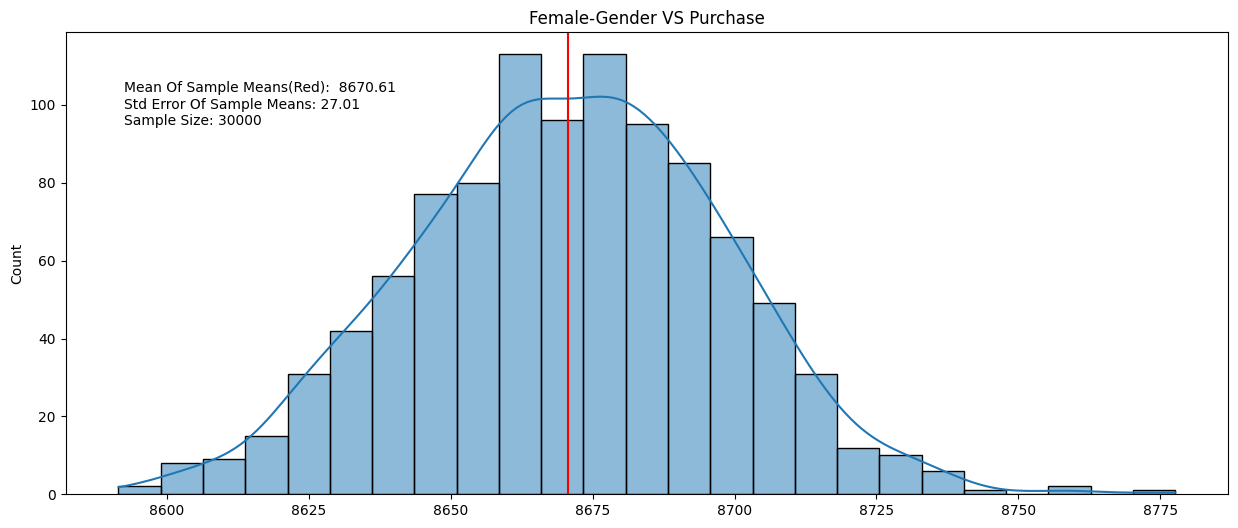

In [72]:
plt.figure(figsize=(15,6))
plt.title('Female-Gender VS Purchase')
sns.histplot(female_sample_mean_30000, kde= True, fill= True)
plt.axvline(x= np.mean(female_sample_mean_30000), color='r')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(female_sample_mean_30000) : .2f} \nStd Error Of Sample Means: {np.round(se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
plt.show()

In [73]:
female_lower_bound= mean + (norm.ppf(0.025) * se)
female_upper_bound= mean + (norm.ppf(0.975) * se)
print('95% Confidence Interval For The Average Amount Spent By Female For Sample Size 30000:', (female_lower_bound, female_upper_bound))

95% Confidence Interval For The Average Amount Spent By Female For Sample Size 30000: (8617.662775283, 8723.557891850329)


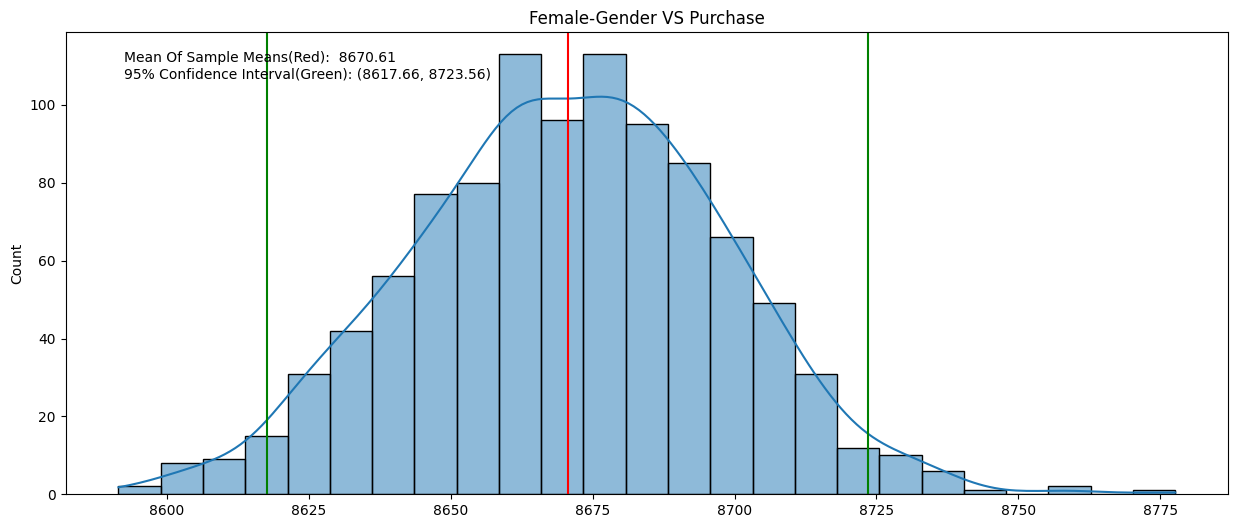

In [74]:
plt.figure(figsize=(15,6))
plt.title('Female-Gender VS Purchase')
sns.histplot(female_sample_mean_30000, kde= True, fill= True)
plt.axvline(x= np.mean(female_sample_mean_30000), color='r')
plt.axvline(x= female_lower_bound, color='g')
plt.axvline(x= female_upper_bound, color='g')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(female_sample_mean_30000) : .2f} \n95% Confidence Interval(Green): {(np.round(female_lower_bound, 2), np.round(female_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
plt.show()

**Overlapping ?**

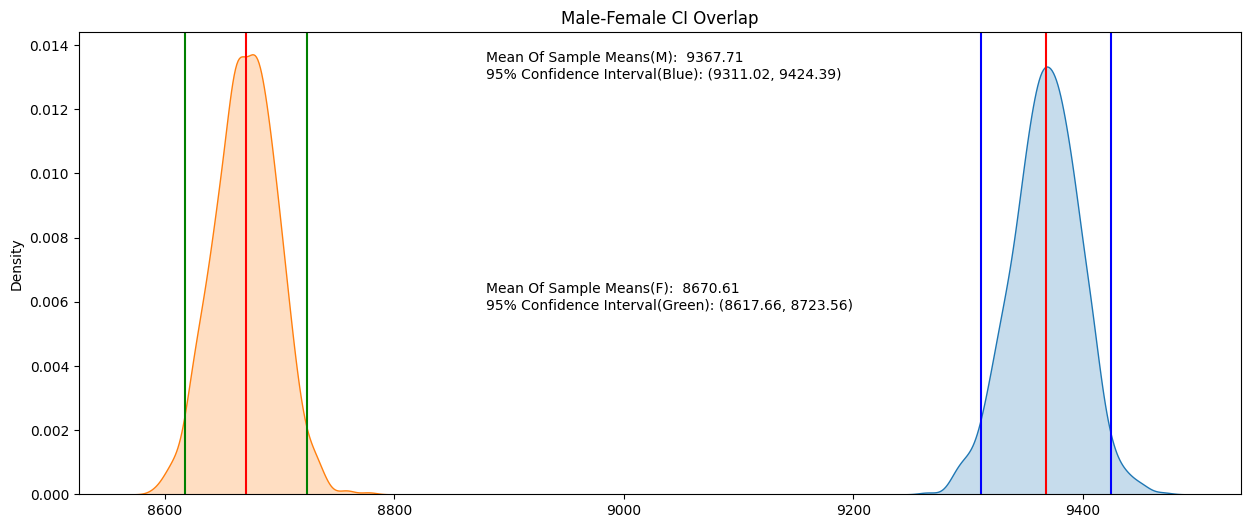

In [75]:
plt.figure(figsize=(15,6))
plt.title('Male-Female CI Overlap')
sns.kdeplot(male_sample_mean_30000, fill= True)
sns.kdeplot(female_sample_mean_30000, fill= True)
plt.axvline(x= np.mean(male_sample_mean_30000), color='r')
plt.axvline(x= male_lower_bound, color='b')
plt.axvline(x= male_upper_bound, color='b')
plt.axvline(x= np.mean(female_sample_mean_30000), color='r')
plt.axvline(x= female_lower_bound, color='g')
plt.axvline(x= female_upper_bound, color='g')
plt.annotate(f'Mean Of Sample Means(M): {np.mean(male_sample_mean_30000) : .2f} \n95% Confidence Interval(Blue): {(np.round(male_lower_bound, 2), np.round(male_upper_bound,2))}', xy=(0.35, 0.90), xycoords='axes fraction', fontsize=10)
plt.annotate(f'Mean Of Sample Means(F): {np.mean(female_sample_mean_30000) : .2f} \n95% Confidence Interval(Green): {(np.round(female_lower_bound, 2), np.round(female_upper_bound,2))}', xy=(0.35, 0.40), xycoords='axes fraction', fontsize=10)

plt.show()

**Conclusion: Males consistently outspend females on Black Friday, with higher average spending confirmed as sample size increases. Increasing the sample size reduces the standard error and narrows the confidence intervals, providing more precise estimates.**

# **5. How does Marital_Status affect the amount spent?**

**Hint: Use the central limit theorem and bootstrapping to compute the 95% confidence intervals for the average amount spent per Marital_Status. First, compute the confidence interval for whatever data is available, and then repeat the same with smaller sample sizes - 300, 3000, and 30000.**

In [76]:
data.groupby('Marital_Status')['Purchase'].describe()

<ipython-input-76-7dd739a0ebc2>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Marital_Status')['Purchase'].describe()


,count,mean,std,min,25%,50%,75%,max
Marital_Status,,,,,,,,
Unmarried,323242.0,9201.581849,4948.327397,12.0,5480.0,8035.0,12028.0,21399.0
Married,224149.0,9187.040076,4925.205232,12.0,5833.0,8042.0,12006.0,21398.0


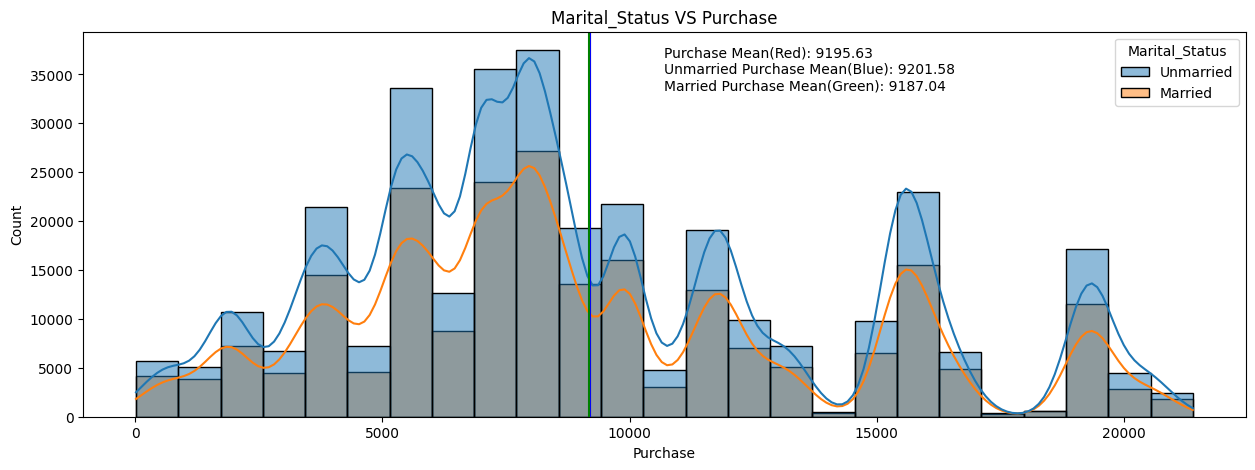

In [77]:
plt.figure(figsize=(15,5))
sns.histplot(data, bins=25, x= 'Purchase', hue= 'Marital_Status', fill= True, kde= True)
plt.title('Marital_Status VS Purchase')
plt.axvline(x= data['Purchase'].mean(), color='r')
mean= data['Purchase'].mean()
plt.axvline(x= data[data['Marital_Status']=='Unmarried']['Purchase'].mean(), color='b')
um_mean= data[data['Marital_Status']=='Unmarried']['Purchase'].mean()
plt.axvline(x= data[data['Marital_Status']=='Married']['Purchase'].mean(), color='g')
mm_mean= data[data['Marital_Status']=='Married']['Purchase'].mean()
plt.annotate(f'Purchase Mean(Red): {np.round(mean, 2)} \nUnmarried Purchase Mean(Blue): {np.round(um_mean, 2)} \nMarried Purchase Mean(Green): {np.round(mm_mean, 2)}', xy=(0.5, 0.85), xycoords='axes fraction', fontsize=10)
plt.show()

In [78]:
print('Unmarried Purchase Amount Mean:', data.loc[data['Marital_Status']== 'Unmarried', 'Purchase'].mean())
print('Unmarried Purchase Amount Std Dev:', data.loc[data['Marital_Status']== 'Unmarried', 'Purchase'].std())
print()
print('Married Purchase Amount Mean:', data.loc[data['Marital_Status']== 'Married', 'Purchase'].mean())
print('Married Purchase Amount Std Dev:', data.loc[data['Marital_Status']== 'Married', 'Purchase'].std())

Unmarried Purchase Amount Mean: 9201.581848893398
Unmarried Purchase Amount Std Dev: 4948.327397459098

Married Purchase Amount Mean: 9187.040076020861
Married Purchase Amount Std Dev: 4925.205231851271


**95% Confidence Interval For The Average Amount Spent By Unmarried.**

**Sample Size: 300**

In [79]:
sample_size= 300
Marital_Status= 'Unmarried'
Unmarried_sample_mean_300= [np.mean(data.loc[data['Marital_Status']== Marital_Status, 'Purchase'].sample(sample_size, replace= True)) for i in range(1000)]
mean= np.mean(Unmarried_sample_mean_300)
se= data.loc[data['Marital_Status']== Marital_Status, 'Purchase'].std()/np.sqrt(sample_size)

In [80]:
print('Unmarried Purchase Amount- Mean Of Sample Means:', mean)
print('Unmarried Purchase Amount- Std Error Of Sample Means:', se)

Unmarried Purchase Amount- Mean Of Sample Means: 9207.771050000001
Unmarried Purchase Amount- Std Error Of Sample Means: 285.69181549614103


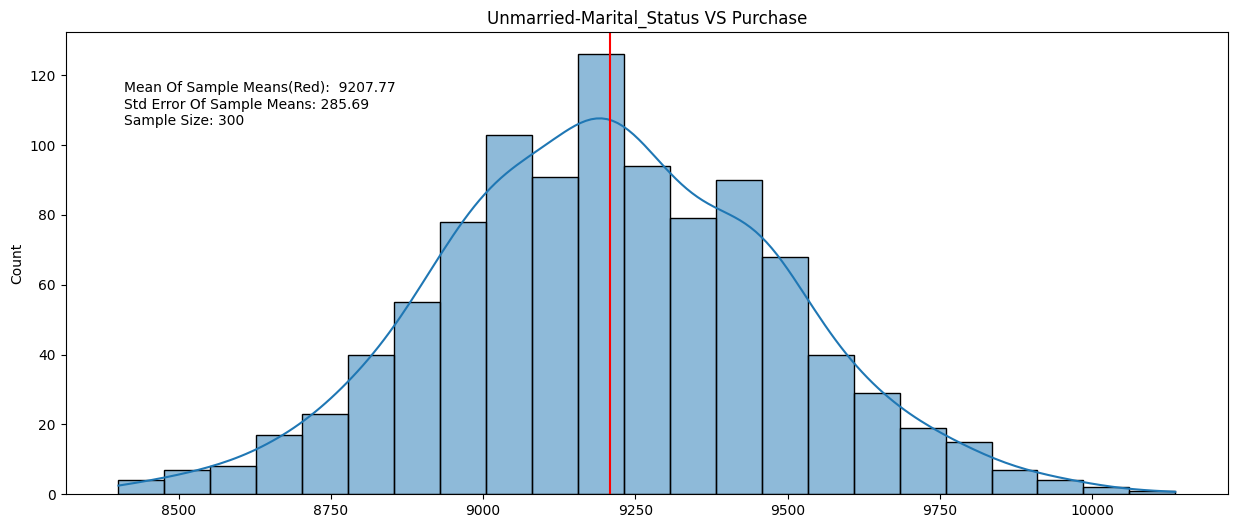

In [81]:
plt.figure(figsize=(15,6))
plt.title('Unmarried-Marital_Status VS Purchase')
sns.histplot(Unmarried_sample_mean_300, kde= True, fill= True)
plt.axvline(x= np.mean(Unmarried_sample_mean_300), color='r')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(Unmarried_sample_mean_300) : .2f} \nStd Error Of Sample Means: {np.round(se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
plt.show()

In [82]:
Unmarried_lower_bound= mean + (norm.ppf(0.025) * se)
Unmarried_upper_bound= mean + (norm.ppf(0.975) * se)
print('95% Confidence Interval For The Average Amount Spent By Unmarried For Sample Size 300:', (Unmarried_lower_bound, Unmarried_upper_bound))

95% Confidence Interval For The Average Amount Spent By Unmarried For Sample Size 300: (8647.825380949702, 9767.7167190503)


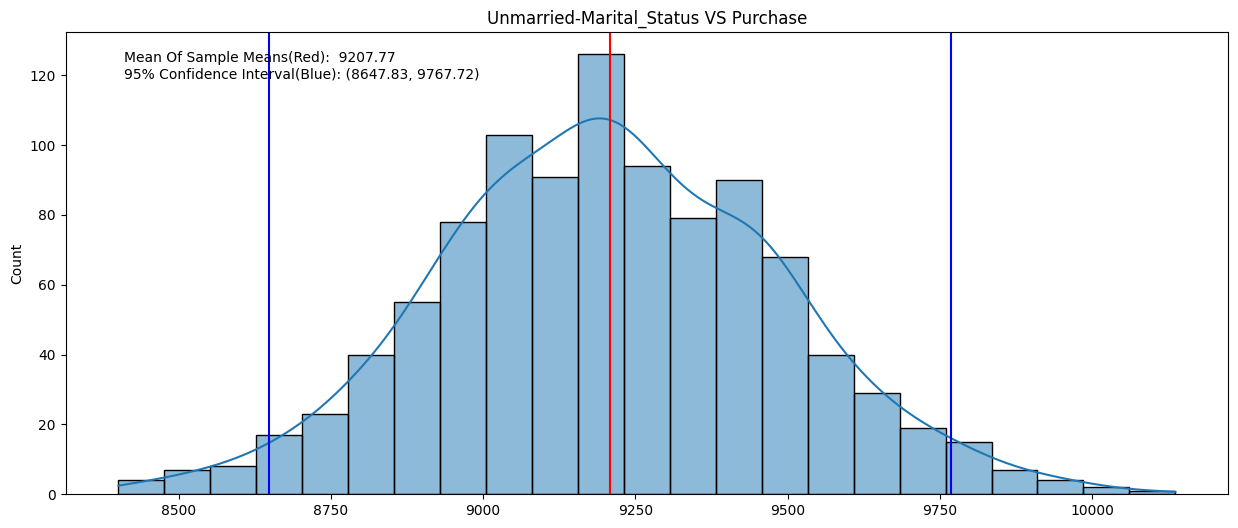

In [83]:
plt.figure(figsize=(15,6))
plt.title('Unmarried-Marital_Status VS Purchase')
sns.histplot(Unmarried_sample_mean_300, kde= True, fill= True)
plt.axvline(x= np.mean(Unmarried_sample_mean_300), color='r')
plt.axvline(x= Unmarried_lower_bound, color='b')
plt.axvline(x= Unmarried_upper_bound, color='b')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(Unmarried_sample_mean_300) : .2f} \n95% Confidence Interval(Blue): {(np.round(Unmarried_lower_bound, 2), np.round(Unmarried_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
plt.show()

**95% Confidence Interval For The Average Amount Spent By Married.**

**Sample Size: 300**

In [84]:
sample_size= 300
Marital_Status= 'Married'
Married_sample_mean_300= [np.mean(data.loc[data['Marital_Status']== Marital_Status, 'Purchase'].sample(sample_size, replace= True)) for i in range(1000)]
mean= np.mean(Married_sample_mean_300)
se= data.loc[data['Marital_Status']== Marital_Status, 'Purchase'].std()/np.sqrt(sample_size)

In [85]:
print('Married Purchase Amount- Mean Of Sample Means:', mean)
print('Married Purchase Amount- Std Error Of Sample Means:', se)

Married Purchase Amount- Mean Of Sample Means: 9198.448666666667
Married Purchase Amount- Std Error Of Sample Means: 284.3568566423484


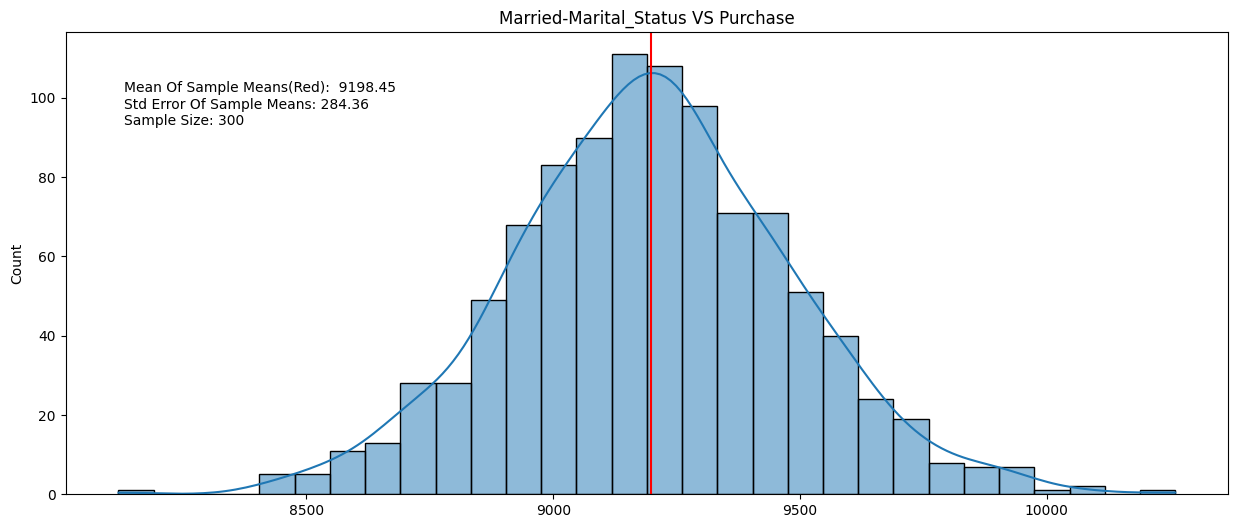

In [86]:
plt.figure(figsize=(15,6))
plt.title('Married-Marital_Status VS Purchase')
sns.histplot(Married_sample_mean_300, kde= True, fill= True)
plt.axvline(x= np.mean(Married_sample_mean_300), color='r')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(Married_sample_mean_300) : .2f} \nStd Error Of Sample Means: {np.round(se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
plt.show()

In [87]:
Married_lower_bound= mean + (norm.ppf(0.025) * se)
Married_upper_bound= mean + (norm.ppf(0.975) * se)
print('95% Confidence Interval For The Average Amount Spent By Married For Sample Size 300:', (Married_lower_bound, Married_upper_bound))

95% Confidence Interval For The Average Amount Spent By Married For Sample Size 300: (8641.119468890645, 9755.777864442689)


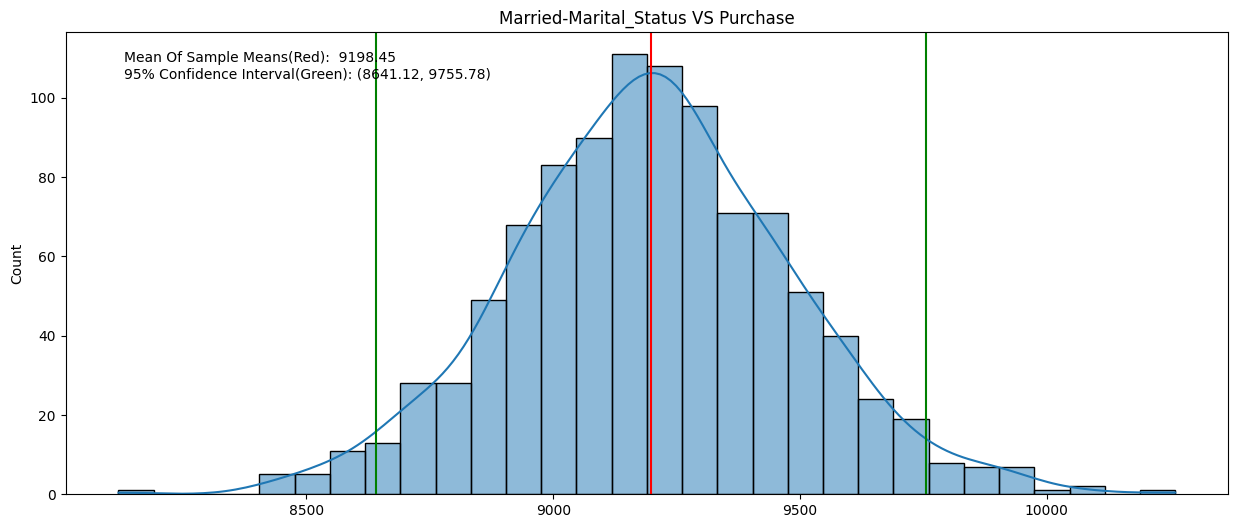

In [88]:
plt.figure(figsize=(15,6))
plt.title('Married-Marital_Status VS Purchase')
sns.histplot(Married_sample_mean_300, kde= True, fill= True)
plt.axvline(x= np.mean(Married_sample_mean_300), color='r')
plt.axvline(x= Married_lower_bound, color='g')
plt.axvline(x= Married_upper_bound, color='g')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(Married_sample_mean_300) : .2f} \n95% Confidence Interval(Green): {(np.round(Married_lower_bound, 2), np.round(Married_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
plt.show()

**Overlapping ?**

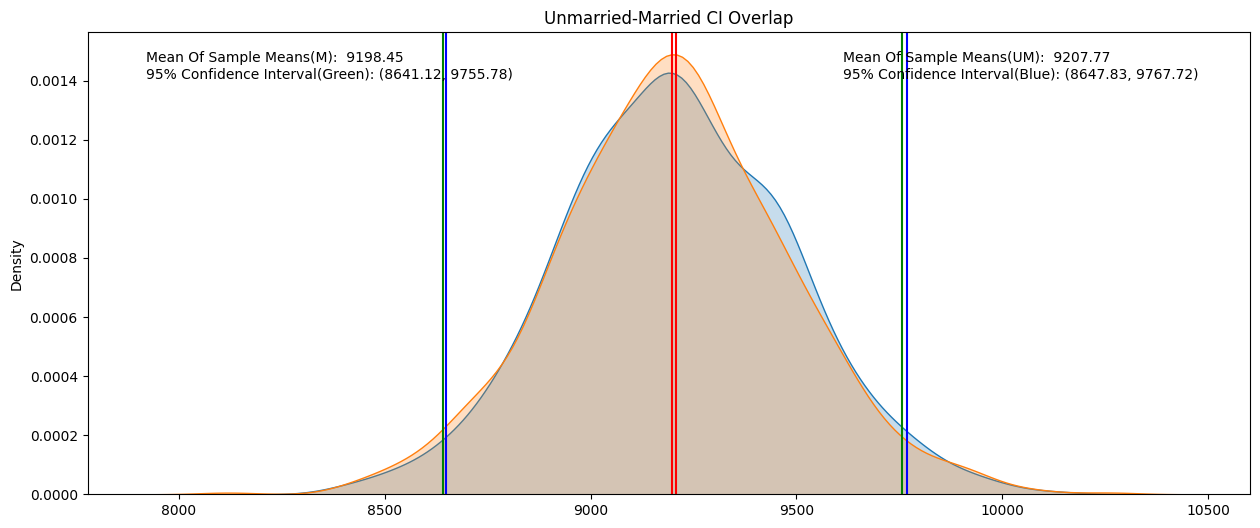

In [89]:
plt.figure(figsize=(15,6))
plt.title('Unmarried-Married CI Overlap')
sns.kdeplot(Unmarried_sample_mean_300, fill= True)
sns.kdeplot(Married_sample_mean_300, fill= True)
plt.axvline(x= np.mean(Unmarried_sample_mean_300), color='r')
plt.axvline(x= Unmarried_lower_bound, color='b')
plt.axvline(x= Unmarried_upper_bound, color='b')
plt.axvline(x= np.mean(Married_sample_mean_300), color='r')
plt.axvline(x= Married_lower_bound, color='g')
plt.axvline(x= Married_upper_bound, color='g')
plt.annotate(f'Mean Of Sample Means(UM): {np.mean(Unmarried_sample_mean_300) : .2f} \n95% Confidence Interval(Blue): {(np.round(Unmarried_lower_bound, 2), np.round(Unmarried_upper_bound,2))}', xy=(0.65, 0.90), xycoords='axes fraction', fontsize=10)
plt.annotate(f'Mean Of Sample Means(M): {np.mean(Married_sample_mean_300) : .2f} \n95% Confidence Interval(Green): {(np.round(Married_lower_bound, 2), np.round(Married_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)

plt.show()

**95% Confidence Interval For The Average Amount Spent By Unmarried.**

**Sample Size: 3000**

In [90]:
sample_size= 3000
Marital_Status= 'Unmarried'
Unmarried_sample_mean_3000= [np.mean(data.loc[data['Marital_Status']== Marital_Status, 'Purchase'].sample(sample_size, replace= True)) for i in range(1000)]
mean= np.mean(Unmarried_sample_mean_3000)
se= data.loc[data['Marital_Status']== Marital_Status, 'Purchase'].std()/np.sqrt(sample_size)

In [91]:
print('Unmarried Purchase Amount- Mean Of Sample Means:', mean)
print('Unmarried Purchase Amount- Std Error Of Sample Means:', se)

Unmarried Purchase Amount- Mean Of Sample Means: 9202.745216666668
Unmarried Purchase Amount- Std Error Of Sample Means: 90.34368458363933


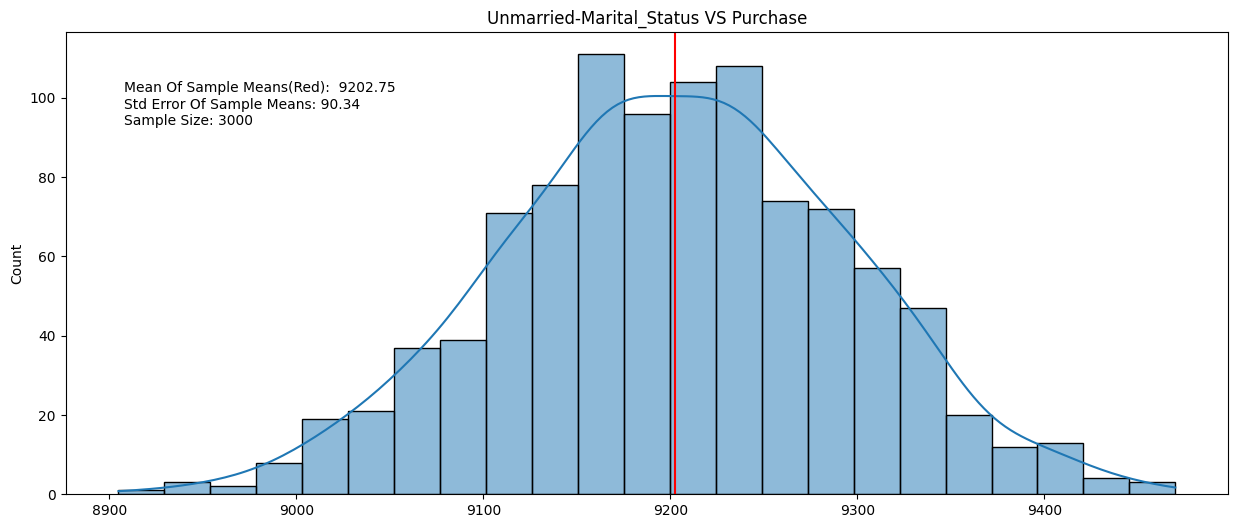

In [92]:
plt.figure(figsize=(15,6))
plt.title('Unmarried-Marital_Status VS Purchase')
sns.histplot(Unmarried_sample_mean_3000, kde= True, fill= True)
plt.axvline(x= np.mean(Unmarried_sample_mean_3000), color='r')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(Unmarried_sample_mean_3000) : .2f} \nStd Error Of Sample Means: {np.round(se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
plt.show()

In [93]:
Unmarried_lower_bound= mean + (norm.ppf(0.025) * se)
Unmarried_upper_bound= mean + (norm.ppf(0.975) * se)
print('95% Confidence Interval For The Average Amount Spent By Unmarried For Sample Size 30000:', (Unmarried_lower_bound, Unmarried_upper_bound))

95% Confidence Interval For The Average Amount Spent By Unmarried For Sample Size 30000: (9025.674848652088, 9379.815584681248)


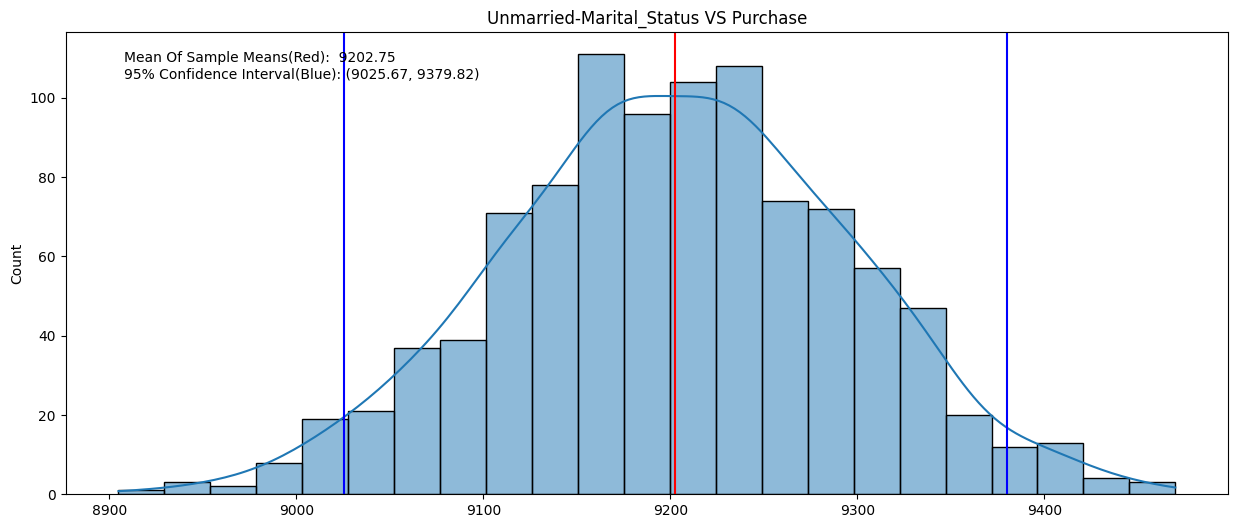

In [94]:
plt.figure(figsize=(15,6))
plt.title('Unmarried-Marital_Status VS Purchase')
sns.histplot(Unmarried_sample_mean_3000, kde= True, fill= True)
plt.axvline(x= np.mean(Unmarried_sample_mean_3000), color='r')
plt.axvline(x= Unmarried_lower_bound, color='b')
plt.axvline(x= Unmarried_upper_bound, color='b')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(Unmarried_sample_mean_3000) : .2f} \n95% Confidence Interval(Blue): {(np.round(Unmarried_lower_bound, 2), np.round(Unmarried_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
plt.show()

**95% Confidence Interval For The Average Amount Spent By Married.**

**Sample Size: 3000**

In [95]:
sample_size= 3000
Marital_Status= 'Married'
Married_sample_mean_3000= [np.mean(data.loc[data['Marital_Status']== Marital_Status, 'Purchase'].sample(sample_size, replace= True)) for i in range(1000)]
mean= np.mean(Married_sample_mean_3000)
se= data.loc[data['Marital_Status']== Marital_Status, 'Purchase'].std()/np.sqrt(sample_size)

In [96]:
print('Married Purchase Amount- Mean Of Sample Means:', mean)
print('Married Purchase Amount- Std Error Of Sample Means:', se)

Married Purchase Amount- Mean Of Sample Means: 9182.594456666668
Married Purchase Amount- Std Error Of Sample Means: 89.92153352758008


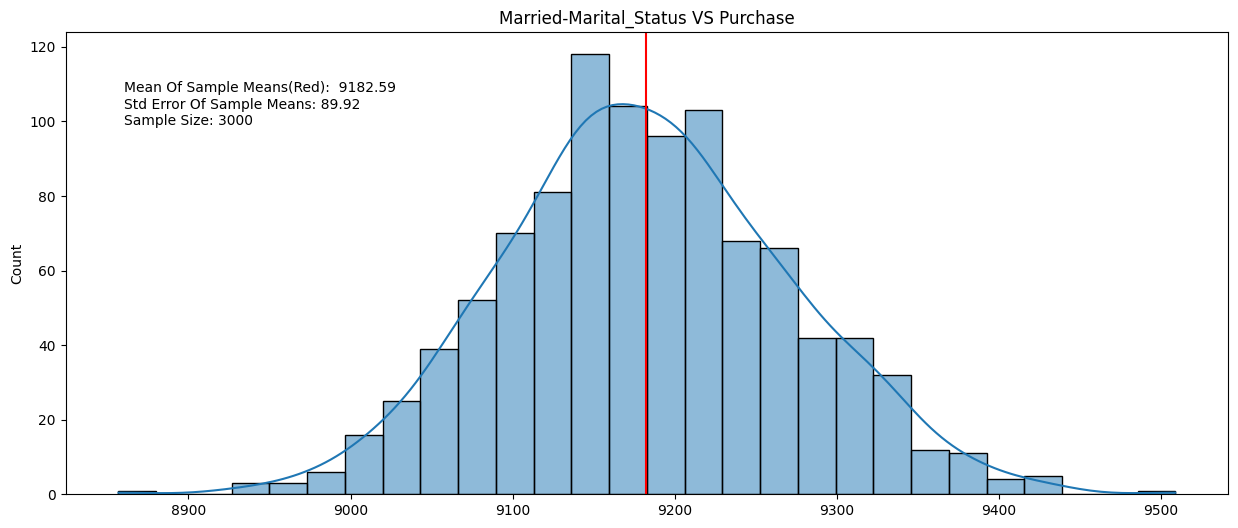

In [97]:
plt.figure(figsize=(15,6))
plt.title('Married-Marital_Status VS Purchase')
sns.histplot(Married_sample_mean_3000, kde= True, fill= True)
plt.axvline(x= np.mean(Married_sample_mean_3000), color='r')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(Married_sample_mean_3000) : .2f} \nStd Error Of Sample Means: {np.round(se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
plt.show()

In [98]:
Married_lower_bound= mean + (norm.ppf(0.025) * se)
Married_upper_bound= mean + (norm.ppf(0.975) * se)
print('95% Confidence Interval For The Average Amount Spent By Married For Sample Size 3000:', (Married_lower_bound, Married_upper_bound))

95% Confidence Interval For The Average Amount Spent By Married For Sample Size 3000: (9006.351489518, 9358.837423815336)


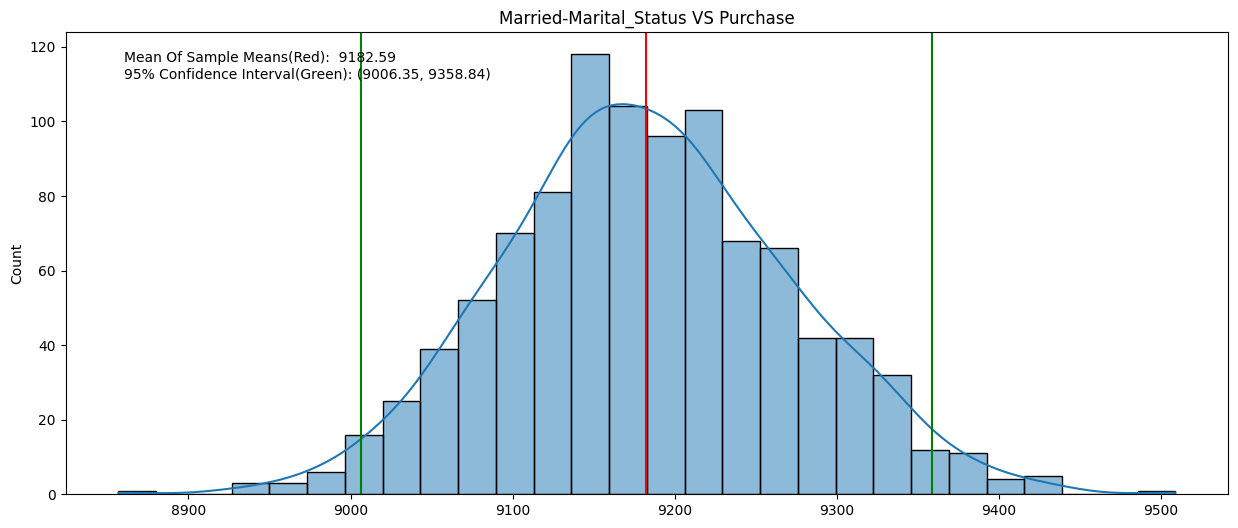

In [99]:
plt.figure(figsize=(15,6))
plt.title('Married-Marital_Status VS Purchase')
sns.histplot(Married_sample_mean_3000, kde= True, fill= True)
plt.axvline(x= np.mean(Married_sample_mean_3000), color='r')
plt.axvline(x= Married_lower_bound, color='g')
plt.axvline(x= Married_upper_bound, color='g')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(Married_sample_mean_3000) : .2f} \n95% Confidence Interval(Green): {(np.round(Married_lower_bound, 2), np.round(Married_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
plt.show()

**Overlapping ?**

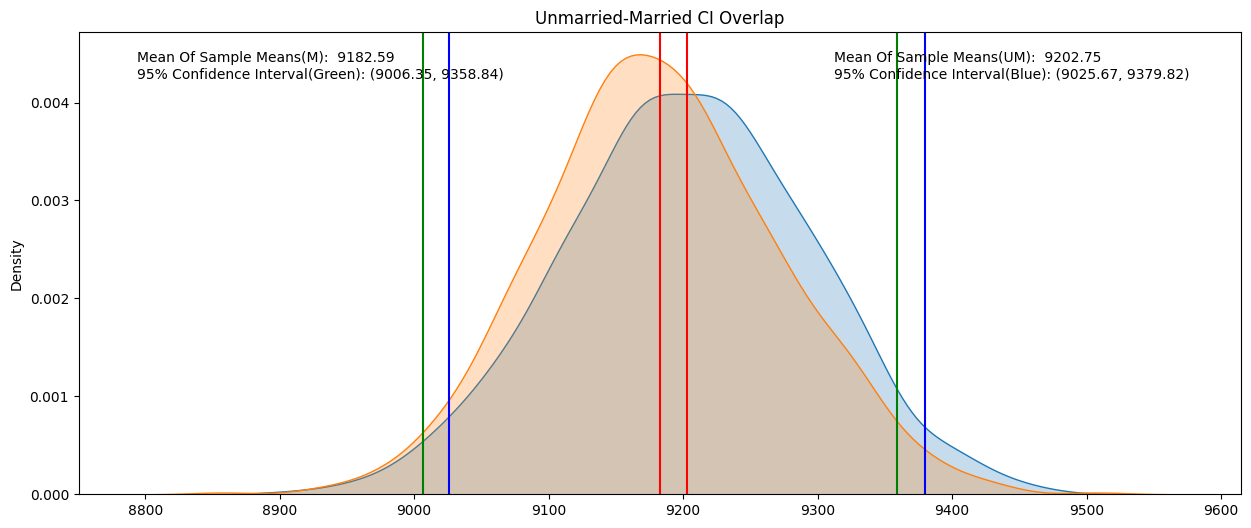

In [100]:
plt.figure(figsize=(15,6))
plt.title('Unmarried-Married CI Overlap')
sns.kdeplot(Unmarried_sample_mean_3000, fill= True)
sns.kdeplot(Married_sample_mean_3000, fill= True)
plt.axvline(x= np.mean(Unmarried_sample_mean_3000), color='r')
plt.axvline(x= Unmarried_lower_bound, color='b')
plt.axvline(x= Unmarried_upper_bound, color='b')
plt.axvline(x= np.mean(Married_sample_mean_3000), color='r')
plt.axvline(x= Married_lower_bound, color='g')
plt.axvline(x= Married_upper_bound, color='g')
plt.annotate(f'Mean Of Sample Means(UM): {np.mean(Unmarried_sample_mean_3000) : .2f} \n95% Confidence Interval(Blue): {(np.round(Unmarried_lower_bound, 2), np.round(Unmarried_upper_bound,2))}', xy=(0.65, 0.90), xycoords='axes fraction', fontsize=10)
plt.annotate(f'Mean Of Sample Means(M): {np.mean(Married_sample_mean_3000) : .2f} \n95% Confidence Interval(Green): {(np.round(Married_lower_bound, 2), np.round(Married_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)

plt.show()

**95% Confidence Interval For The Average Amount Spent By Unmarried.**

**Sample Size: 30000**

In [101]:
sample_size= 30000
Marital_Status= 'Unmarried'
Unmarried_sample_mean_30000= [np.mean(data.loc[data['Marital_Status']== Marital_Status, 'Purchase'].sample(sample_size, replace= True)) for i in range(1000)]
mean= np.mean(Unmarried_sample_mean_30000)
se= data.loc[data['Marital_Status']== Marital_Status, 'Purchase'].std()/np.sqrt(sample_size)

In [102]:
print('Unmarried Purchase Amount- Mean Of Sample Means:', mean)
print('Unmarried Purchase Amount- Std Error Of Sample Means:', se)

Unmarried Purchase Amount- Mean Of Sample Means: 9200.942880766668
Unmarried Purchase Amount- Std Error Of Sample Means: 28.569181549614107


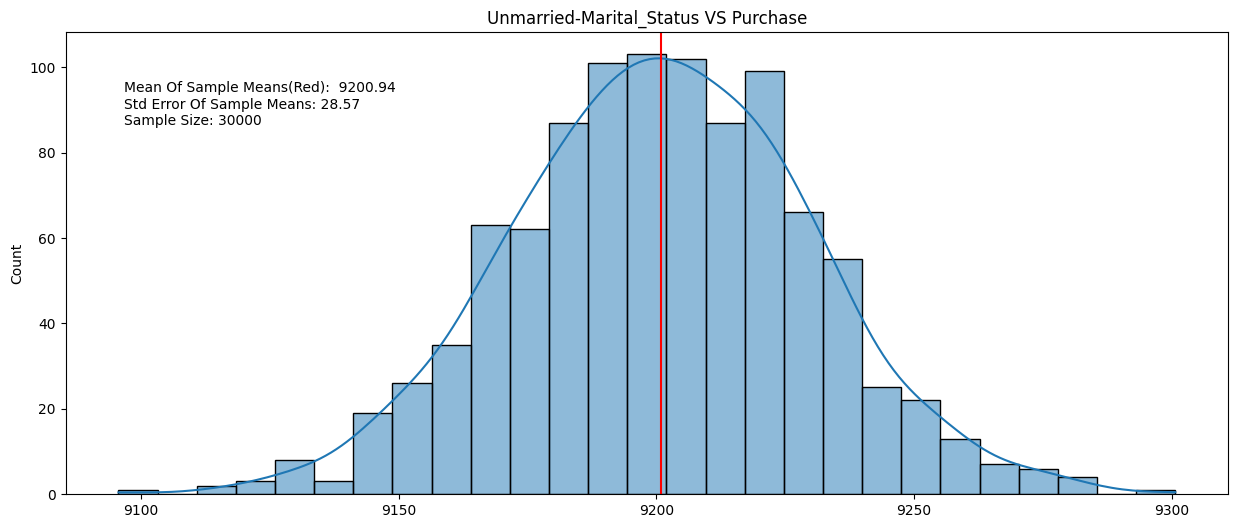

In [103]:
plt.figure(figsize=(15,6))
plt.title('Unmarried-Marital_Status VS Purchase')
sns.histplot(Unmarried_sample_mean_30000, kde= True, fill= True)
plt.axvline(x= np.mean(Unmarried_sample_mean_30000), color='r')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(Unmarried_sample_mean_30000) : .2f} \nStd Error Of Sample Means: {np.round(se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
plt.show()

In [104]:
Unmarried_lower_bound= mean + (norm.ppf(0.025) * se)
Unmarried_upper_bound= mean + (norm.ppf(0.975) * se)
print('95% Confidence Interval For The Average Amount Spent By Unmarried For Sample Size 300000:', (Unmarried_lower_bound, Unmarried_upper_bound))

95% Confidence Interval For The Average Amount Spent By Unmarried For Sample Size 300000: (9144.948313861638, 9256.937447671698)


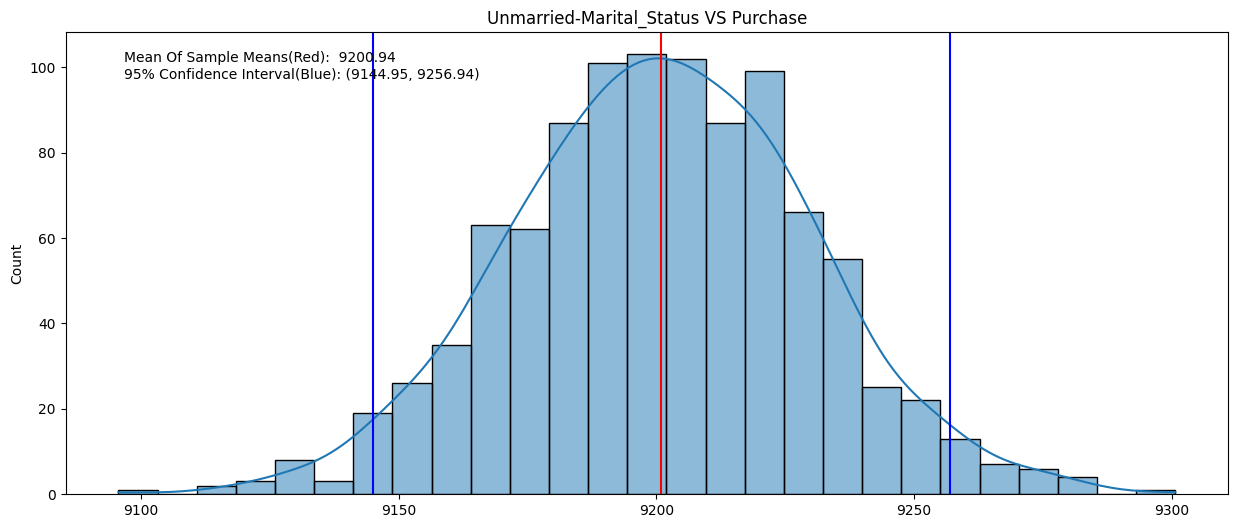

In [105]:
plt.figure(figsize=(15,6))
plt.title('Unmarried-Marital_Status VS Purchase')
sns.histplot(Unmarried_sample_mean_30000, kde= True, fill= True)
plt.axvline(x= np.mean(Unmarried_sample_mean_30000), color='r')
plt.axvline(x= Unmarried_lower_bound, color='b')
plt.axvline(x= Unmarried_upper_bound, color='b')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(Unmarried_sample_mean_30000) : .2f} \n95% Confidence Interval(Blue): {(np.round(Unmarried_lower_bound, 2), np.round(Unmarried_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
plt.show()

**95% Confidence Interval For The Average Amount Spent By Married.**

**Sample Size: 30000**

In [106]:
sample_size= 30000
Marital_Status= 'Married'
Married_sample_mean_30000= [np.mean(data.loc[data['Marital_Status']== Marital_Status, 'Purchase'].sample(sample_size, replace= True)) for i in range(1000)]
mean= np.mean(Married_sample_mean_30000)
se= data.loc[data['Marital_Status']== Marital_Status, 'Purchase'].std()/np.sqrt(sample_size)

In [107]:
print('Married Purchase Amount- Mean Of Sample Means:', mean)
print('Married Purchase Amount- Std Error Of Sample Means:', se)

Married Purchase Amount- Mean Of Sample Means: 9186.138642366666
Married Purchase Amount- Std Error Of Sample Means: 28.435685664234843


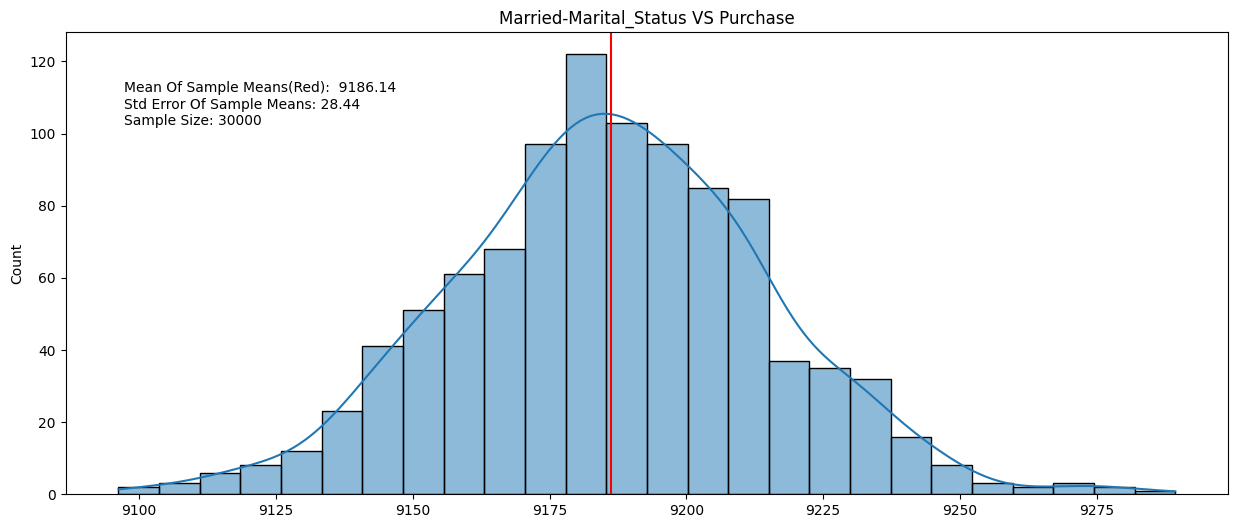

In [108]:
plt.figure(figsize=(15,6))
plt.title('Married-Marital_Status VS Purchase')
sns.histplot(Married_sample_mean_30000, kde= True, fill= True)
plt.axvline(x= np.mean(Married_sample_mean_30000), color='r')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(Married_sample_mean_30000) : .2f} \nStd Error Of Sample Means: {np.round(se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
plt.show()

In [109]:
Married_lower_bound= mean + (norm.ppf(0.025) * se)
Married_upper_bound= mean + (norm.ppf(0.975) * se)
print('95% Confidence Interval For The Average Amount Spent By Married For Sample Size 30000:', (Married_lower_bound, Married_upper_bound))

95% Confidence Interval For The Average Amount Spent By Married For Sample Size 30000: (9130.405722589065, 9241.871562144268)


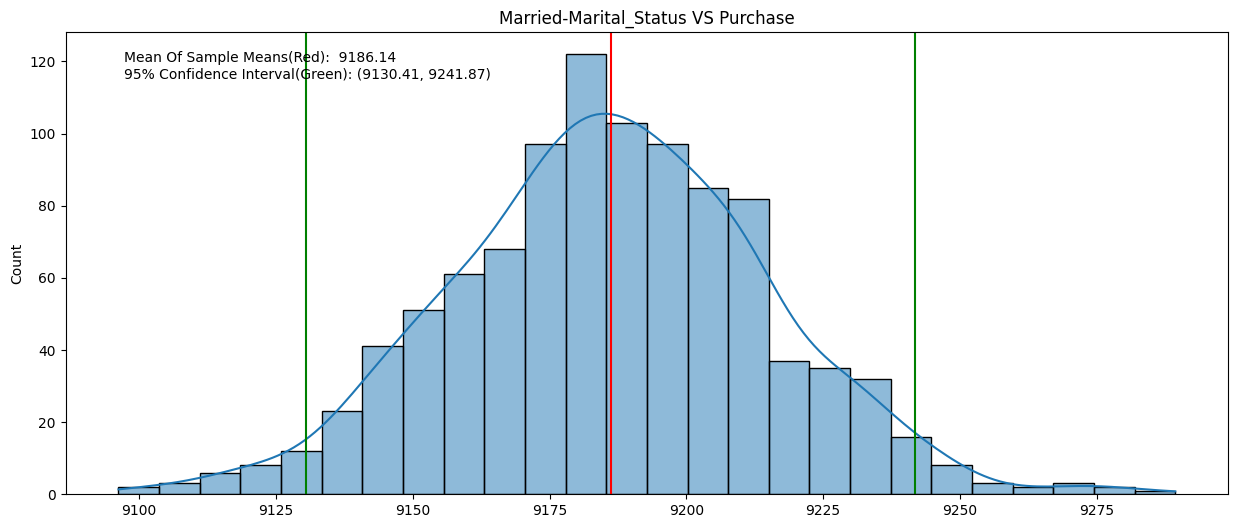

In [110]:
plt.figure(figsize=(15,6))
plt.title('Married-Marital_Status VS Purchase')
sns.histplot(Married_sample_mean_30000, kde= True, fill= True)
plt.axvline(x= np.mean(Married_sample_mean_30000), color='r')
plt.axvline(x= Married_lower_bound, color='g')
plt.axvline(x= Married_upper_bound, color='g')
plt.annotate(f'Mean Of Sample Means(Red): {np.mean(Married_sample_mean_30000) : .2f} \n95% Confidence Interval(Green): {(np.round(Married_lower_bound, 2), np.round(Married_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)
plt.show()

**Overlapping ?**

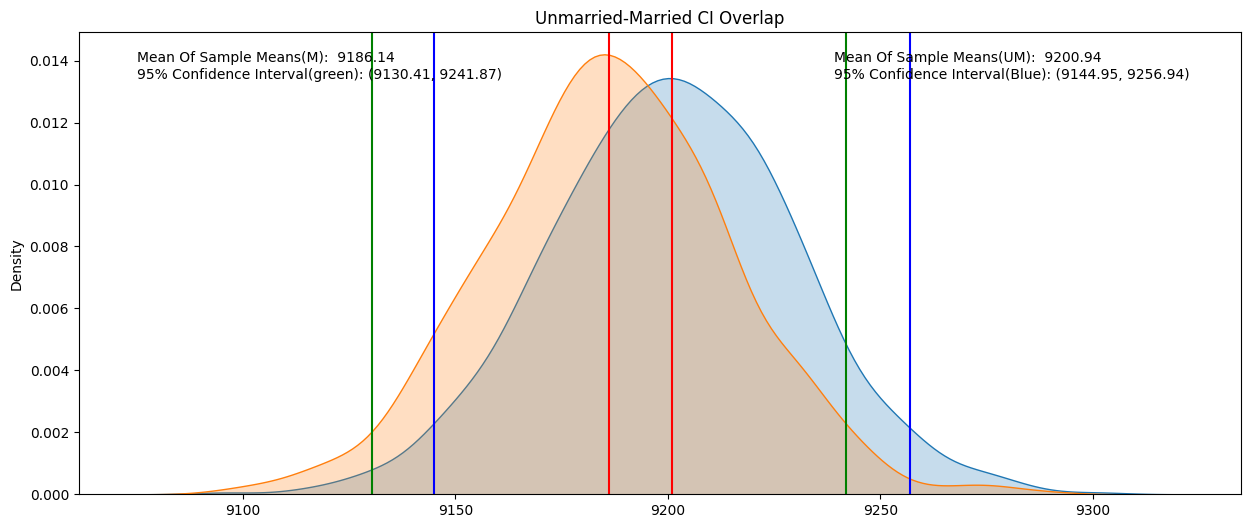

In [111]:
plt.figure(figsize=(15,6))
plt.title('Unmarried-Married CI Overlap')
sns.kdeplot(Unmarried_sample_mean_30000, fill= True)
sns.kdeplot(Married_sample_mean_30000, fill= True)
plt.axvline(x= np.mean(Unmarried_sample_mean_30000), color='r')
plt.axvline(x= Unmarried_lower_bound, color='b')
plt.axvline(x= Unmarried_upper_bound, color='b')
plt.axvline(x= np.mean(Married_sample_mean_30000), color='r')
plt.axvline(x= Married_lower_bound, color='g')
plt.axvline(x= Married_upper_bound, color='g')
plt.annotate(f'Mean Of Sample Means(UM): {np.mean(Unmarried_sample_mean_30000) : .2f} \n95% Confidence Interval(Blue): {(np.round(Unmarried_lower_bound, 2), np.round(Unmarried_upper_bound,2))}', xy=(0.65, 0.90), xycoords='axes fraction', fontsize=10)
plt.annotate(f'Mean Of Sample Means(M): {np.mean(Married_sample_mean_30000) : .2f} \n95% Confidence Interval(green): {(np.round(Married_lower_bound, 2), np.round(Married_upper_bound,2))}', xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10)

plt.show()

**Conclusion: Unmarried and married individuals spend nearly the same amount, with negligible differences in their average spending patterns. Confidence intervals consistently overlap, even as sample size increases, confirming no significant distinction between the groups.**

# **6. How does Age affect the amount spent?**
**Hint: Use the central limit theorem or bootstrapping to compute the 95% confidence intervals for the average amount spent per Age Cat. First, compute the confidence interval for whatever data is available, and then repeat the same with smaller sample sizes - 300, 3000, and 30000.**

In [112]:
data.groupby('Age')['Purchase'].describe()

<ipython-input-112-864c5c92db2c>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Age')['Purchase'].describe()


,count,mean,std,min,25%,50%,75%,max
Age,,,,,,,,
0-17,15032.0,8867.447046,5030.052846,12.0,5324.0,7974.5,11833.25,21342.0
18-25,99334.0,9124.031731,4978.831062,12.0,5412.0,8020.0,12004.00,21398.0
26-35,218661.0,9193.469924,4937.410901,12.0,5471.0,8021.0,12018.00,21398.0
36-45,109409.0,9254.202214,4927.744433,12.0,5866.0,8051.0,12065.00,21399.0
46-50,45442.0,9128.985080,4867.413951,12.0,5879.0,8025.0,11958.00,21391.0
51-55,38191.0,9423.121704,4953.644650,12.0,6007.0,8118.0,12123.00,21388.0
55+,21322.0,9216.650220,4861.626596,12.0,6007.0,8092.5,11837.75,21345.0


Text(0.5, 1.0, 'Age VS Purchase')

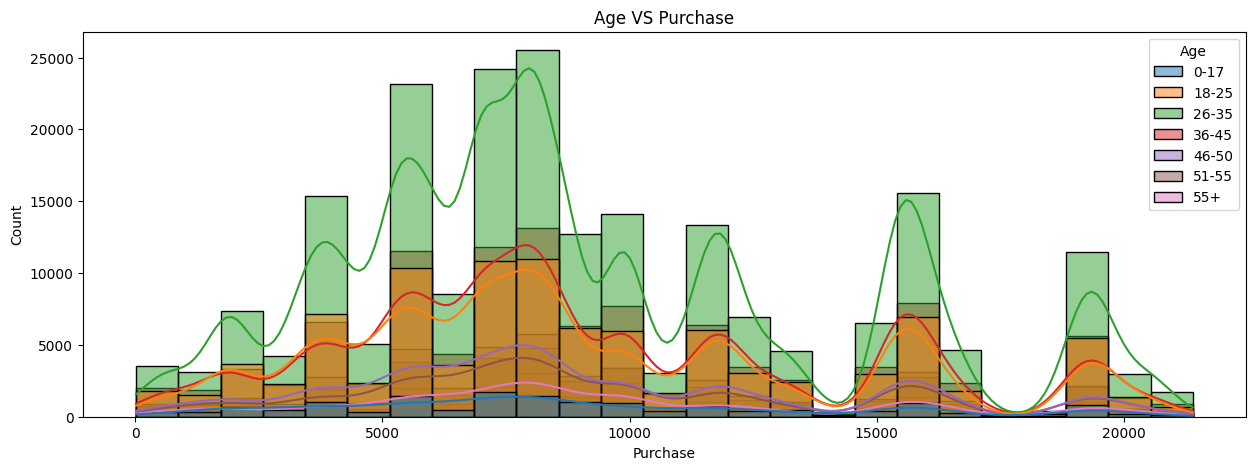

In [113]:
plt.figure(figsize=(15,5))
sns.histplot(data, bins=25, x= 'Purchase', hue= 'Age', fill= True, kde= True)
plt.title('Age VS Purchase')

**95% Confidence Interval For The Average Amount Spent By Age Category.**

**Sample Size: 300**

In [114]:
sample_size= 300
age_cat= ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

In [115]:
age_sample_means={}
age_means={}
age_se={}
for i in age_cat:
    age_sample_means[f'{i}_sample_mean_{sample_size}'] = [np.mean(data.loc[data['Age']== i, 'Purchase'].sample(sample_size, replace= True)) for _ in range(1000)]
    age_means[f'{i}_mean_{sample_size}'] = np.mean(age_sample_means[f'{i}_sample_mean_{sample_size}'])
    age_se[f'{i}_se_{sample_size}']= data.loc[data['Age']== i, 'Purchase'].std()/np.sqrt(sample_size)
    print(f'{i} Purchase Amount- Mean Of Sample Means:', age_means[f'{i}_mean_{sample_size}'])
    print(f'{i} Purchase Amount- Std Error Of Sample Means:', age_se[f'{i}_se_{sample_size}'])
    print('-'*100)

0-17 Purchase Amount- Mean Of Sample Means: 8858.086193333333
0-17 Purchase Amount- Std Error Of Sample Means: 290.41023646300073
----------------------------------------------------------------------------------------------------
18-25 Purchase Amount- Mean Of Sample Means: 9125.040243333335
18-25 Purchase Amount- Std Error Of Sample Means: 287.4529453833825
----------------------------------------------------------------------------------------------------
26-35 Purchase Amount- Mean Of Sample Means: 9193.225746666667
26-35 Purchase Amount- Std Error Of Sample Means: 285.06155129664086
----------------------------------------------------------------------------------------------------
36-45 Purchase Amount- Mean Of Sample Means: 9241.971393333335
36-45 Purchase Amount- Std Error Of Sample Means: 284.5034575042815
----------------------------------------------------------------------------------------------------
46-50 Purchase Amount- Mean Of Sample Means: 9129.399016666666
46-50 Pur

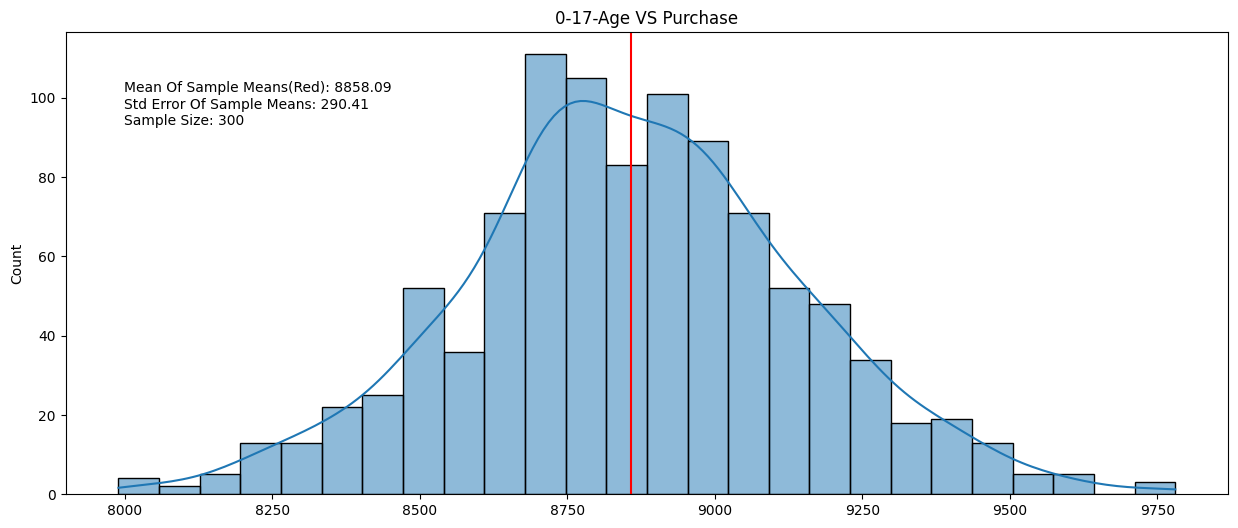

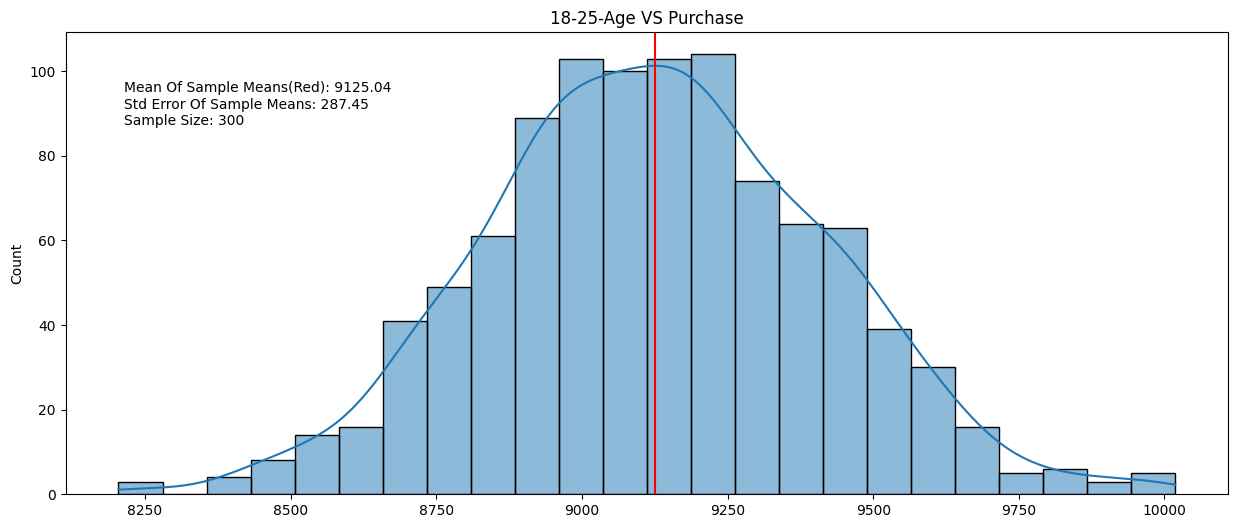

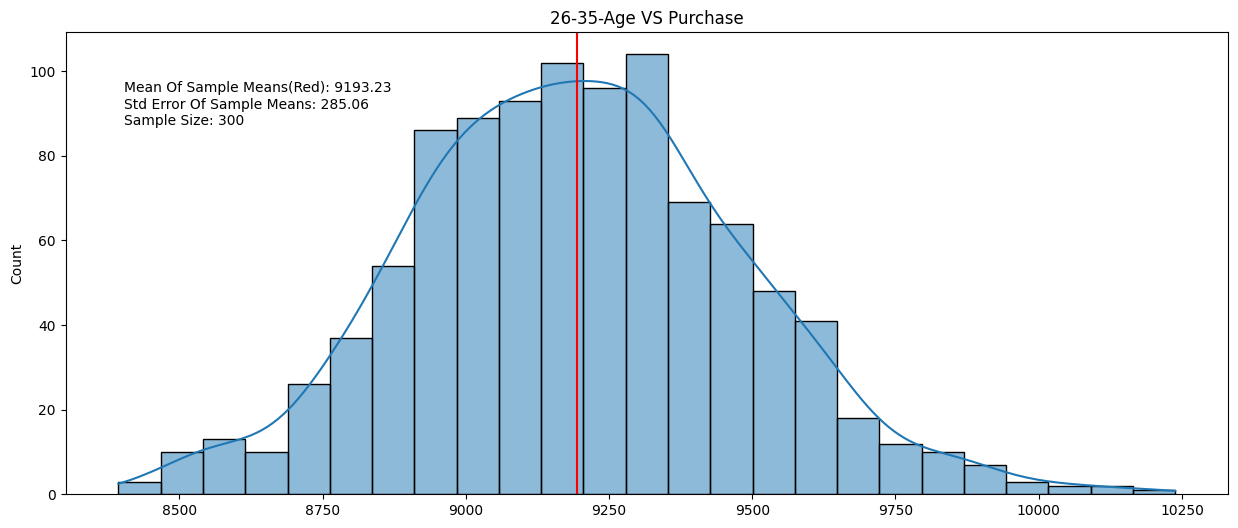

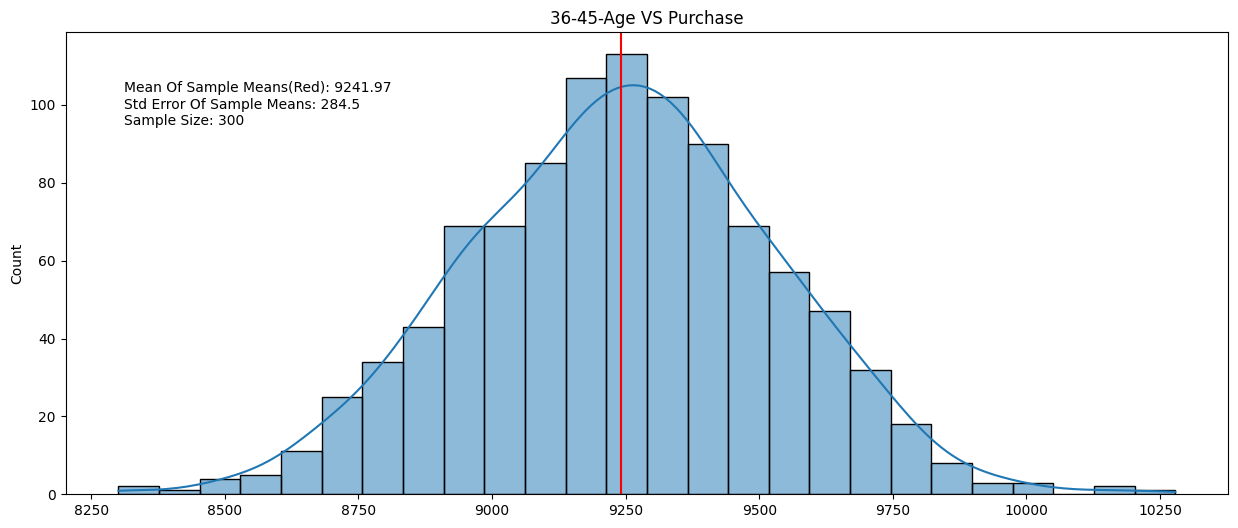

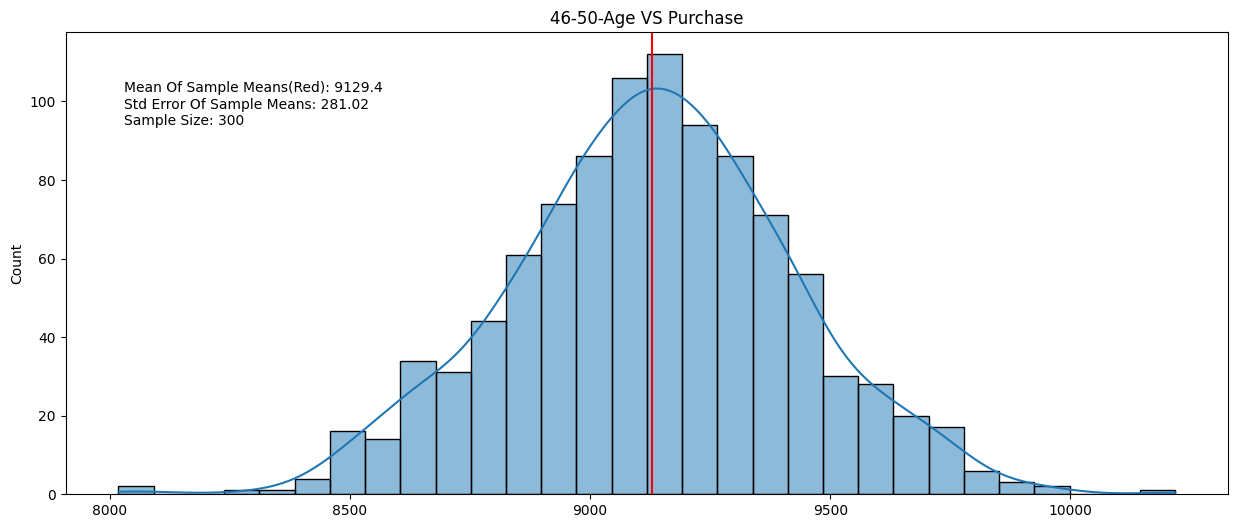

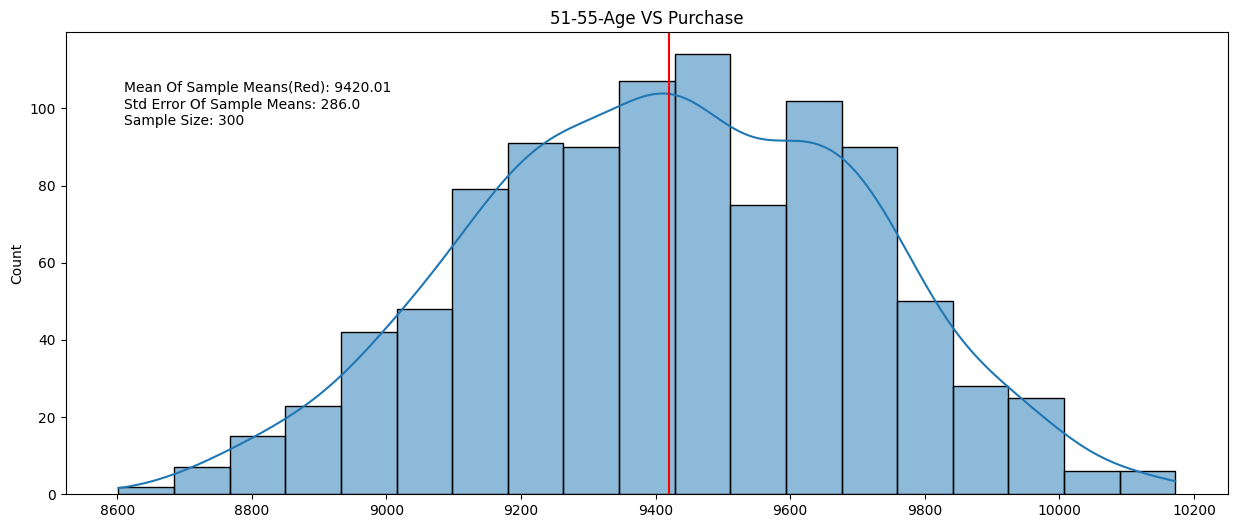

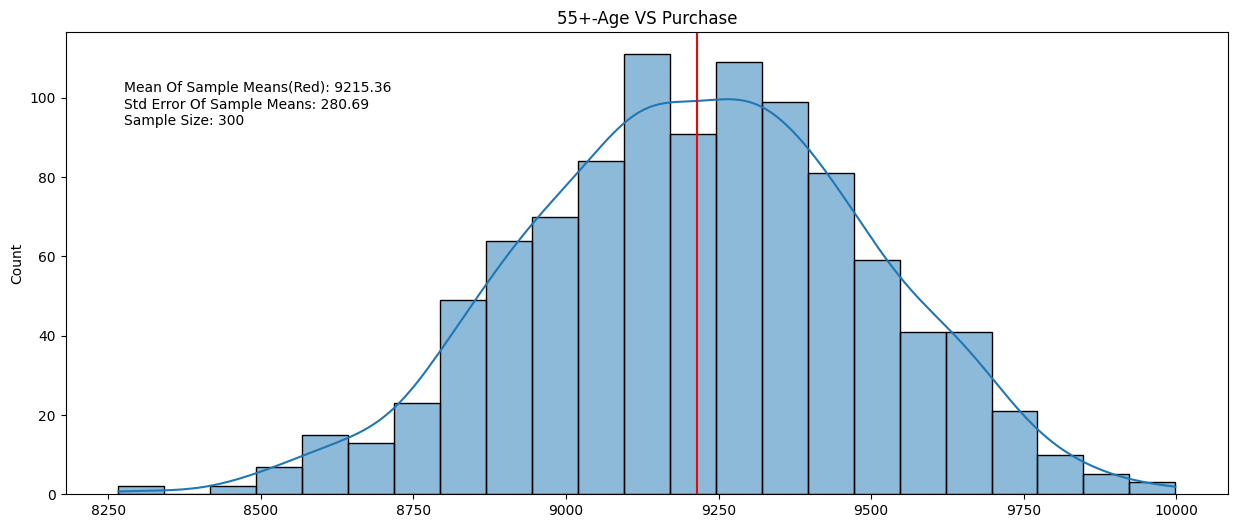

In [116]:
for i in age_cat:
    plt.figure(figsize=(15,6))
    plt.title(f'{i}-Age VS Purchase')
    sns.histplot(age_sample_means[f'{i}_sample_mean_{sample_size}'], kde= True, fill= True)
    plt.axvline(x= age_means[f'{i}_mean_{sample_size}'], color='r')
    temp_mean= age_means[f'{i}_mean_{sample_size}']
    temp_se= age_se[f'{i}_se_{sample_size}']
    plt.annotate(f'Mean Of Sample Means(Red): {np.round(temp_mean, 2)} \nStd Error Of Sample Means: {np.round(temp_se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
    plt.show()

In [117]:
age_ci={}
for i in age_cat:
    age_ci[f'{i}_lower_bound_{sample_size}'] = age_means[f'{i}_mean_{sample_size}'] + (norm.ppf(0.025) * age_se[f'{i}_se_{sample_size}'])
    age_ci[f'{i}_upper_bound_{sample_size}'] = age_means[f'{i}_mean_{sample_size}'] + (norm.ppf(0.975) * age_se[f'{i}_se_{sample_size}'])
    print(f'95% Confidence Interval For The Average Amount Spent By {i} For Sample Size {sample_size}:', (age_ci[f'{i}_lower_bound_{sample_size}'], age_ci[f'{i}_upper_bound_{sample_size}']))
    print('-'*100)

95% Confidence Interval For The Average Amount Spent By 0-17 For Sample Size 300: (8288.89258912409, 9427.279797542575)
----------------------------------------------------------------------------------------------------
95% Confidence Interval For The Average Amount Spent By 18-25 For Sample Size 300: (8561.642823131946, 9688.437663534723)
----------------------------------------------------------------------------------------------------
95% Confidence Interval For The Average Amount Spent By 26-35 For Sample Size 300: (8634.515372748134, 9751.9361205852)
----------------------------------------------------------------------------------------------------
95% Confidence Interval For The Average Amount Spent By 36-45 For Sample Size 300: (8684.35486314782, 9799.587923518848)
----------------------------------------------------------------------------------------------------
95% Confidence Interval For The Average Amount Spent By 46-50 For Sample Size 300: (8578.609397769058, 9680.18863

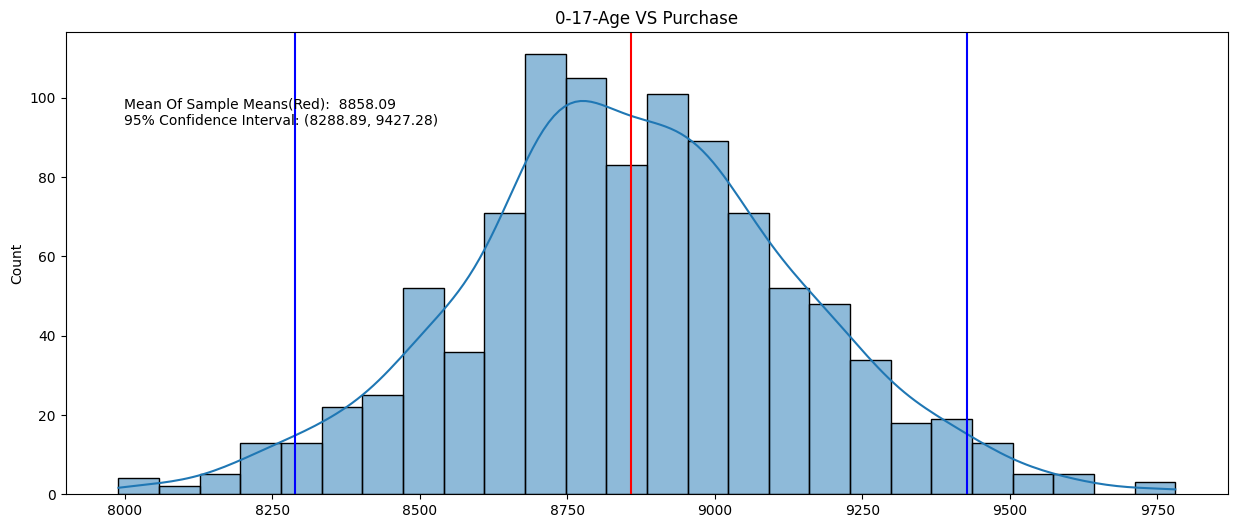

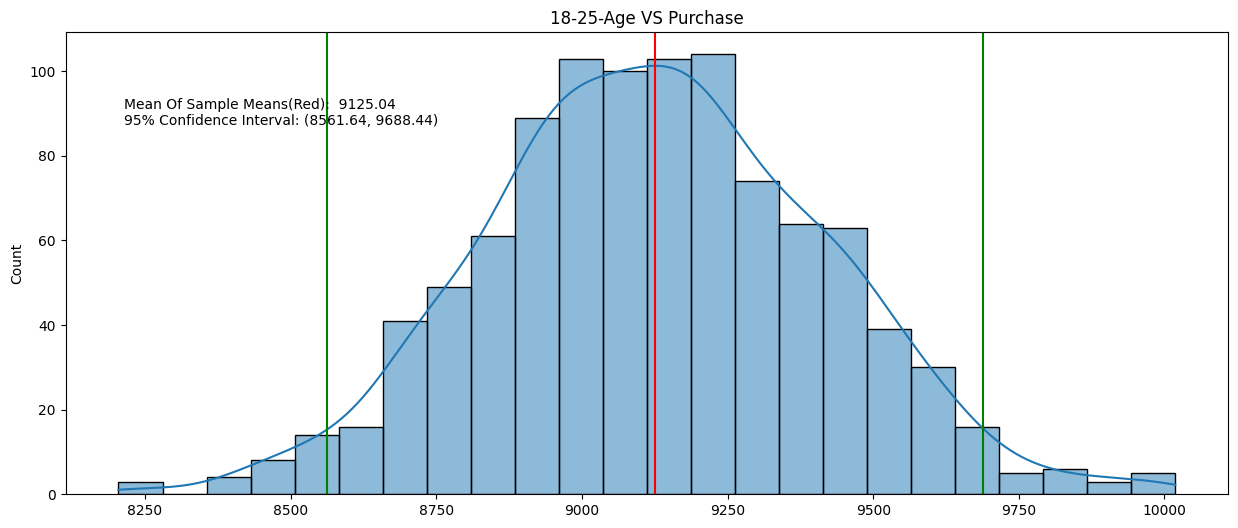

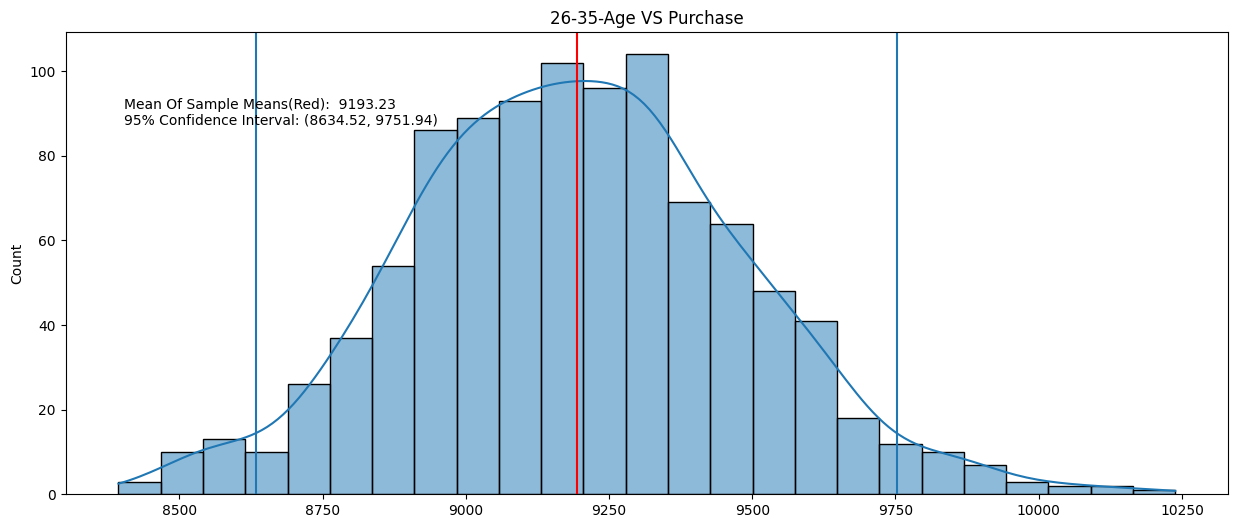

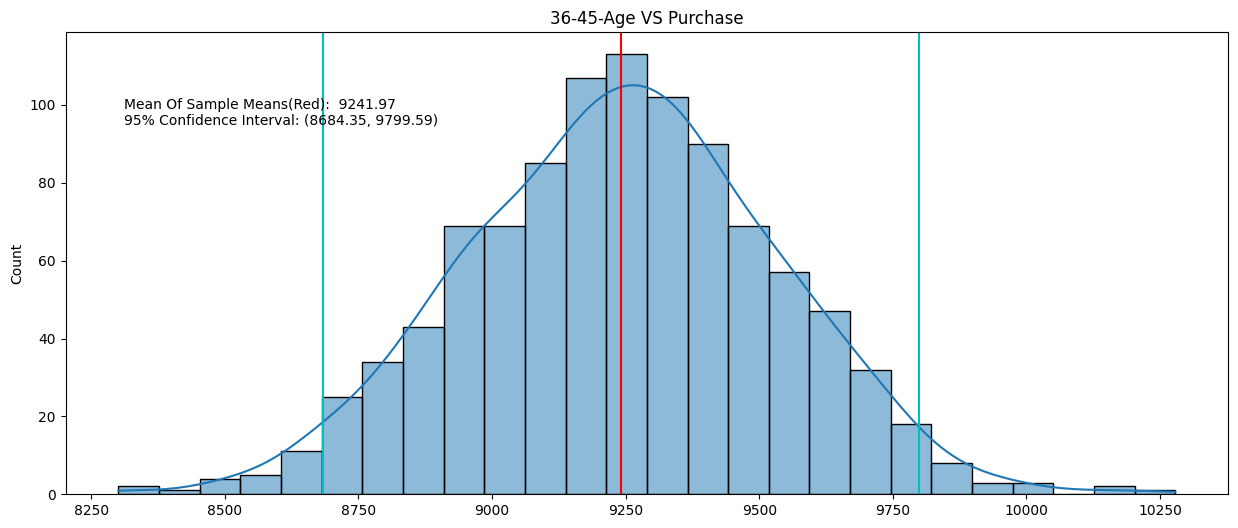

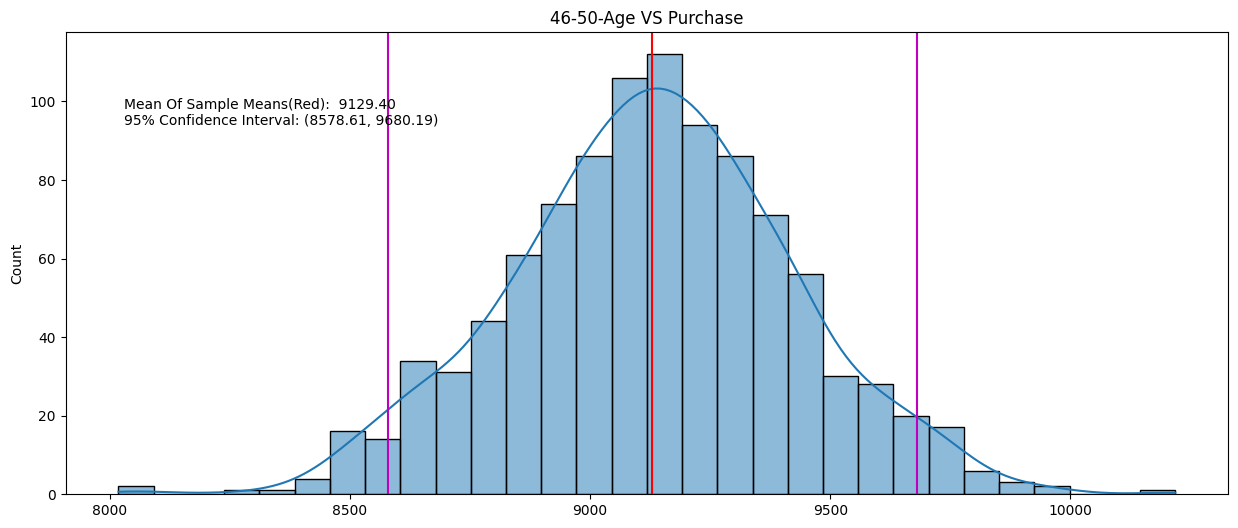

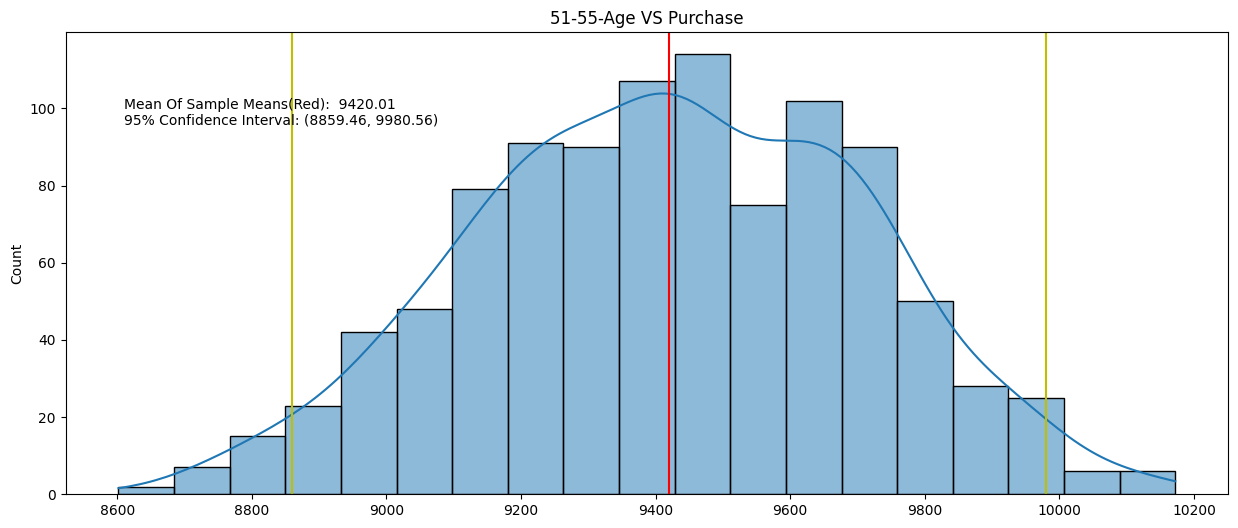

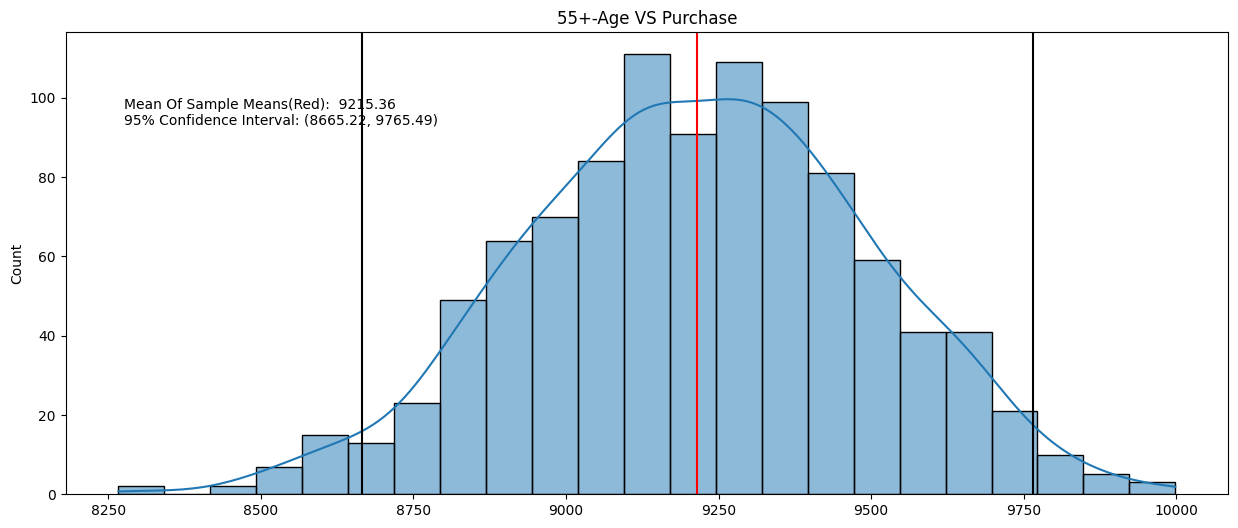

In [118]:
color= ['b', 'g', '#1f77b4', 'c', 'm', 'y', 'k']
age_se_list= list(age_se.keys())
for i in age_cat:
    plt.figure(figsize=(15,6))
    plt.title(f'{i}-Age VS Purchase')
    sns.histplot(age_sample_means[f'{i}_sample_mean_{sample_size}'], kde= True, fill= True)
    plt.axvline(x= age_means[f'{i}_mean_{sample_size}'], color='r')
    temp_mean= age_means[f'{i}_mean_{sample_size}']
    plt.axvline(x= age_ci[f'{i}_lower_bound_{sample_size}'], color=color[age_se_list.index(f'{i}_se_{sample_size}')])
    temp_low= age_ci[f'{i}_lower_bound_{sample_size}']
    plt.axvline(x= age_ci[f'{i}_upper_bound_{sample_size}'], color=color[age_se_list.index(f'{i}_se_{sample_size}')])
    temp_up= age_ci[f'{i}_upper_bound_{sample_size}']
    plt.annotate(f'Mean Of Sample Means(Red): {np.mean(temp_mean) : .2f} \n95% Confidence Interval: {(np.round(temp_low, 2), np.round(temp_up,2))}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
    plt.show()

**Overlapping ?**

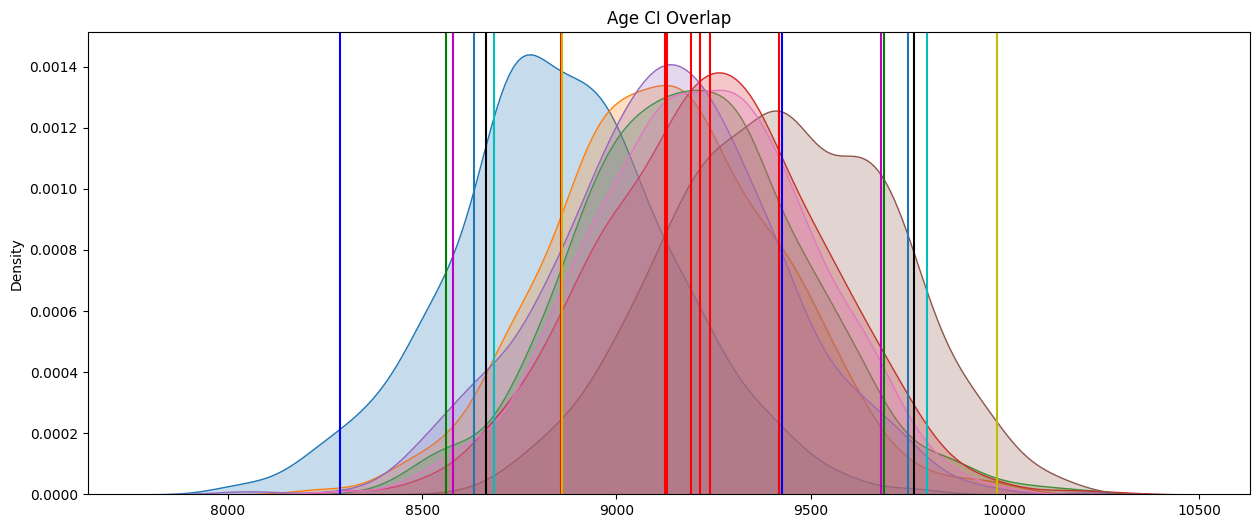

In [119]:
color= ['b', 'g', '#1f77b4', 'c', 'm', 'y', 'k']
age_se_list= list(age_se.keys())
a, b, c, d, e, f, j = age_cat
age_cat_list= [a, b, c, d, e, f, j]
plt.figure(figsize=(15,6))
plt.title('Age CI Overlap')
for i in age_cat_list:
    sns.kdeplot(age_sample_means[f'{i}_sample_mean_{sample_size}'], fill= True)
    plt.axvline(x= age_means[f'{i}_mean_{sample_size}'], color='r')
    plt.axvline(x= age_ci[f'{i}_lower_bound_{sample_size}'], color=color[age_se_list.index(f'{i}_se_{sample_size}')])
    plt.axvline(x= age_ci[f'{i}_upper_bound_{sample_size}'], color=color[age_se_list.index(f'{i}_se_{sample_size}')])
plt.show()

**95% Confidence Interval For The Average Amount Spent By Age Category..**

**Sample Size: 3000**

In [120]:
sample_size= 3000
age_cat= ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
age_sample_means={}
age_means={}
age_se={}
for i in age_cat:
    age_sample_means[f'{i}_sample_mean_{sample_size}'] = [np.mean(data.loc[data['Age']== i, 'Purchase'].sample(sample_size, replace= True)) for _ in range(1000)]
    age_means[f'{i}_mean_{sample_size}'] = np.mean(age_sample_means[f'{i}_sample_mean_{sample_size}'])
    age_se[f'{i}_se_{sample_size}']= data.loc[data['Age']== i, 'Purchase'].std()/np.sqrt(sample_size)
    print(f'{i} Purchase Amount- Mean Of Sample Means:', age_means[f'{i}_mean_{sample_size}'])
    print(f'{i} Purchase Amount- Std Error Of Sample Means:', age_se[f'{i}_se_{sample_size}'])
    print('-'*100)

0-17 Purchase Amount- Mean Of Sample Means: 8869.420445666665
0-17 Purchase Amount- Std Error Of Sample Means: 91.83578030511637
----------------------------------------------------------------------------------------------------
18-25 Purchase Amount- Mean Of Sample Means: 9122.720436000001
18-25 Purchase Amount- Std Error Of Sample Means: 90.90060275354716
----------------------------------------------------------------------------------------------------
26-35 Purchase Amount- Mean Of Sample Means: 9192.7603
26-35 Purchase Amount- Std Error Of Sample Means: 90.144377543831
----------------------------------------------------------------------------------------------------
36-45 Purchase Amount- Mean Of Sample Means: 9258.785644666668
36-45 Purchase Amount- Std Error Of Sample Means: 89.96789279064534
----------------------------------------------------------------------------------------------------
46-50 Purchase Amount- Mean Of Sample Means: 9132.901013333332
46-50 Purchase Amount

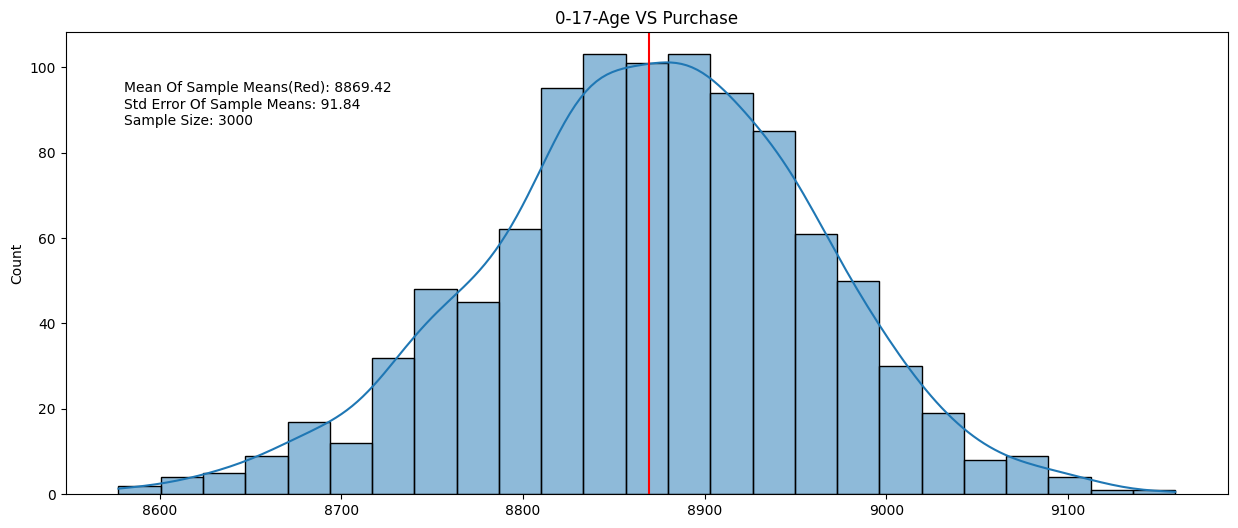

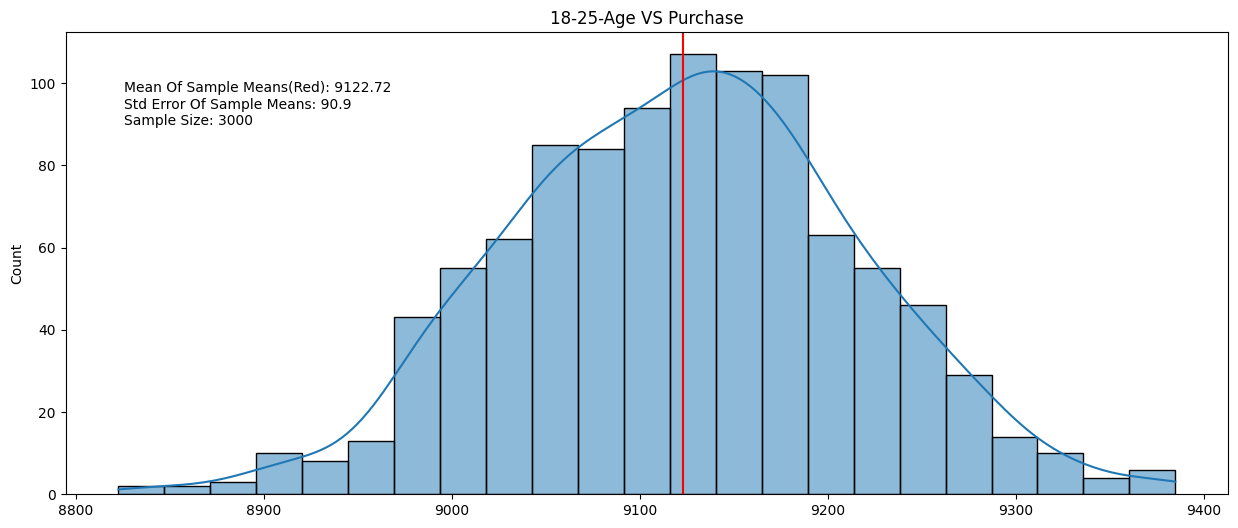

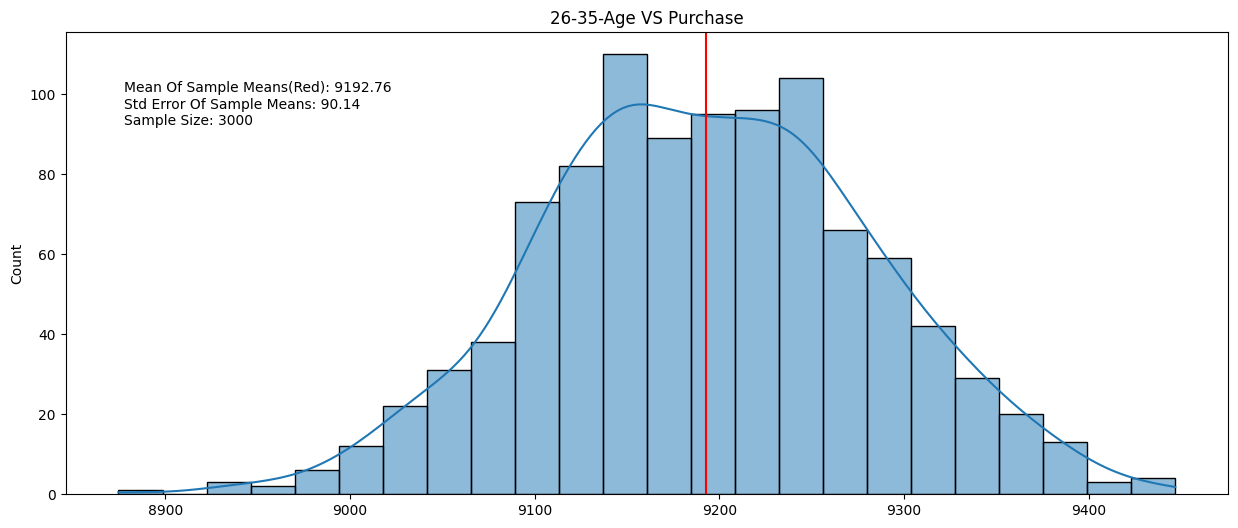

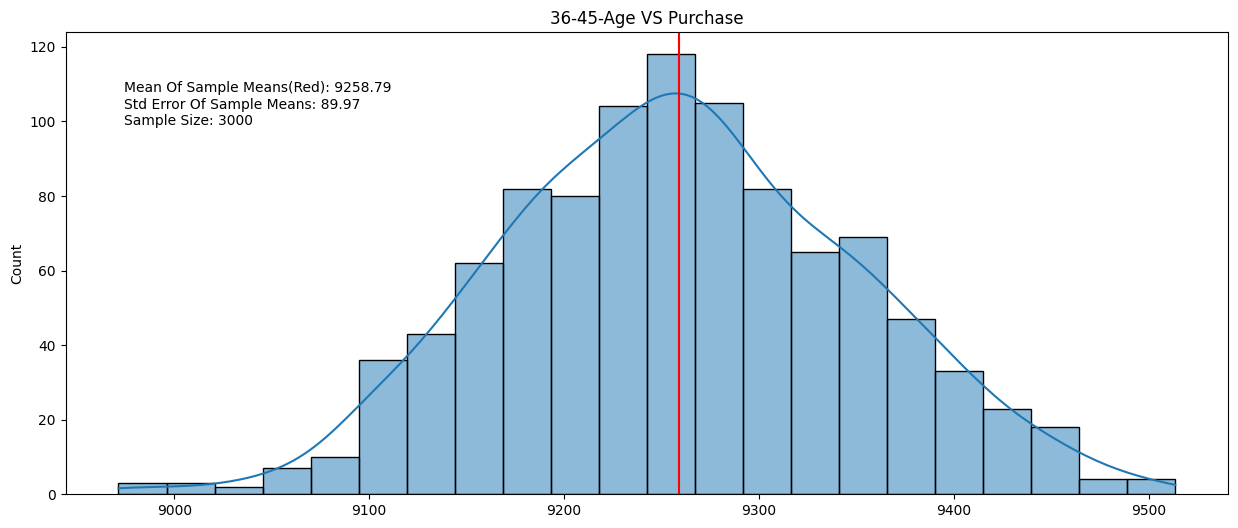

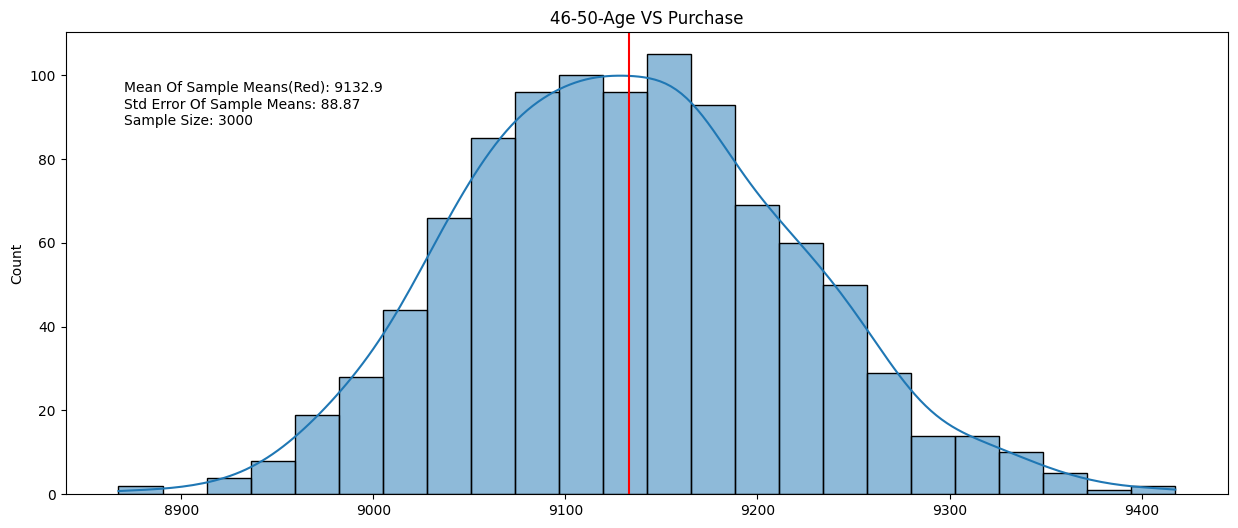

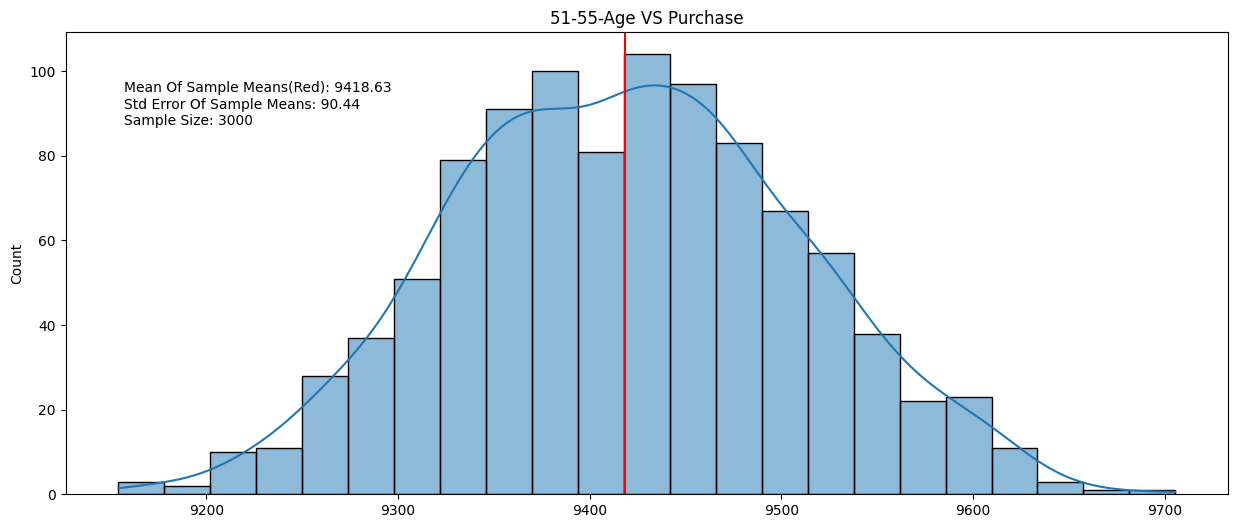

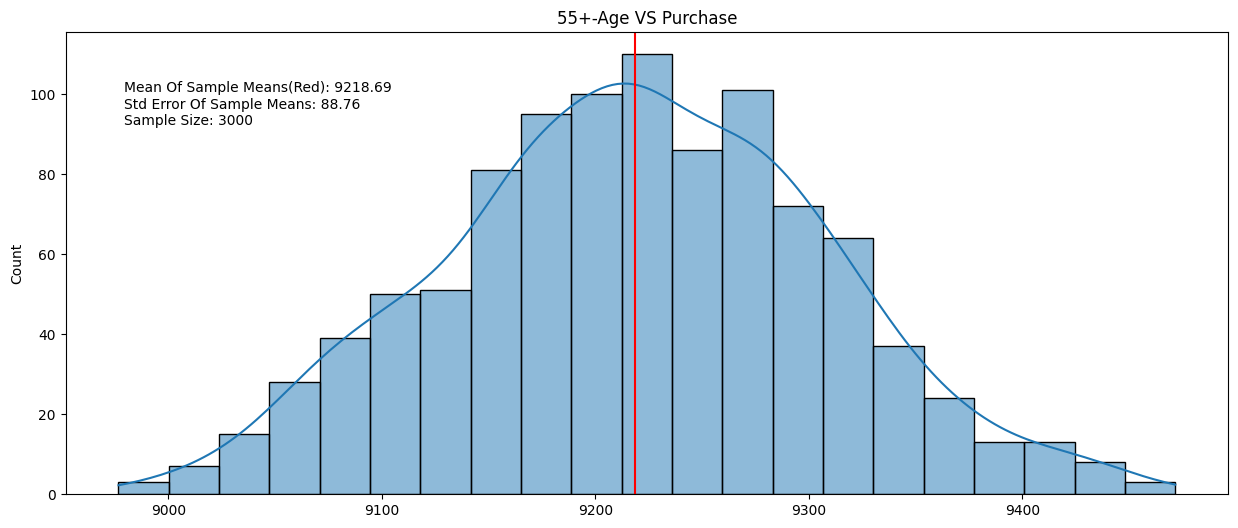

In [121]:
for i in age_cat:
    plt.figure(figsize=(15,6))
    plt.title(f'{i}-Age VS Purchase')
    sns.histplot(age_sample_means[f'{i}_sample_mean_{sample_size}'], kde= True, fill= True)
    plt.axvline(x= age_means[f'{i}_mean_{sample_size}'], color='r')
    temp_mean= age_means[f'{i}_mean_{sample_size}']
    temp_se= age_se[f'{i}_se_{sample_size}']
    plt.annotate(f'Mean Of Sample Means(Red): {np.round(temp_mean, 2)} \nStd Error Of Sample Means: {np.round(temp_se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
    plt.show()

In [122]:
age_ci={}
for i in age_cat:
    age_ci[f'{i}_lower_bound_{sample_size}'] = age_means[f'{i}_mean_{sample_size}'] + (norm.ppf(0.025) * age_se[f'{i}_se_{sample_size}'])
    age_ci[f'{i}_upper_bound_{sample_size}'] = age_means[f'{i}_mean_{sample_size}'] + (norm.ppf(0.975) * age_se[f'{i}_se_{sample_size}'])
    print(f'95% Confidence Interval For The Average Amount Spent By {i} For Sample Size {sample_size}:', (age_ci[f'{i}_lower_bound_{sample_size}'], age_ci[f'{i}_upper_bound_{sample_size}']))
    print('-'*100)

95% Confidence Interval For The Average Amount Spent By 0-17 For Sample Size 3000: (8689.425623776504, 9049.415267556826)
----------------------------------------------------------------------------------------------------
95% Confidence Interval For The Average Amount Spent By 18-25 For Sample Size 3000: (8944.558528430067, 9300.882343569936)
----------------------------------------------------------------------------------------------------
95% Confidence Interval For The Average Amount Spent By 26-35 For Sample Size 3000: (9016.08056660531, 9369.44003339469)
----------------------------------------------------------------------------------------------------
95% Confidence Interval For The Average Amount Spent By 36-45 For Sample Size 3000: (9082.451815032042, 9435.119474301295)
----------------------------------------------------------------------------------------------------
95% Confidence Interval For The Average Amount Spent By 46-50 For Sample Size 3000: (8958.726042604076, 930

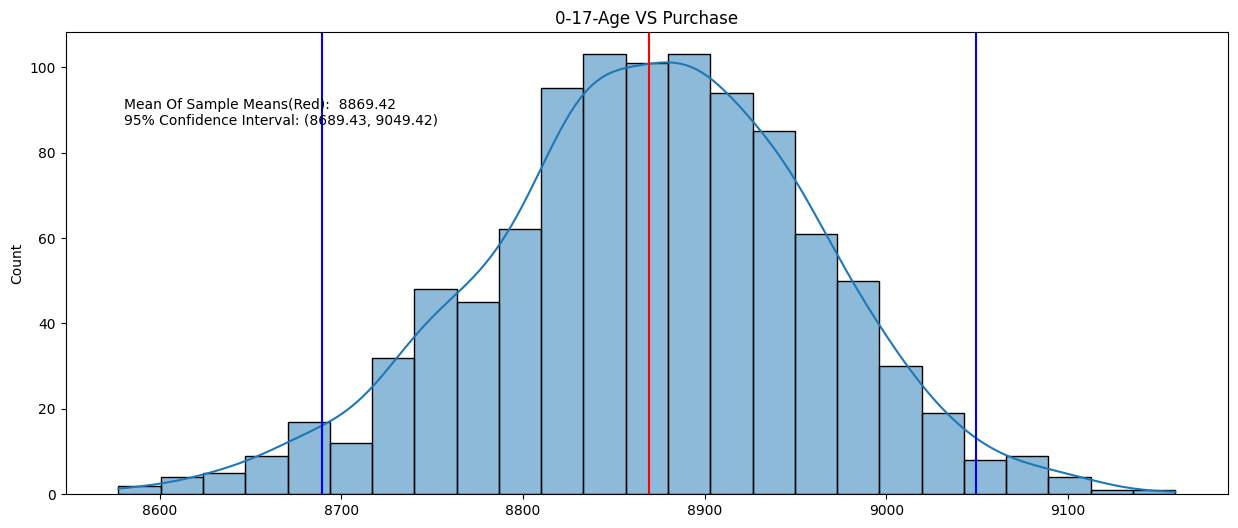

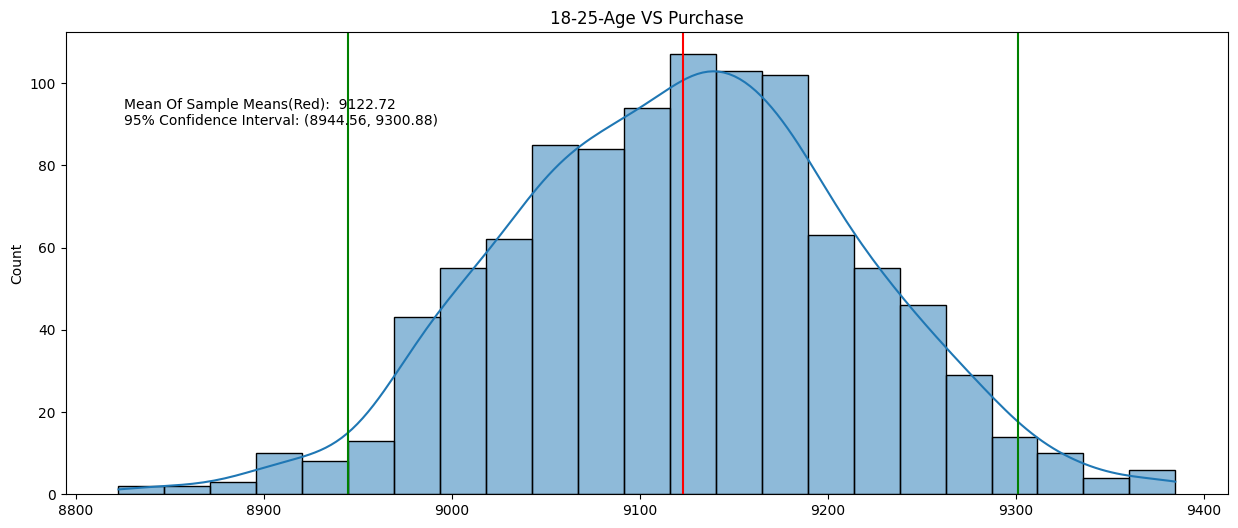

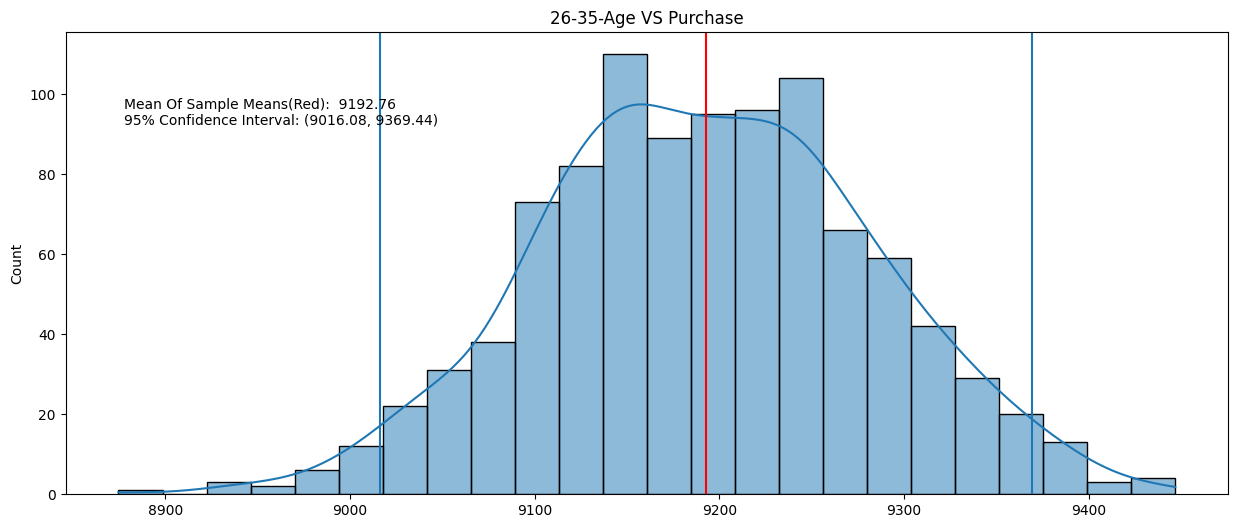

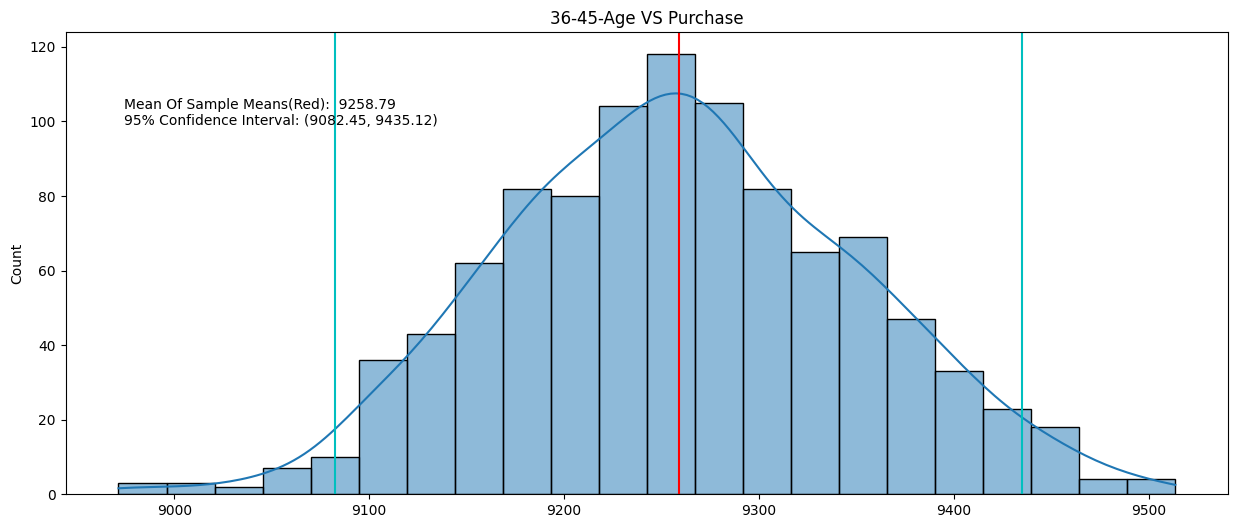

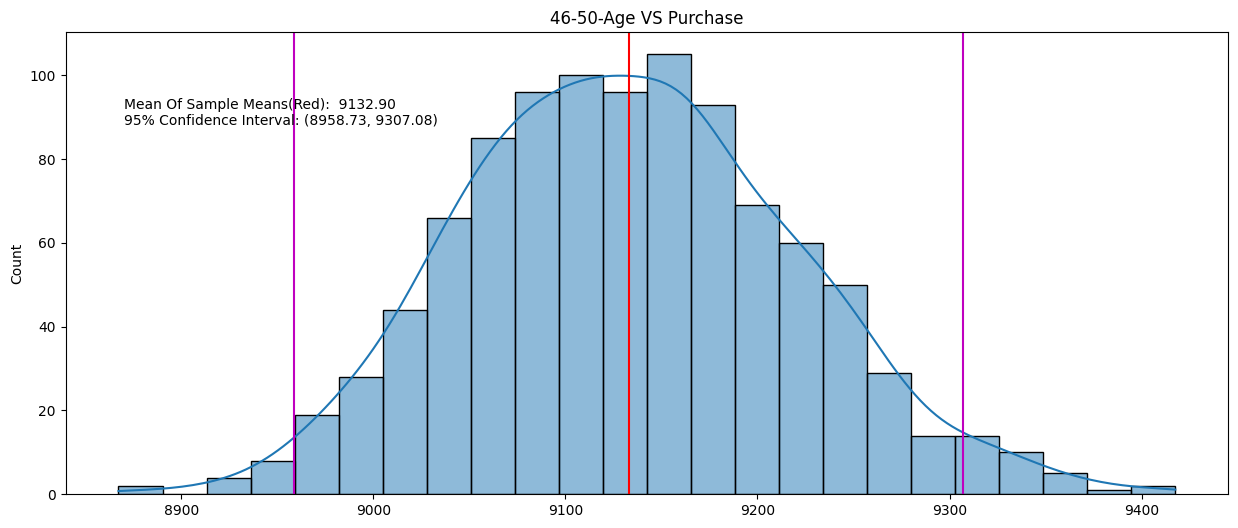

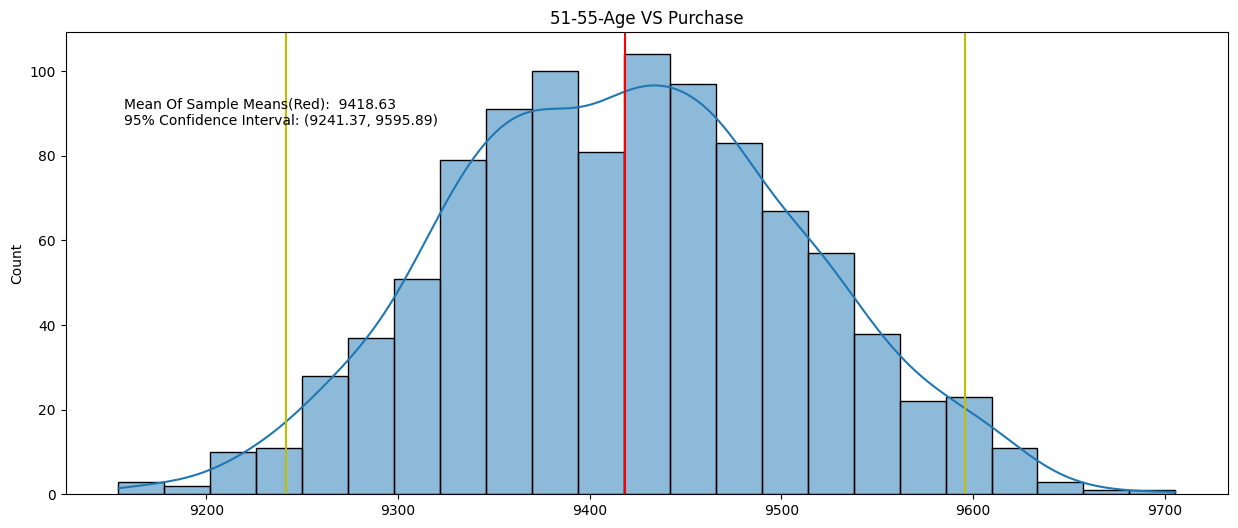

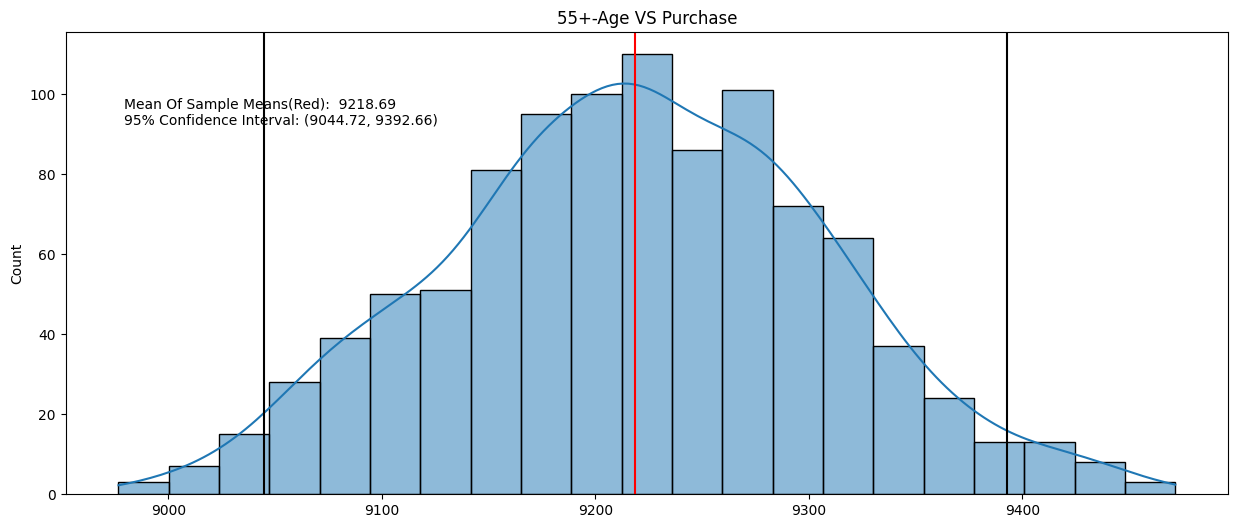

In [123]:
color= ['b', 'g', '#1f77b4', 'c', 'm', 'y', 'k']
age_se_list= list(age_se.keys())
for i in age_cat:
    plt.figure(figsize=(15,6))
    plt.title(f'{i}-Age VS Purchase')
    sns.histplot(age_sample_means[f'{i}_sample_mean_{sample_size}'], kde= True, fill= True)
    plt.axvline(x= age_means[f'{i}_mean_{sample_size}'], color='r')
    temp_mean= age_means[f'{i}_mean_{sample_size}']
    plt.axvline(x= age_ci[f'{i}_lower_bound_{sample_size}'], color=color[age_se_list.index(f'{i}_se_{sample_size}')])
    temp_low= age_ci[f'{i}_lower_bound_{sample_size}']
    plt.axvline(x= age_ci[f'{i}_upper_bound_{sample_size}'], color=color[age_se_list.index(f'{i}_se_{sample_size}')])
    temp_up= age_ci[f'{i}_upper_bound_{sample_size}']
    plt.annotate(f'Mean Of Sample Means(Red): {np.mean(temp_mean) : .2f} \n95% Confidence Interval: {(np.round(temp_low, 2), np.round(temp_up,2))}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
    plt.show()

**Overlapping ?**

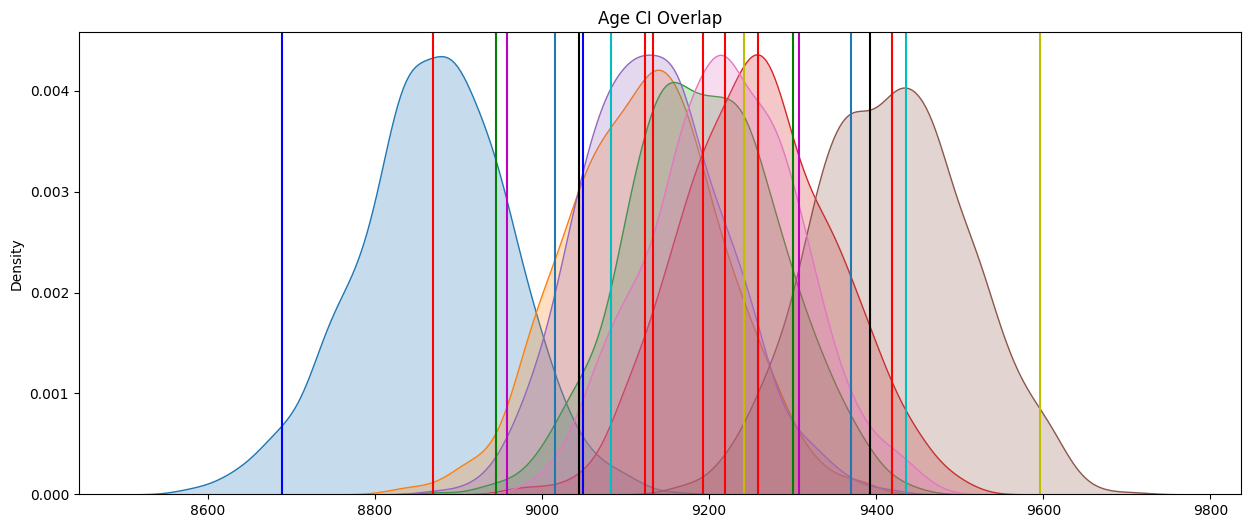

In [124]:
color= ['b', 'g', '#1f77b4', 'c', 'm', 'y', 'k']
age_se_list= list(age_se.keys())
a, b, c, d, e, f, j = age_cat
age_cat_list= [a, b, c, d, e, f, j]
plt.figure(figsize=(15,6))
plt.title('Age CI Overlap')
for i in age_cat_list:
    sns.kdeplot(age_sample_means[f'{i}_sample_mean_{sample_size}'], fill= True)
    plt.axvline(x= age_means[f'{i}_mean_{sample_size}'], color='r')
    plt.axvline(x= age_ci[f'{i}_lower_bound_{sample_size}'], color=color[age_se_list.index(f'{i}_se_{sample_size}')])
    plt.axvline(x= age_ci[f'{i}_upper_bound_{sample_size}'], color=color[age_se_list.index(f'{i}_se_{sample_size}')])
plt.show()

**95% Confidence Interval For The Average Amount Spent By Age Category..**

**Sample Size: 30000**

In [125]:
sample_size= 30000
age_cat= ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
age_sample_means={}
age_means={}
age_se={}
for i in age_cat:
    age_sample_means[f'{i}_sample_mean_{sample_size}'] = [np.mean(data.loc[data['Age']== i, 'Purchase'].sample(sample_size, replace= True)) for _ in range(1000)]
    age_means[f'{i}_mean_{sample_size}'] = np.mean(age_sample_means[f'{i}_sample_mean_{sample_size}'])
    age_se[f'{i}_se_{sample_size}']= data.loc[data['Age']== i, 'Purchase'].std()/np.sqrt(sample_size)
    print(f'{i} Purchase Amount- Mean Of Sample Means:', age_means[f'{i}_mean_{sample_size}'])
    print(f'{i} Purchase Amount- Std Error Of Sample Means:', age_se[f'{i}_se_{sample_size}'])
    print('-'*100)

0-17 Purchase Amount- Mean Of Sample Means: 8866.974661766666
0-17 Purchase Amount- Std Error Of Sample Means: 29.041023646300076
----------------------------------------------------------------------------------------------------
18-25 Purchase Amount- Mean Of Sample Means: 9123.510204666667
18-25 Purchase Amount- Std Error Of Sample Means: 28.74529453833825
----------------------------------------------------------------------------------------------------
26-35 Purchase Amount- Mean Of Sample Means: 9192.7221439
26-35 Purchase Amount- Std Error Of Sample Means: 28.50615512966409
----------------------------------------------------------------------------------------------------
36-45 Purchase Amount- Mean Of Sample Means: 9254.458732099998
36-45 Purchase Amount- Std Error Of Sample Means: 28.450345750428156
----------------------------------------------------------------------------------------------------
46-50 Purchase Amount- Mean Of Sample Means: 9128.965901766667
46-50 Purchase

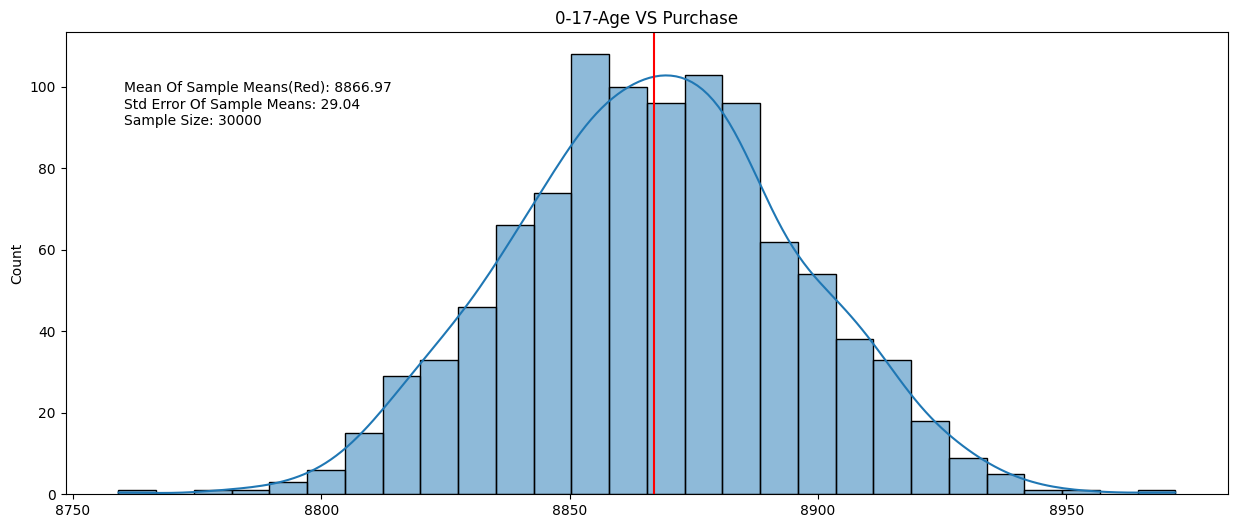

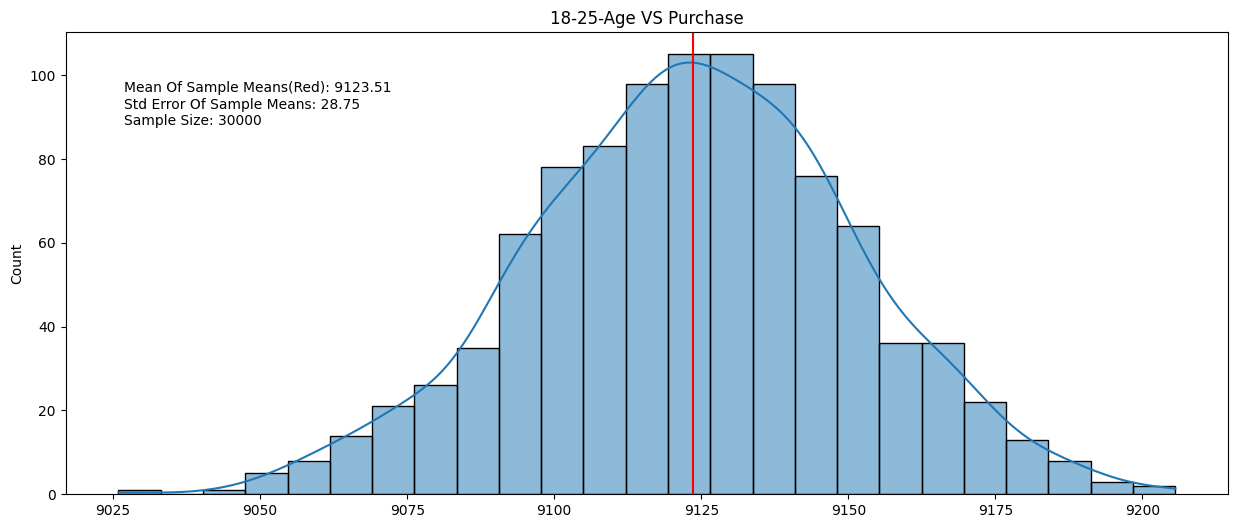

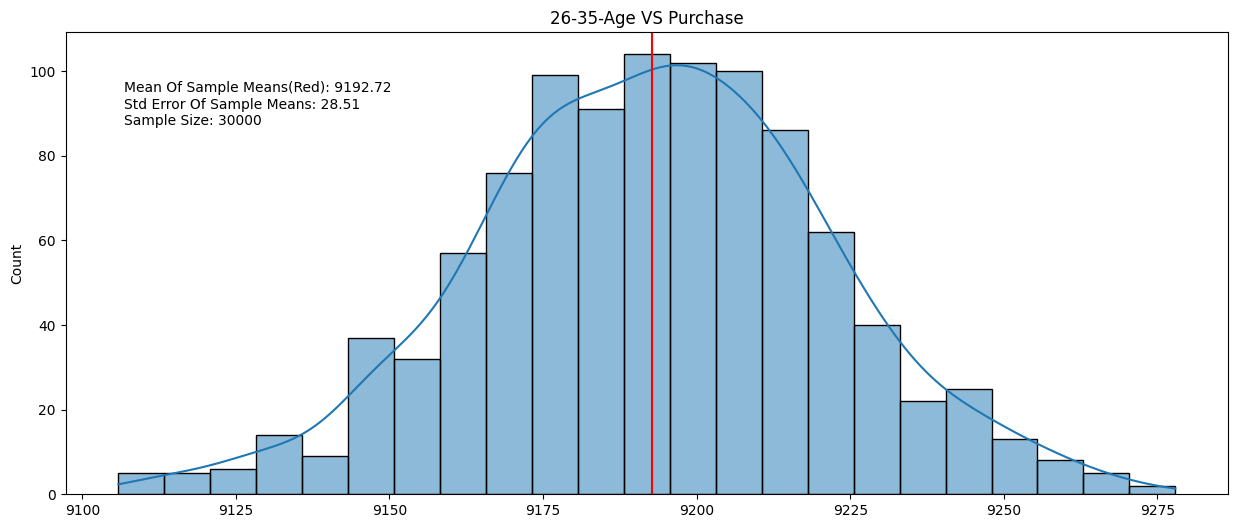

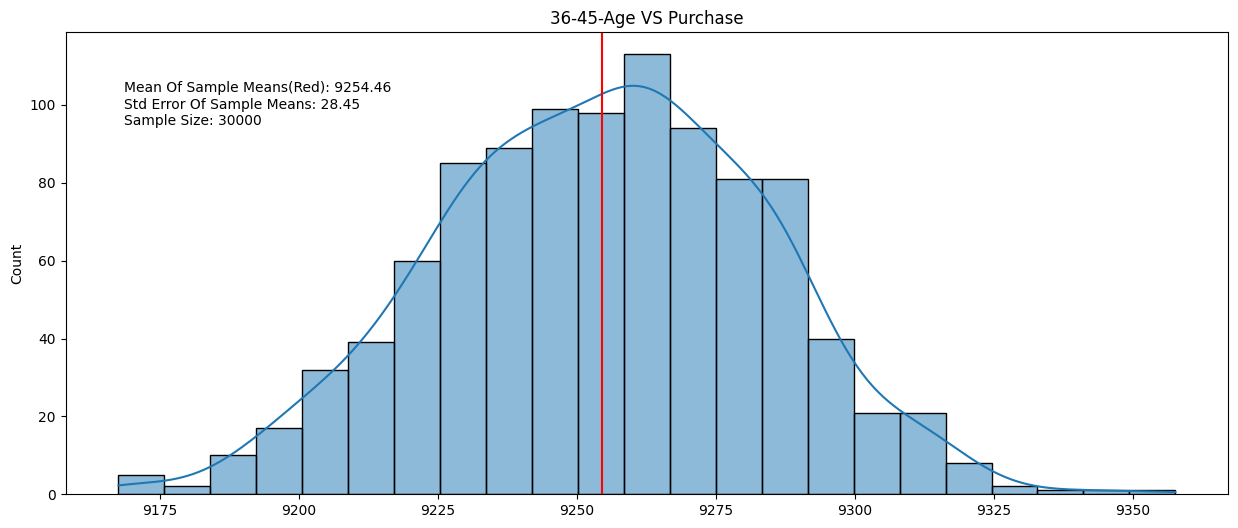

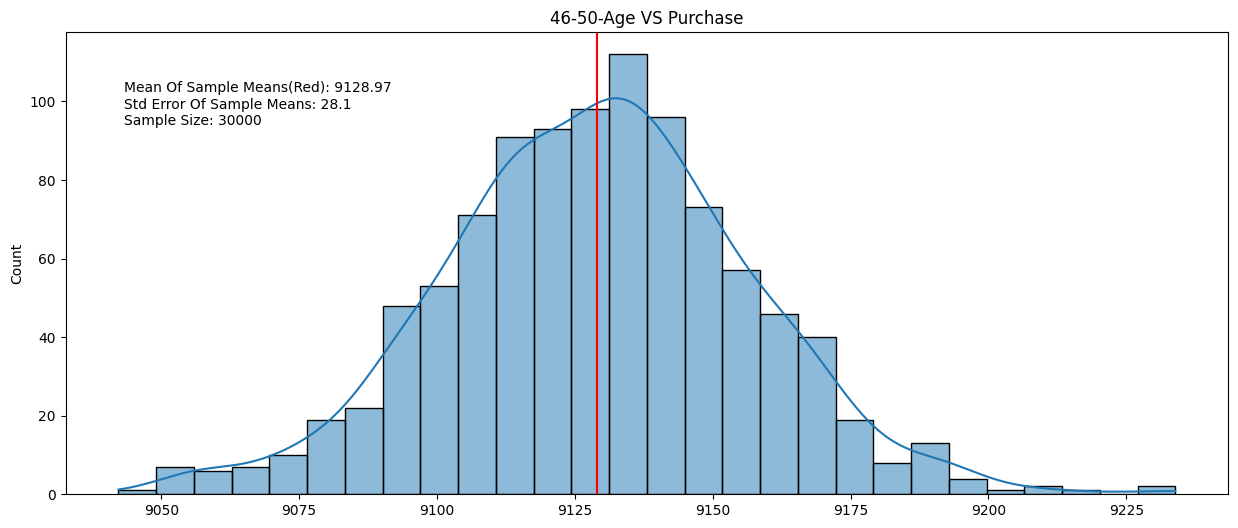

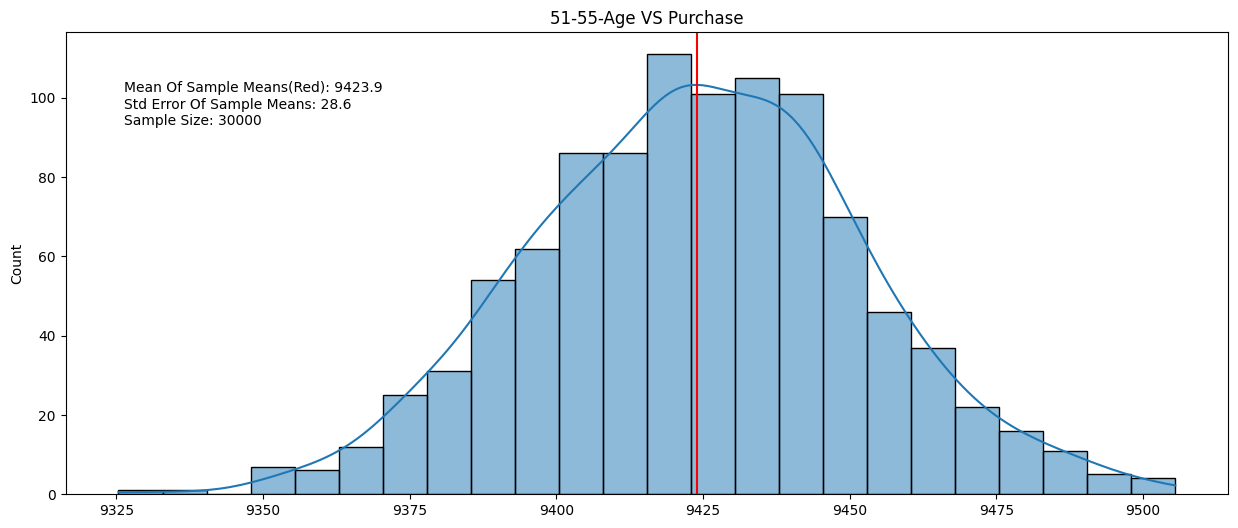

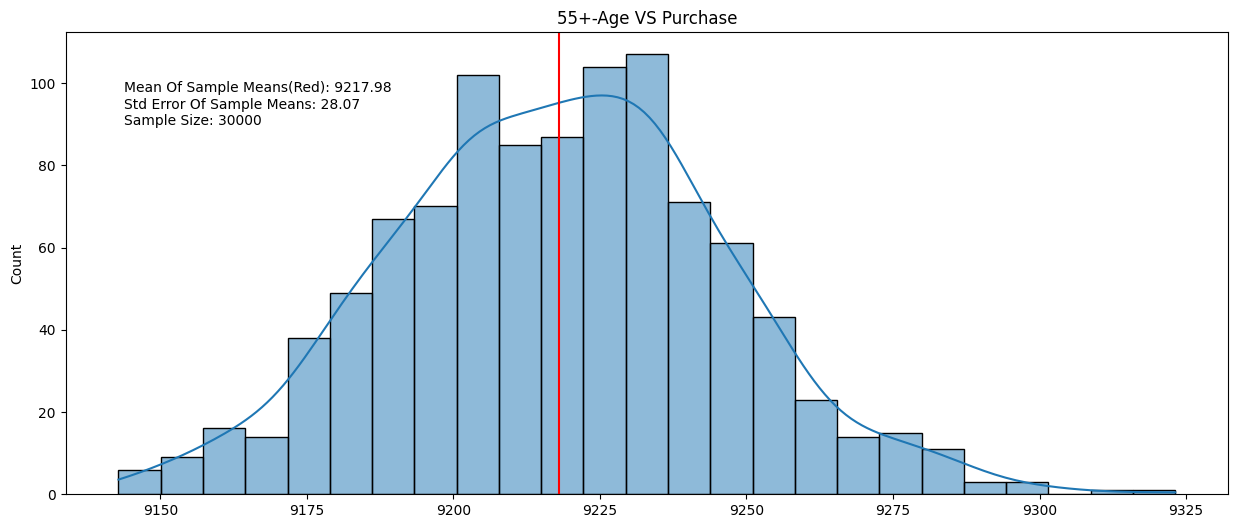

In [126]:
for i in age_cat:
    plt.figure(figsize=(15,6))
    plt.title(f'{i}-Age VS Purchase')
    sns.histplot(age_sample_means[f'{i}_sample_mean_{sample_size}'], kde= True, fill= True)
    plt.axvline(x= age_means[f'{i}_mean_{sample_size}'], color='r')
    temp_mean= age_means[f'{i}_mean_{sample_size}']
    temp_se= age_se[f'{i}_se_{sample_size}']
    plt.annotate(f'Mean Of Sample Means(Red): {np.round(temp_mean, 2)} \nStd Error Of Sample Means: {np.round(temp_se, 2)} \nSample Size: {sample_size}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
    plt.show()

In [127]:
age_ci={}
for i in age_cat:
    age_ci[f'{i}_lower_bound_{sample_size}'] = age_means[f'{i}_mean_{sample_size}'] + (norm.ppf(0.025) * age_se[f'{i}_se_{sample_size}'])
    age_ci[f'{i}_upper_bound_{sample_size}'] = age_means[f'{i}_mean_{sample_size}'] + (norm.ppf(0.975) * age_se[f'{i}_se_{sample_size}'])
    print(f'95% Confidence Interval For The Average Amount Spent By {i} For Sample Size {sample_size}:', (age_ci[f'{i}_lower_bound_{sample_size}'], age_ci[f'{i}_upper_bound_{sample_size}']))
    print('-'*100)

95% Confidence Interval For The Average Amount Spent By 0-17 For Sample Size 30000: (8810.055301345741, 8923.894022187591)
----------------------------------------------------------------------------------------------------
95% Confidence Interval For The Average Amount Spent By 18-25 For Sample Size 30000: (9067.170462646529, 9179.849946686805)
----------------------------------------------------------------------------------------------------
95% Confidence Interval For The Average Amount Spent By 26-35 For Sample Size 30000: (9136.851106508147, 9248.593181291853)
----------------------------------------------------------------------------------------------------
95% Confidence Interval For The Average Amount Spent By 36-45 For Sample Size 30000: (9198.697079081447, 9310.22038511855)
----------------------------------------------------------------------------------------------------
95% Confidence Interval For The Average Amount Spent By 46-50 For Sample Size 30000: (9073.88693987690

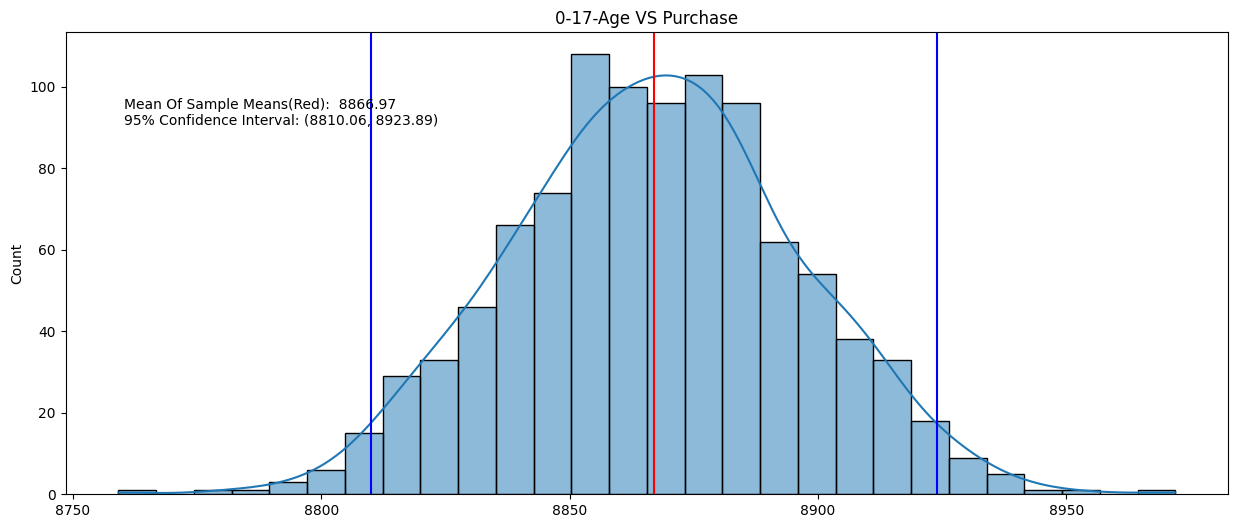

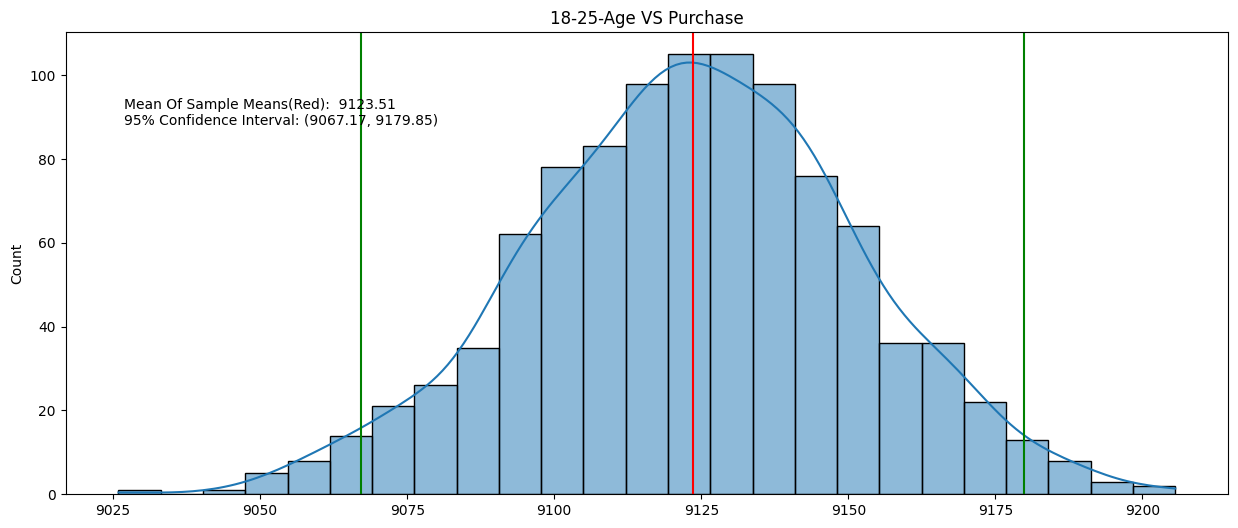

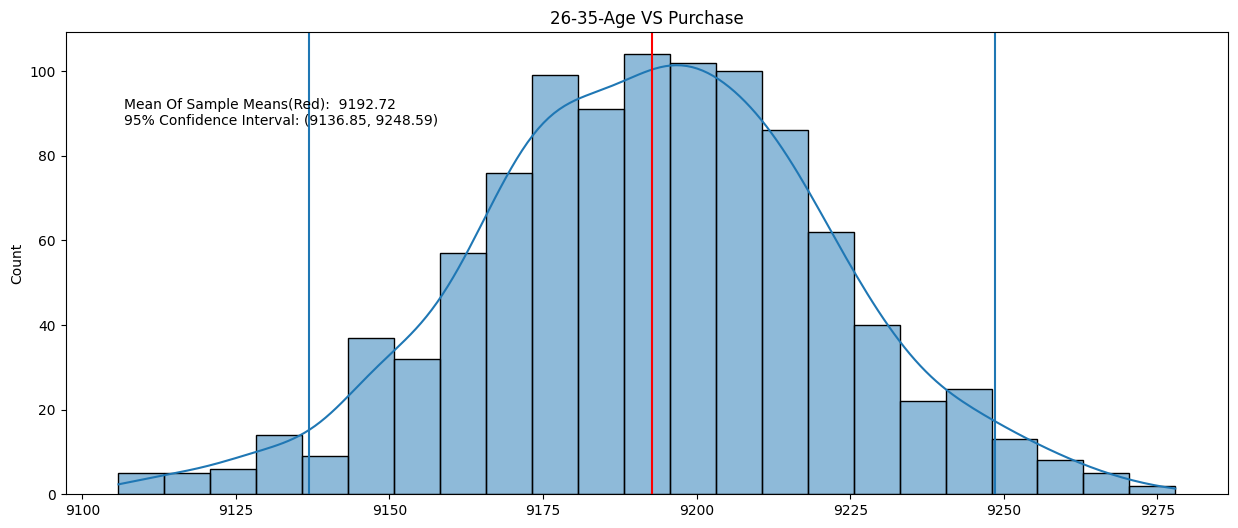

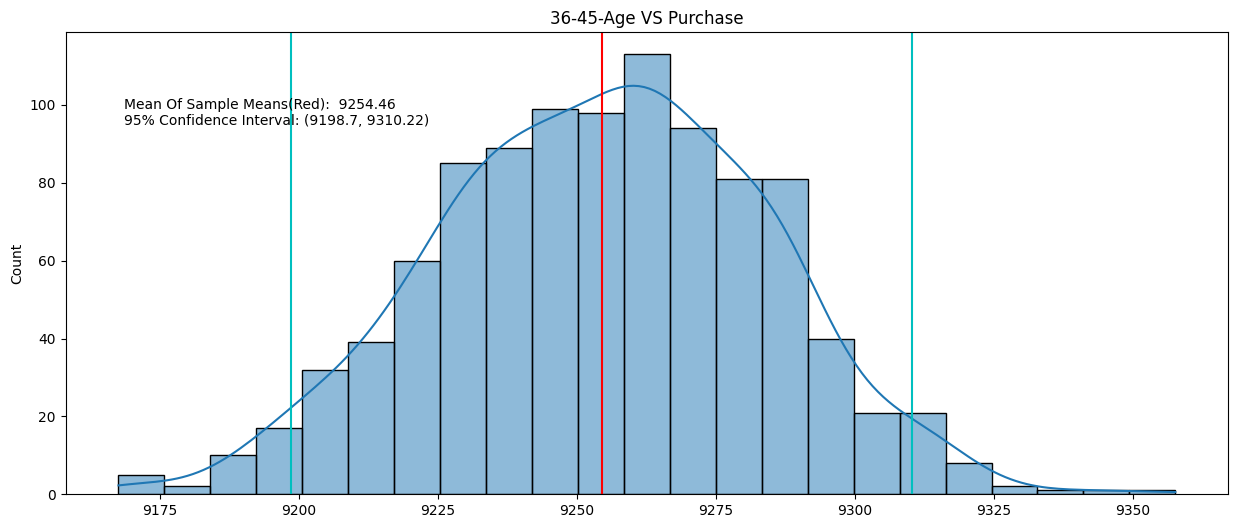

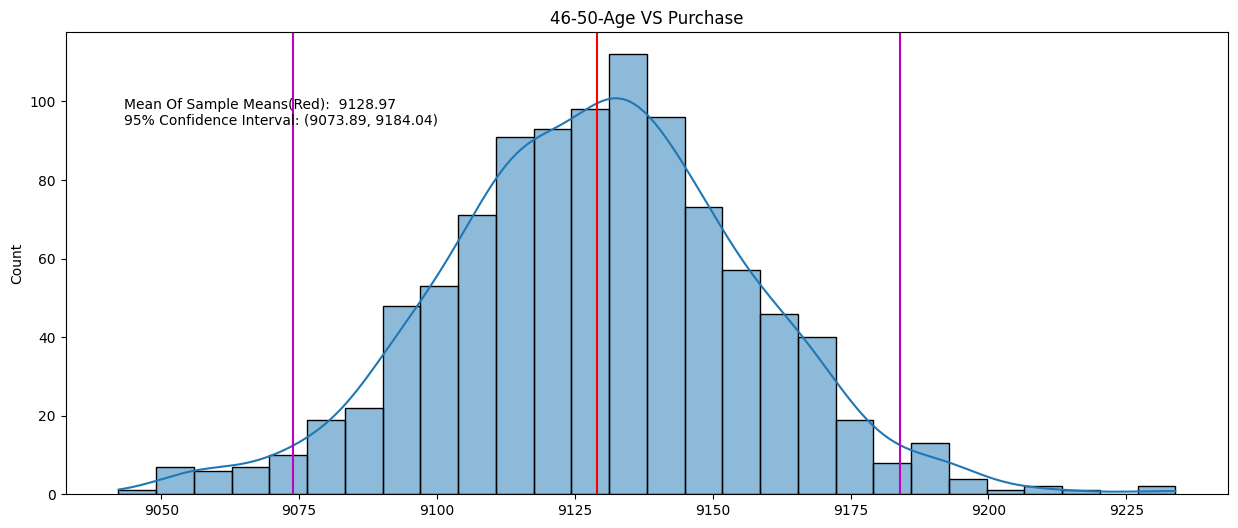

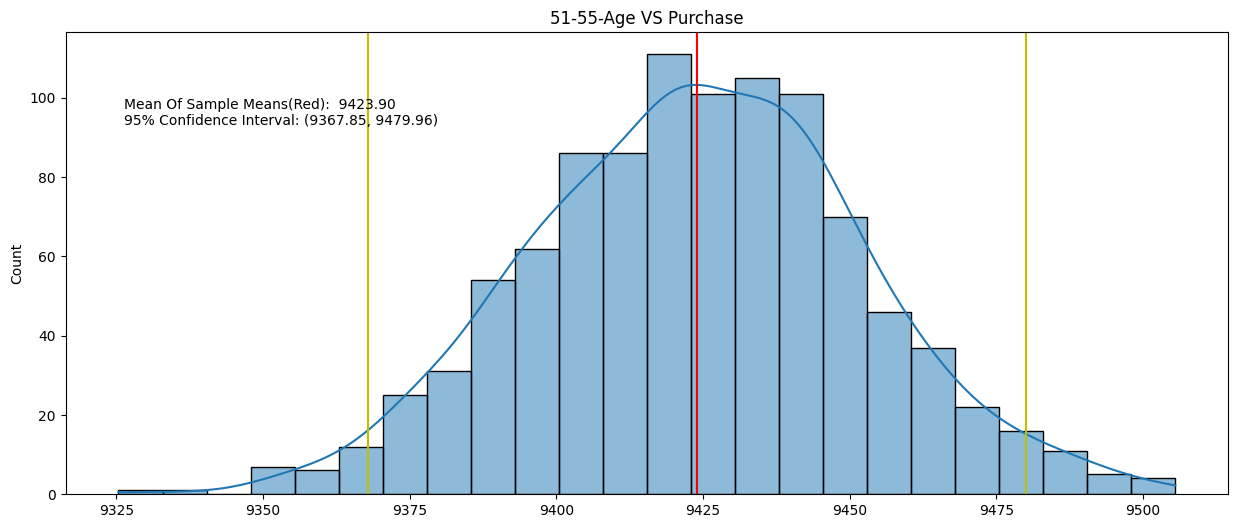

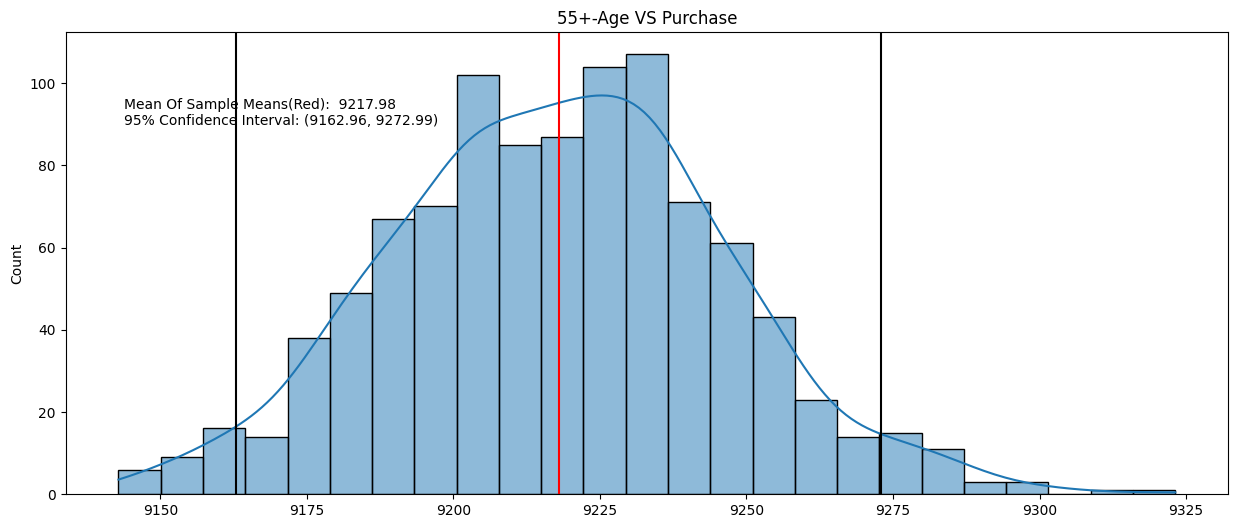

In [128]:
color= ['b', 'g', '#1f77b4', 'c', 'm', 'y', 'k']
age_se_list= list(age_se.keys())
for i in age_cat:
    plt.figure(figsize=(15,6))
    plt.title(f'{i}-Age VS Purchase')
    sns.histplot(age_sample_means[f'{i}_sample_mean_{sample_size}'], kde= True, fill= True)
    plt.axvline(x= age_means[f'{i}_mean_{sample_size}'], color='r')
    temp_mean= age_means[f'{i}_mean_{sample_size}']
    plt.axvline(x= age_ci[f'{i}_lower_bound_{sample_size}'], color=color[age_se_list.index(f'{i}_se_{sample_size}')])
    temp_low= age_ci[f'{i}_lower_bound_{sample_size}']
    plt.axvline(x= age_ci[f'{i}_upper_bound_{sample_size}'], color=color[age_se_list.index(f'{i}_se_{sample_size}')])
    temp_up= age_ci[f'{i}_upper_bound_{sample_size}']
    plt.annotate(f'Mean Of Sample Means(Red): {np.mean(temp_mean) : .2f} \n95% Confidence Interval: {(np.round(temp_low, 2), np.round(temp_up,2))}', xy=(0.05, 0.80), xycoords='axes fraction', fontsize=10)
    plt.show()

**Overlapping ?**

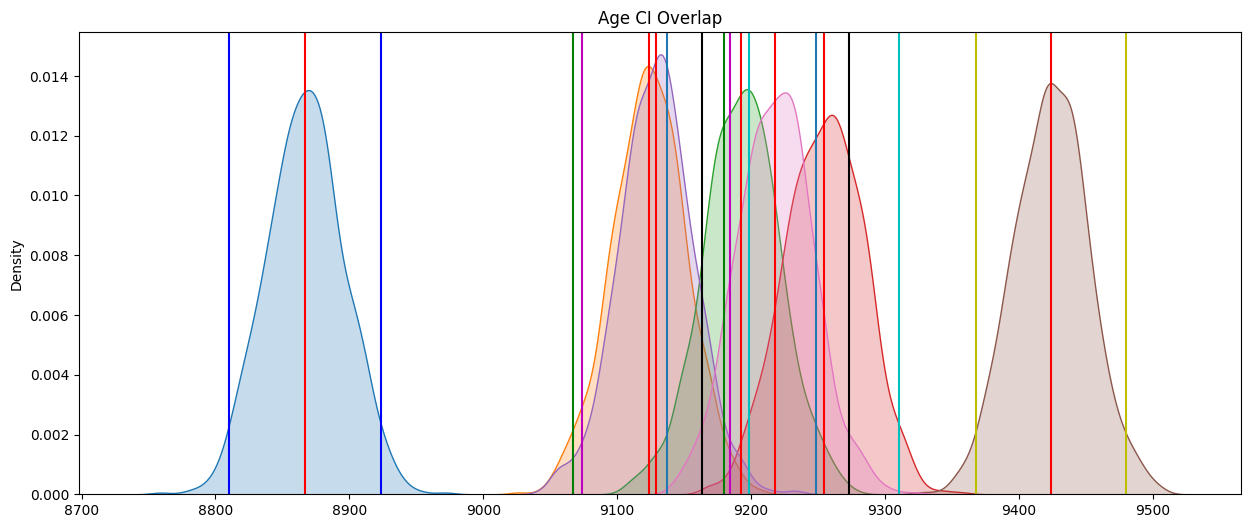

In [129]:
color= ['b', 'g', '#1f77b4', 'c', 'm', 'y', 'k']
age_se_list= list(age_se.keys())
a, b, c, d, e, f, j = age_cat
age_cat_list= [a, b, c, d, e, f, j]
plt.figure(figsize=(15,6))
plt.title('Age CI Overlap')
for i in age_cat_list:
    sns.kdeplot(age_sample_means[f'{i}_sample_mean_{sample_size}'], fill= True)
    plt.axvline(x= age_means[f'{i}_mean_{sample_size}'], color='r')
    plt.axvline(x= age_ci[f'{i}_lower_bound_{sample_size}'], color=color[age_se_list.index(f'{i}_se_{sample_size}')])
    plt.axvline(x= age_ci[f'{i}_upper_bound_{sample_size}'], color=color[age_se_list.index(f'{i}_se_{sample_size}')])
plt.show()

**Conclusion:**

**Small Samples (n=300): High variability and broad intervals mask meaningful differences across age groups.**

**Larger Samples (n=3000): Differences begin to emerge, though overlaps in spending between adjacent age groups remain.**

**Largest Sample (n=30,000): Overlaps reduce significantly, revealing a clear spending hierarchy: 51-55 > 36-45 > 55+ > 26-35 > 18-25 > 46-50 > 0-17.**

# **7. Insights**

***>Gender Distribution: 75.31% Male vs. 24.69% Female customers. Male customers dominate purchases on Black Friday.***

***>Marital Status: 59.03% Unmarried vs. 40.97% Married customers. Unmarried individuals contribute more to purchases.***

***>City Category: Purchases are distributed across cities as:***
***A: 26.85%, B: 42.03%, C: 31.12%.***
***City "B" sees the highest activity.***

***>Popular Product Categories:***
**Categories 1, 5, and 8 are the most purchased.**
**Category 5 leads in popularity.**

***>Age Group Insights: Customers aged 26–30 are the most active buyers, particularly in categories 1, 5, 8, and 11.***

∇**How does Gender affect the amount spent?**∇

∇
***Initial Observations (Sample Size = 300):***

***Males: Mean = ₹9370.91, 95% CI = (₹8804.08, ₹9937.75)***

***Females: Mean = ₹8666.57, 95% CI = (₹8137.10, ₹9196.05)***

***Observation: Confidence intervals overlap, so we cannot conclusively state that males spend more than females.***

∇
***Increased Sample Size (3000):***

***Males: Mean = ₹9365.12, 95% CI = (₹9185.87, ₹9544.37)***

***Females: Mean = ₹8671.77, 95% CI = (₹8504.33, ₹8839.20)***

***Observation: CI no longer overlap, providing evidence that males spend more than females.***

∇
***Further Increased Sample Size (30000):***

***Males: Mean = ₹9366.82, 95% CI = (₹9310.14, ₹9423.51)***

***Females: Mean = ₹8671.26, 95% CI = (₹8618.31, ₹8724.20)***

***Observation: Narrower CIs and non-overlapping intervals confirm with high confidence that males spend more than females.***


∇**How does Marital_Status affect the amount spent?**∇

∇
***Initial Observations (Sample Size = 300):***

***Unmarried: Mean = ₹9201.28, 95% CI = (₹8641.33, ₹9761.22)***

***Married: Mean = ₹9197.15, 95% CI = (₹8639.82, ₹9754.48)***

***Observation: Overlapping confidence intervals indicate no significant difference in spending.***

∇
***Increased Sample Size (3000):***

***Unmarried: Mean = ₹9199.19, 95% CI = (₹9022.12, ₹9376.26)***

***Married: Mean = ₹9189.66, 95% CI = (₹9013.42, ₹9365.90)***

***Observation: Narrower CIs, but still overlapping, confirming similar spending patterns.***

∇
***Further Increased Sample Size (30,000):***

***Unmarried: Mean = ₹9201.11, 95% CI = (₹9145.12, ₹9257.11)***

***Married: Mean = ₹9186.31, 95% CI = (₹9130.58, ₹9242.05)***

***Observation: Overlap persists even with a large sample, indicating that spending by marital status has similar patterns.***


∇**How does Age affect the amount spent?**∇

∇
***>1. Sample Size = 300:***
***Confidence intervals overlap significantly across age groups, making it difficult to confidently state differences in spending between age categories.***
***Example:***
***0-17 (₹8300.44, ₹9438.82) overlaps with 18-25 (₹8546.02, ₹9672.81) and several other age groups.***
***Indication: With a small sample size, variability is high, resulting in broad confidence intervals and overlapping ranges.***

∇
***>2. Sample Size = 3000:***
***Increasing the sample size narrows the confidence intervals, but overlaps still exist between most age groups.***
***Example:***
***18-25 (₹8944.08, ₹9300.40) overlaps with 26-35 (₹9013.19, ₹9366.55) and 36-45 (₹9084.03, ₹9436.70).***
***Indication: Though differences become clearer for some groups, overlaps suggest spending differences among age categories are still not strongly distinguishable.***

∇
***>3. Sample Size = 30,000:***
***Confidence intervals are much narrower, with minimal overlap between age groups.
Example:***
***0-17 (₹8808.93, ₹8922.77) does not overlap with 18-25 (₹9066.65, ₹9179.33) or higher age groups.***
***51-55 (₹9366.47, ₹9478.58) stands out with the highest spending, and its interval does not overlap with younger groups.***
***Indication: Larger sample sizes reveal clearer distinctions in spending patterns, showing 51-55 age group spends the most.***



# **8. Recommendations:**

***>Target Females with special Black Friday campaigns to increase their participation. Highlight offers on products that traditionally appeal more to women.***

***>Promote bundles or discounts aimed at single individuals, such as gadgets or lifestyle products. Use themes like "Treat Yourself" to attract this group.***

***>Enhance advertising in City B to capitalize on its high engagement. Boost presence in City A and C with location-specific offers to balance sales distribution.***

***>Stock and promote Categories 1, 5, and 8 prominently in stores and online. Offer loyalty points or discounts on repeat purchases in these categories.***

***>Develop targeted campaigns for the 26-30 age group, focusing on popular categories like 1, 5, 8, and 11. Use digital channels like social media and influencers that resonate with this demographic.***

***>Bundle popular categories (e.g., Category 5 with 8) to increase cart size. Provide personalized recommendations based on purchase history.***

***>Introduce exclusive, high-value offers tailored to male preferences, such as electronics or outdoor equipment.***

***>Launch promotions specifically for females to close the spending gap, focusing on popular categories like apparel or home goods.***

***>Design bundles that appeal to both genders, promoting complementary products to boost cart sizes.***

***>Use detailed analytics to refine offers based on spending patterns, ensuring maximum engagement from high-spending male demographics.***

***>Design campaigns that appeal equally to married and unmarried customers, focusing on shared preferences like popular product categories.***

***>Introduce special discounts on family bundles or lifestyle products to attract married customers, leveraging their potential for larger household purchases.***

***>Highlight offers for personal-use products or experiences (like gadgets or subscriptions) to attract unmarried customers.***

***>Since marital status does not significantly impact spending, prioritize strategies based on factors like gender, age, or city category for more targeted growth.***

***>Target Age Group 51-55: Promote premium products and loyalty programs to capitalize on this high-spending demographic. Highlight offers on categories like electronics, furniture, and appliances, which appeal to middle-aged consumers.***

***>Focus on Younger Groups: Develop budget-friendly bundles and discounts for the 0-17 and 18-25 age groups to boost spending. Use targeted social media campaigns for younger demographics.***

***>Age-Specific Marketing: Tailor advertisements and product placements based on age group preferences. For example, promote practical products to the 36-45 age group and indulgent ones to 51-55.***

***>Bundle products for families, especially targeting the 36-55 age groups who likely have dependents and households.***

# **THANK YOU**

# **-Walmart Case Study By: Nitish Vishwanath Hatapaki**